In [1]:
from pathlib import Path

import pandas as pd

# Notebook konumundan data klasörüne güvenli erişim
DATA_PATH = Path("../data/hotel_forecasting.csv")

# Dosya '|' ile ayrılmış; kolon adlarındaki tırnakları temizliyoruz
df_raw = pd.read_csv(DATA_PATH, sep="|", quotechar='"')
df_raw.columns = [c.strip().strip('"') for c in df_raw.columns]

# Üzerinde çalışacağımız kopya
df = df_raw.copy()

df.shape

(550000, 61)

In [3]:
# Gezinmeyi kolaylaştırmak için görünüm ayarları
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)

# Muhtemel tarih sütunlarını otomatik parse et
for col in df.columns:
    low = col.lower()
    if "date" in low or "tarih" in low or "time" in low:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Düşük kardinaliteli metin sütunlarını kategoriye çevir
for col in df.select_dtypes(include=["object", "string"]).columns:
    if df[col].nunique(dropna=False) / len(df) < 0.5:
        df[col] = df[col].astype("category")

print(f"Satır/Sütun: {df.shape[0]} / {df.shape[1]}")
print("\nVeri tipleri:")
display(df.dtypes.to_frame("dtype"))

print("\nİlk 10 satır:")
display(df.head(10))

print("\nEksik değer özeti (ilk 20 sütun):")
display(df.isna().sum().sort_values(ascending=False).head(20).to_frame("missing_count"))

Satır/Sütun: 550000 / 61

Veri tipleri:


,dtype
YearId,int64
MonthId,int64
WeekId,int64
HotelId,int64
HotelBoardTypeName,category
...,...
u_oncelik_2026,int64
tek_yetkili_2026,int64
avansli_2026,int64
d_oncelik_2026,int64



İlk 10 satır:


,YearId,MonthId,WeekId,HotelId,HotelBoardTypeName,HotelCategoryName,CityName,HotelRegionName,IsSeturHotel,TermalOtel,AlkolsuzOtel,YetiskinOtel,BalayiOtel,CevreDostuOtel,KayakOtel,EvcilHayvanKabulEdenOtel,CocukDostuOtel,DenizeSifirOtel,ReservationFlag,AvgSellingPrice,YilBazindaHotelMinSellingPrice,YilBazindaHotelMaxSellingPrice,YilBazindaHotelAvgSellingPrice,YilCityBazindaHotelMinSellingPrice,YilCityBazindaHotelMaxSellingPrice,YilCityBazindaHotelAvgSellingPrice,YilCityCategoryBazindaHotelMinSellingPrice,YilCityCategoryBazindaHotelMaxSellingPrice,YilCityCategoryBazindaHotelAvgSellingPrice,HotelCategoryCityCount,HotelCategoryCount,CityCount,SehirdekiKategoriOrani,GenelKategoriOrani,tek_yetkili_2024,avansli_2024,b_oncelik_2024,b_oncelik_2025,avansli_2025,tek_yetkili_2025,i_oncelik_2025,u_oncelik_2025,kayak_oteli,termal_otel,yakin_bolge,erken_rezervasyon_2025,akdeniz,ege,kibris,girne,magosa,bafra,lefkosa,erken_rezervasyon_2026,b_oncelik_2026,i_oncelik_2026,u_oncelik_2026,tek_yetkili_2026,avansli_2026,d_oncelik_2026,kapadokya
0,2025,12,50,560,Yarım Pansiyon,4 Yıldız,Kocaeli,Kartepe,1,1,0,0,0,0,1,0,0,0,0,NaN,3750.0,8500.0,5551.145889,750.0,8690.4,2290.341085,1147.5,8500.0,2256.582846,5,404,18,0.277778,0.012376,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2025,12,49,560,Yarım Pansiyon,4 Yıldız,Kocaeli,Kartepe,1,1,0,0,0,0,1,0,0,0,0,NaN,3750.0,8500.0,5551.145889,750.0,8690.4,2290.341085,1147.5,8500.0,2256.582846,5,404,18,0.277778,0.012376,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2025,10,43,560,Yarım Pansiyon,4 Yıldız,Kocaeli,Kartepe,1,1,0,0,0,0,1,0,0,0,0,NaN,3750.0,8500.0,5551.145889,750.0,8690.4,2290.341085,1147.5,8500.0,2256.582846,5,404,18,0.277778,0.012376,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2025,10,42,560,Yarım Pansiyon,4 Yıldız,Kocaeli,Kartepe,1,1,0,0,0,0,1,0,0,0,0,NaN,3750.0,8500.0,5551.145889,750.0,8690.4,2290.341085,1147.5,8500.0,2256.582846,5,404,18,0.277778,0.012376,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2025,10,41,560,Yarım Pansiyon,4 Yıldız,Kocaeli,Kartepe,1,1,0,0,0,0,1,0,0,0,0,NaN,3750.0,8500.0,5551.145889,750.0,8690.4,2290.341085,1147.5,8500.0,2256.582846,5,404,18,0.277778,0.012376,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,2025,10,40,560,Yarım Pansiyon,4 Yıldız,Kocaeli,Kartepe,1,1,0,0,0,0,1,0,0,0,0,NaN,3750.0,8500.0,5551.145889,750.0,8690.4,2290.341085,1147.5,8500.0,2256.582846,5,404,18,0.277778,0.012376,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,2025,11,46,560,Yarım Pansiyon,4 Yıldız,Kocaeli,Kartepe,1,1,0,0,0,0,1,0,0,0,0,NaN,3750.0,8500.0,5551.145889,750.0,8690.4,2290.341085,1147.5,8500.0,2256.582846,5,404,18,0.277778,0.012376,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,2025,9,40,560,Yarım Pansiyon,4 Yıldız,Kocaeli,Kartepe,1,1,0,0,0,0,1,0,0,0,0,NaN,3750.0,8500.0,5551.145889,750.0,8690.4,2290.341085,1147.5,8500.0,2256.582846,5,404,18,0.277778,0.012376,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,2025,11,44,560,Yarım Pansiyon,4 Yıldız,Kocaeli,Kartepe,1,1,0,0,0,0,1,0,0,0,0,NaN,3750.0,8500.0,5551.145889,750.0,8690.4,2290.341085,1147.5,8500.0,2256.582846,5,404,18,0.277778,0.012376,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,2025,8,35,560,Yarım Pansiyon,4 Yıldız,Kocaeli,Kartepe,1,1,0,0,0,0,1,0,0,0,0,NaN,3750.0,8500.0,5551.145889,750.0,8690.4,2290.341085,1147.5,8500.0,2256.582846,5,404,18,0.277778,0.012376,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Eksik değer özeti (ilk 20 sütun):


,missing_count
AvgSellingPrice,482745
YilBazindaHotelMinSellingPrice,113056
YilBazindaHotelMaxSellingPrice,113056
YilBazindaHotelAvgSellingPrice,113056
YilCityCategoryBazindaHotelMinSellingPrice,11291
YilCityCategoryBazindaHotelMaxSellingPrice,11291
YilCityCategoryBazindaHotelAvgSellingPrice,11291
YilCityBazindaHotelAvgSellingPrice,1001
YilCityBazindaHotelMaxSellingPrice,1001
YilCityBazindaHotelMinSellingPrice,1001


In [12]:
# Kolay gezinme için yardımcı fonksiyon

def explore_frame(frame, rows=20, sort_by=None, ascending=True, cols=None):
    view = frame
    if cols is not None:
        view = view.loc[:, cols]
    if sort_by is not None and sort_by in view.columns:
        view = view.sort_values(by=sort_by, ascending=ascending)
    display(view.head(rows))

# Örnek kullanım:
# explore_frame(df, rows=15)
# explore_frame(df, rows=15, sort_by="sales")
# explore_frame(df, cols=["hotel", "date", "sales"])

In [13]:
# Gezinmesi kolay bir görünüm: zaman + otel kırılımında sıralı MultiIndex
index_cols = ["YearId", "MonthId", "WeekId", "HotelId"]

for col in index_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_view = (
    df.sort_values(index_cols)
      .set_index(index_cols)
      .sort_index()
)

print("Gezinme DataFrame'i hazır:")
print(f"df_view shape: {df_view.shape}")

display(df_view.head(20))

# Örnek gezinme:
# display(df_view.loc[(2025, 12)])                  # 2025 Aralık
# display(df_view.xs(560, level="HotelId").head()) # HotelId=560

Gezinme DataFrame'i hazır:
df_view shape: (550000, 57)


HotelBoardTypeName      HotelCategoryName        CityName        HotelRegionName  IsSeturHotel  \
YearId MonthId WeekId HotelId                                                                                                    
2023   1       1      370           Yarım Pansiyon               5 Yıldız           İzmir                Boyalık             1   
                      371      Ultra Her Şey Dahil               5 Yıldız         Antalya           İskele Mevki             1   
                      378            Her Şey Dahil               4 Yıldız           İzmir             Çiftlikköy             1   
                      379           Yarım Pansiyon               5 Yıldız  Afyonkarahisar  Afyonkarahisar Merkez             1   
                      380             Oda Kahvaltı  Özel Konaklama Tesisi           Muğla          Bodrum Merkez             1   
                      383      Ultra Her Şey Dahil               4 Yıldız           Muğla               Bardakçı             1   
                      384      Ultra Her Şey Dahil               5 Yıldız         Antalya           İskele Mevki             1   
                      386      Ultra Her Şey Dahil               5 Yıldız         Antalya           İskele Mevki             1   
                      388      Ultra Her Şey Dahil               5 Yıldız         Antalya                  Kundu             1   
                      389           Yarım Pansiyon               5 Yıldız  Afyonkarahisar  Afyonkarahisar Merkez             1   
                      390           Yarım Pansiyon               5 Yıldız            Bolu                  Abant             1   
                      393            Her Şey Dahil               5 Yıldız         Antalya       İleribaşı Mevkii             1   
                      396             Oda Kahvaltı               5 Yıldız           Bursa                Çekirge             1   
                      398           Yarım Pansiyon               4 Yıldız           İzmir           İzmir Dalyan             1   
                      402      Ultra Her Şey Dahil               5 Yıldız         Antalya                  Kiriş             1   
                      403             Oda Kahvaltı  Özel Konaklama Tesisi           Muğla               Türkbükü             1   
                      407            Her Şey Dahil               5 Yıldız           Aydın                Pamucak             1   
                      410      Ultra Her Şey Dahil               5 Yıldız           Muğla                  Torba             1   
                      411            Her Şey Dahil               5 Yıldız         Antalya                  Acısu             1   
                      412      Ultra Her Şey Dahil               5 Yıldız           Aydın                Pamucak             1   

                               TermalOtel  AlkolsuzOtel  YetiskinOtel  BalayiOtel  CevreDostuOtel  KayakOtel  EvcilHayvanKabulEdenOtel  \
YearId MonthId WeekId HotelId                                                                                                            
2023   1       1      370               1             0             0           1               0          0                         0   
                      371               0             0             0           1               0          0                         0   
                      378               0             0             0           1               0          0                         0   
                      379               1             1             0           0               0          0                         0   
                      380               0             0             0           1               0          0                         0   
                      383               0             0             0           1               0          0                         0   
                      384               0             0            

In [14]:
# Bolge trendi -> secilen bolgedeki otellerin satis ozeti (ReservationFlag bazli)

# Satis adedi metrigini olustur
df_analysis = df.copy()
df_analysis["YearId"] = pd.to_numeric(df_analysis.get("YearId"), errors="coerce")
df_analysis = df_analysis[df_analysis["YearId"] < 2026].copy()
df_analysis["ReservationFlag"] = pd.to_numeric(df_analysis.get("ReservationFlag"), errors="coerce").fillna(0)

# Donem anahtari (trend icin)
df_analysis["Period"] = (
    df_analysis["YearId"].astype("Int64").astype(str)
    + "-"
    + df_analysis["MonthId"].astype("Int64").astype(str).str.zfill(2)
)

# 1) Bolge trendi: aylik bazda toplam rezervasyon adedi
region_period_trend = (
    df_analysis.groupby(["Period", "HotelRegionName"], observed=True)["ReservationFlag"]
    .sum()
    .reset_index(name="TotalReservations")
)

# Genel olarak en yuksek toplam rezervasyona sahip bolgeyi sec
region_total_sales = (
    region_period_trend.groupby("HotelRegionName", observed=True)["TotalReservations"]
    .sum()
    .sort_values(ascending=False)
)
selected_region = region_total_sales.index[0]

print("Not: 2026 verileri dislandi (YearId < 2026).")
print(f"Secilen bolge: {selected_region}")
print("\nBolge trendi (ilk 20 satir):")
display(
    region_period_trend[region_period_trend["HotelRegionName"] == selected_region]
    .sort_values("Period")
    .head(20)
)

# 2) O bolgedeki oteller ne kadar satmis? (adet bazli)
hotel_sales_in_region = (
    df_analysis[df_analysis["HotelRegionName"] == selected_region]
    .groupby(["HotelId", "HotelCategoryName", "CityName"], observed=True)
    .agg(
        SalesCount=("ReservationFlag", "sum"),
        RecordCount=("HotelId", "size"),
    )
    .reset_index()
    .sort_values(["SalesCount", "RecordCount"], ascending=False)
)

print("\nBu bolgedeki otellerin satis ozeti (ilk 30):")
display(hotel_sales_in_region.head(30))

Not: 2026 verileri dislandi (YearId < 2026).
Secilen bolge: Girne Merkez

Bolge trendi (ilk 20 satir):


,Period,HotelRegionName,TotalReservations
159,2023-01,Girne Merkez,33
634,2023-02,Girne Merkez,31
1109,2023-03,Girne Merkez,47
1584,2023-04,Girne Merkez,53
2059,2023-05,Girne Merkez,54
2534,2023-06,Girne Merkez,63
3009,2023-07,Girne Merkez,76
3484,2023-08,Girne Merkez,76
3959,2023-09,Girne Merkez,76
4434,2023-10,Girne Merkez,75



Bu bolgedeki otellerin satis ozeti (ilk 30):


,HotelId,HotelCategoryName,CityName,SalesCount,RecordCount
0,492,5 Yıldız,Girne,176,187
22,1967,5 Yıldız,Girne,151,187
1,495,4 Yıldız,Girne,146,187
7,521,5 Yıldız,Girne,146,187
19,1058,5 Yıldız,Girne,145,187
14,672,4 Yıldız,Girne,131,187
20,1294,5 Yıldız,Girne,127,187
4,504,5 Yıldız,Girne,124,187
2,497,5 Yıldız,Girne,123,187
16,731,5 Yıldız,Girne,120,187


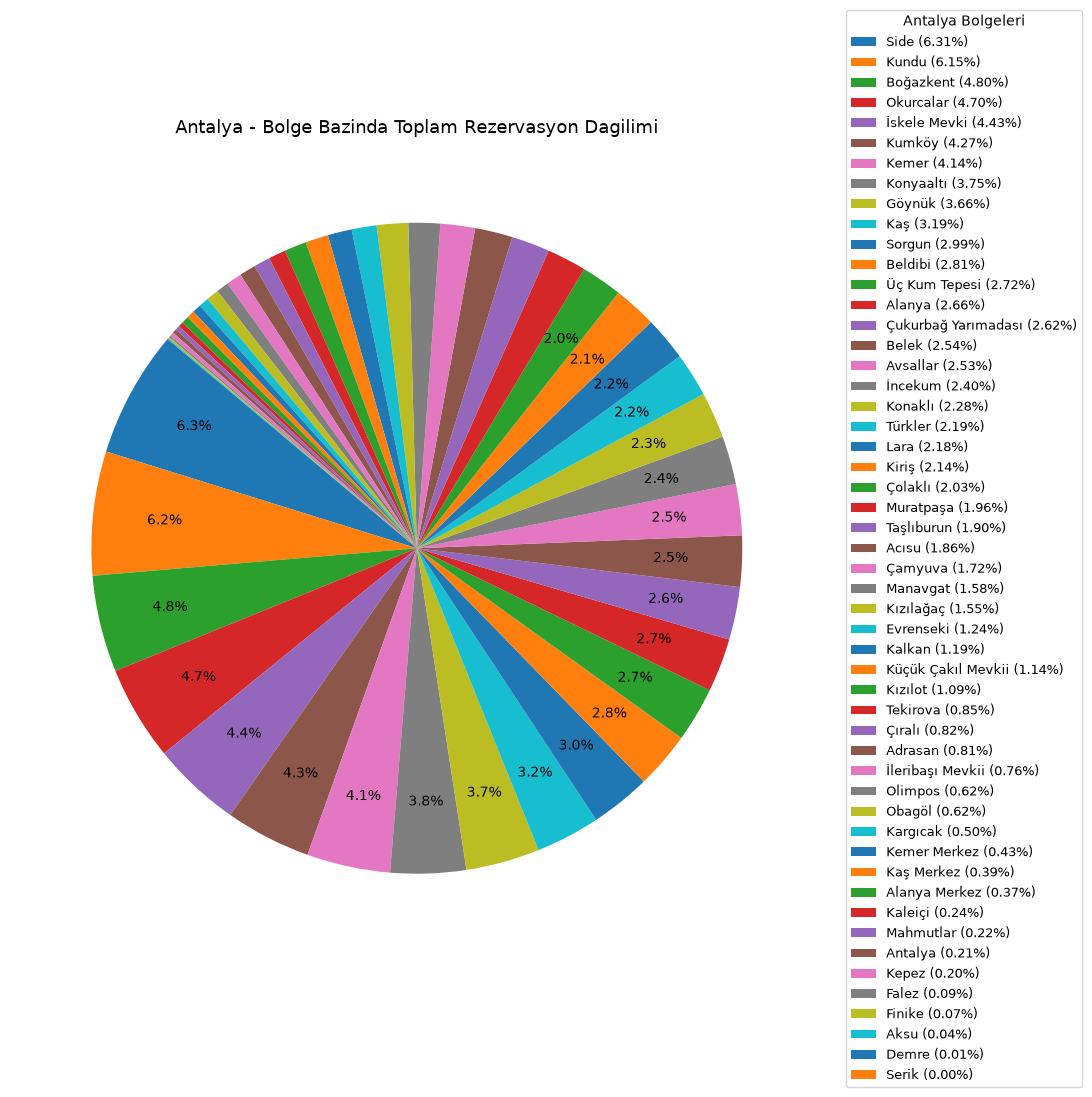

Not: 2026 verileri dislandi (YearId < 2026).

Antalya bolge rezervasyon detayi (ilk 30):


,TotalReservations,SharePct
HotelRegionName,,
Side,856,6.31
Kundu,835,6.15
Boğazkent,652,4.80
Okurcalar,638,4.70
İskele Mevki,601,4.43
Kumköy,579,4.27
Kemer,562,4.14
Konyaaltı,509,3.75
Göynük,497,3.66


In [15]:
import matplotlib.pyplot as plt

# Sadece Antalya: bolge satis dagilimi (ReservationFlag adet bazli)
selected_city = "Antalya"

city_df = df[df["CityName"] == selected_city].copy()
city_df["YearId"] = pd.to_numeric(city_df.get("YearId"), errors="coerce")
city_df = city_df[city_df["YearId"] < 2026].copy()
city_df["ReservationFlag"] = pd.to_numeric(city_df["ReservationFlag"], errors="coerce").fillna(0)

region_sales_city = (
    city_df.groupby("HotelRegionName", observed=True)["ReservationFlag"]
    .sum()
    .sort_values(ascending=False)
)

if region_sales_city.empty:
    print(f"'{selected_city}' icin veri bulunamadi.")
else:
    detail_df = region_sales_city.to_frame("TotalReservations")
    detail_df["SharePct"] = (detail_df["TotalReservations"] / detail_df["TotalReservations"].sum() * 100).round(2)

    def autopct_fmt(pct):
        return f"{pct:.1f}%" if pct >= 2 else ""

    plt.figure(figsize=(11, 11))
    wedges, texts, autotexts = plt.pie(
        detail_df["TotalReservations"].values,
        labels=None,
        autopct=autopct_fmt,
        startangle=140,
        pctdistance=0.78,
        textprops={"fontsize": 10},
    )

    legend_labels = [
        f"{idx} ({share:.2f}%)" for idx, share in zip(detail_df.index, detail_df["SharePct"])
    ]

    plt.legend(
        wedges,
        legend_labels,
        title="Antalya Bolgeleri",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
    )
    plt.title("Antalya - Bolge Bazinda Toplam Rezervasyon Dagilimi", fontsize=13)
    plt.tight_layout()
    plt.show()

    print("Not: 2026 verileri dislandi (YearId < 2026).")
    print("\nAntalya bolge rezervasyon detayi (ilk 30):")
    display(detail_df.head(30))

Not: 2026 verileri dislandi (YearId < 2026).
Sehir: Antalya

Yillik bolge rezervasyon pivotu:


HotelRegionName,Alanya,Beldibi,Boğazkent,Göynük,Kaş,Kemer,Konyaaltı,Kumköy,Kundu,Okurcalar,Side,Sorgun,Çukurbağ Yarımadası,Üç Kum Tepesi,İskele Mevki
YearId,,,,,,,,,,,,,,,
2023,127,62,219,147,114,179,166,187,231,210,255,121,102,120,181
2024,133,175,218,165,177,197,190,183,278,202,266,135,139,129,202
2025,101,145,215,185,142,186,153,209,326,226,335,150,114,120,218



Yillik bolge degisimi (%):


HotelRegionName,Alanya,Beldibi,Boğazkent,Göynük,Kaş,Kemer,Konyaaltı,Kumköy,Kundu,Okurcalar,Side,Sorgun,Çukurbağ Yarımadası,Üç Kum Tepesi,İskele Mevki
YearId,,,,,,,,,,,,,,,
2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024,4.72,182.26,-0.46,12.24,55.26,10.06,14.46,-2.14,20.35,-3.81,4.31,11.57,36.27,7.50,11.60
2025,-24.06,-17.14,-1.38,12.12,-19.77,-5.58,-19.47,14.21,17.27,11.88,25.94,11.11,-17.99,-6.98,7.92


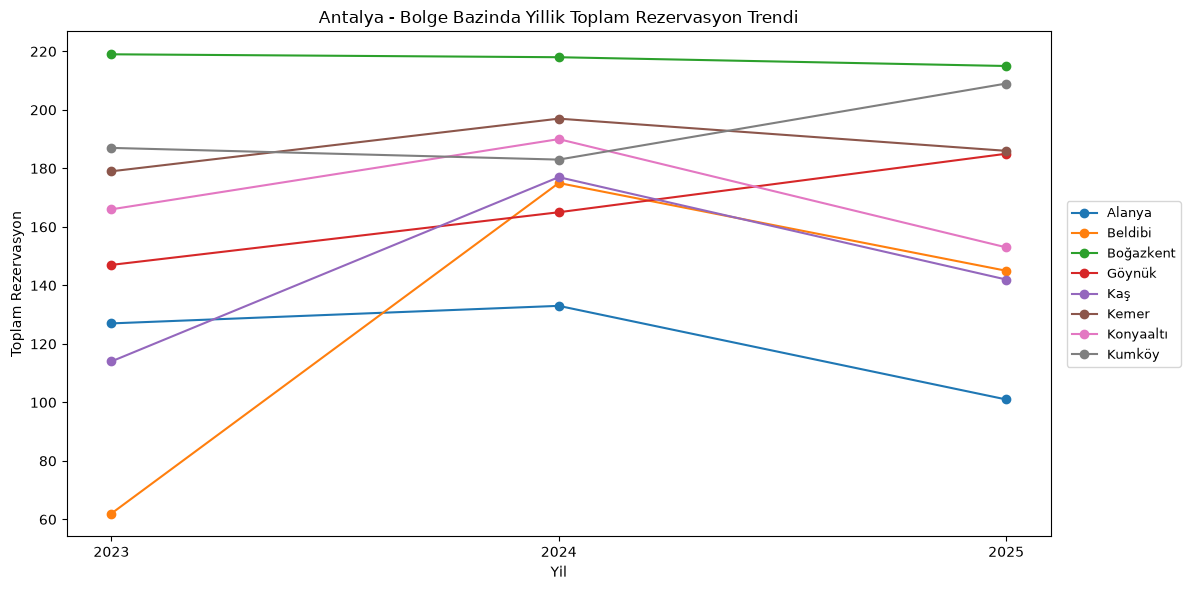

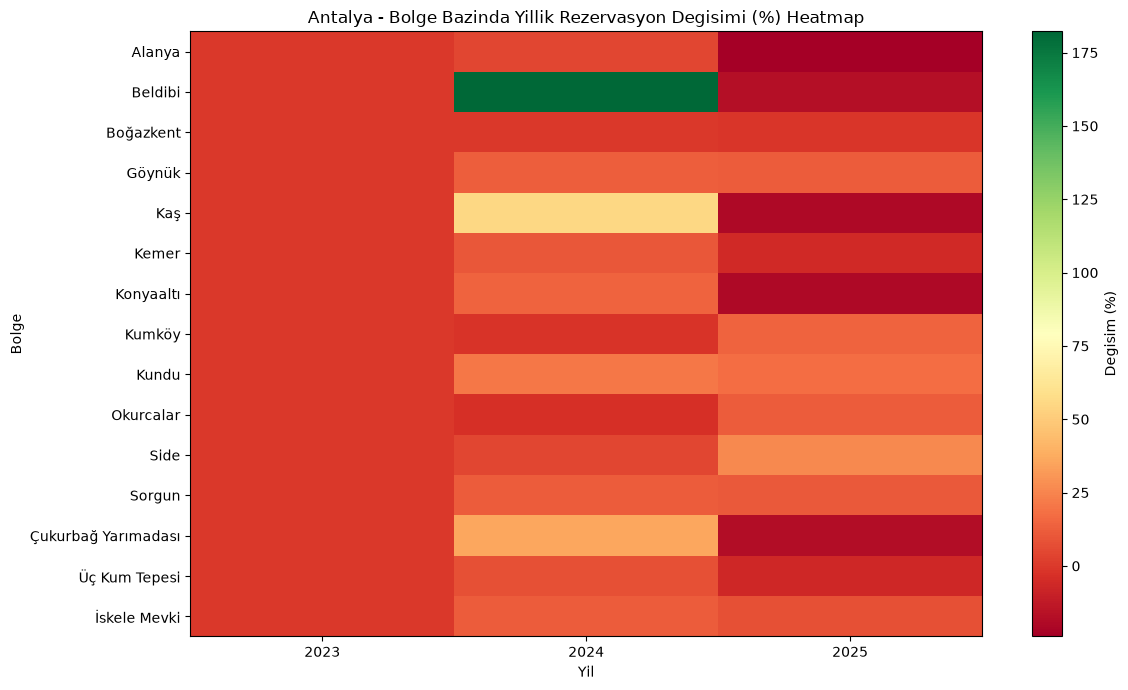

In [19]:
# Antalya icin yillar arasi bolgeler arasi degisim (ReservationFlag bazli)

import matplotlib.pyplot as plt

target_city = "Antalya"
max_regions = 15

change_df = df[df["CityName"] == target_city].copy()
change_df["ReservationFlag"] = pd.to_numeric(change_df["ReservationFlag"], errors="coerce").fillna(0)
change_df["YearId"] = pd.to_numeric(change_df["YearId"], errors="coerce")
change_df = change_df[change_df["YearId"] < 2026].copy()

year_region_sales = (
    change_df.groupby(["YearId", "HotelRegionName"], observed=True)["ReservationFlag"]
    .sum()
    .reset_index(name="TotalReservations")
)

if year_region_sales.empty:
    print(f"'{target_city}' icin yillik bolge verisi bulunamadi.")
else:
    top_regions = (
        year_region_sales.groupby("HotelRegionName", observed=True)["TotalReservations"]
        .sum()
        .sort_values(ascending=False)
        .head(max_regions)
        .index
    )

    year_region_pivot = (
        year_region_sales[year_region_sales["HotelRegionName"].isin(top_regions)]
        .pivot(index="YearId", columns="HotelRegionName", values="TotalReservations")
        .sort_index()
        .fillna(0)
    )

    yoy_pct = year_region_pivot.pct_change() * 100
    year_ticks = [int(y) for y in year_region_pivot.index.tolist()]

    print("Not: 2026 verileri dislandi (YearId < 2026).")
    print(f"Sehir: {target_city}")
    print("\nYillik bolge rezervasyon pivotu:")
    display(year_region_pivot.round(2))

    print("\nYillik bolge degisimi (%):")
    display(yoy_pct.round(2))

    plt.figure(figsize=(12, 6))
    for region in year_region_pivot.columns[:8]:
        plt.plot(year_ticks, year_region_pivot[region], marker="o", label=region)
    plt.title("Antalya - Bolge Bazinda Yillik Toplam Rezervasyon Trendi")
    plt.xlabel("Yil")
    plt.ylabel("Toplam Rezervasyon")
    plt.xticks(year_ticks, [str(y) for y in year_ticks])
    plt.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
    plt.tight_layout()
    plt.show()

    heatmap_data = yoy_pct.fillna(0).T
    fig, ax = plt.subplots(figsize=(12, 7))
    im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdYlGn")

    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels([str(int(y)) for y in heatmap_data.columns], rotation=0)
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)

    ax.set_title("Antalya - Bolge Bazinda Yillik Rezervasyon Degisimi (%) Heatmap")
    ax.set_xlabel("Yil")
    ax.set_ylabel("Bolge")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Degisim (%)")

    plt.tight_layout()
    plt.show()

Not: Veri setinde 5 yil yok, mevcut 3 yil kullanildi: [np.int64(2023), np.int64(2024), np.int64(2025)]
Not: 2026 verileri dislandi (YearId < 2026).
Sehir: Antalya
Donem: 2023-2025

Guclu artis yapan bolgeler (ozet):


,StartReservations,EndReservations,GrowthPct,CAGR_Pct
HotelRegionName,,,,
Kepez,3,12,300.0,100.0
Beldibi,62,145,133.870968,52.928404
Muratpaşa,52,106,103.846154,42.774701
Antalya,3,6,100.0,41.421356
Finike,2,4,100.0,41.421356
Kızılot,31,56,80.645161,34.404301
Kalkan,35,59,68.571429,29.83506
Taşlıburun,65,97,49.230769,22.160046



Artis grubunun yillik rezervasyon tablosu:


HotelRegionName,Kepez,Beldibi,Muratpaşa,Antalya,Finike,Kızılot,Kalkan,Taşlıburun
YearId,,,,,,,,
2023,3,62,52,3,2,31,35,65
2024,12,175,108,19,4,61,68,96
2025,12,145,106,6,4,56,59,97



Artis grubunun yillik degisim (%) tablosu:


...

,StartReservations,EndReservations,GrowthPct,CAGR_Pct
HotelRegionName,,,,
Falez,1,0,-100.0,-100.0
Mahmutlar,9,3,-66.666667,-42.264973
Manavgat,79,46,-41.772152,-23.692826
Kargıcak,29,17,-41.37931,-23.435851
Obagöl,27,16,-40.740741,-23.019964
Belek,136,89,-34.558824,-19.104279
Tekirova,44,32,-27.272727,-14.719713
Çamyuva,88,65,-26.136364,-14.056044



Dusus grubunun yillik rezervasyon tablosu:


HotelRegionName,Falez,Mahmutlar,Manavgat,Kargıcak,Obagöl,Belek,Tekirova,Çamyuva
YearId,,,,,,,,
2023,1,9,79,29,27,136,44,88
2024,11,18,89,22,41,120,40,80
2025,0,3,46,17,16,89,32,65



Dusus grubunun yillik degisim (%) tablosu:


HotelRegionName,Falez,Mahmutlar,Manavgat,Kargıcak,Obagöl,Belek,Tekirova,Çamyuva
YearId,,,,,,,,
2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024,1000.0,100.00,12.66,-24.14,51.85,-11.76,-9.09,-9.09
2025,-100.0,-83.33,-48.31,-22.73,-60.98,-25.83,-20.00,-18.75


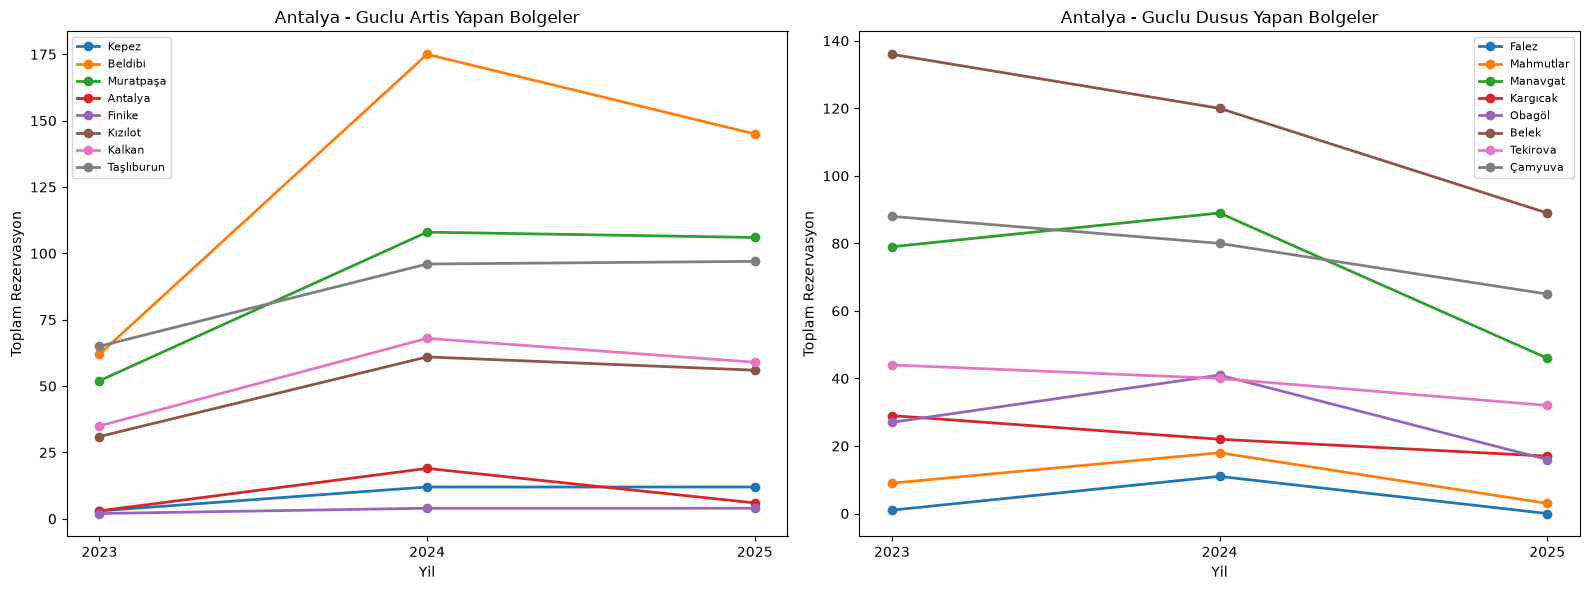

In [20]:
# Guclu artis ve dusus yapan bolgelerin son 5 yillik (eldeki kadar) degisimi (ReservationFlag bazli)

import matplotlib.pyplot as plt

target_city = "Antalya"
lookback_years = 5
strong_region_count = 8
falling_region_count = 8

trend_df = df[df["CityName"] == target_city].copy()
trend_df["ReservationFlag"] = pd.to_numeric(trend_df["ReservationFlag"], errors="coerce").fillna(0)
trend_df["YearId"] = pd.to_numeric(trend_df["YearId"], errors="coerce")
trend_df = trend_df[trend_df["YearId"] < 2026].copy()

year_region = (
    trend_df.groupby(["YearId", "HotelRegionName"], observed=True)["ReservationFlag"]
    .sum()
    .reset_index(name="TotalReservations")
)

if year_region.empty:
    print(f"'{target_city}' icin bolge-yil verisi bulunamadi.")
else:
    all_years = sorted(year_region["YearId"].dropna().astype(int).unique())
    selected_years = all_years[-lookback_years:]

    if len(selected_years) < lookback_years:
        print(f"Not: Veri setinde {lookback_years} yil yok, mevcut {len(selected_years)} yil kullanildi: {selected_years}")

    yr_pivot = (
        year_region[year_region["YearId"].isin(selected_years)]
        .pivot(index="YearId", columns="HotelRegionName", values="TotalReservations")
        .sort_index()
        .fillna(0)
    )

    first_year = int(yr_pivot.index.min())
    last_year = int(yr_pivot.index.max())
    period_count = max(len(yr_pivot.index) - 1, 1)

    growth_stats = pd.DataFrame({
        "StartReservations": yr_pivot.loc[first_year],
        "EndReservations": yr_pivot.loc[last_year],
    })
    growth_stats["GrowthPct"] = (growth_stats["EndReservations"] / growth_stats["StartReservations"].replace(0, pd.NA) - 1) * 100
    growth_stats["CAGR_Pct"] = (
        (growth_stats["EndReservations"] / growth_stats["StartReservations"].replace(0, pd.NA)) ** (1 / period_count) - 1
    ) * 100

    valid_stats = growth_stats.dropna(subset=["GrowthPct", "CAGR_Pct"]).copy()

    rising_regions = (
        valid_stats.query("GrowthPct > 0")
        .sort_values(["GrowthPct", "CAGR_Pct"], ascending=False)
        .head(strong_region_count)
        .index
    )

    falling_regions = (
        valid_stats.query("GrowthPct < 0")
        .sort_values(["GrowthPct", "CAGR_Pct"], ascending=True)
        .head(falling_region_count)
        .index
    )

    year_ticks = [int(y) for y in yr_pivot.index.tolist()]

    print("Not: 2026 verileri dislandi (YearId < 2026).")
    print(f"Sehir: {target_city}")
    print(f"Donem: {first_year}-{last_year}")

    if len(rising_regions) > 0:
        print("\nGuclu artis yapan bolgeler (ozet):")
        display(valid_stats.loc[rising_regions, ["StartReservations", "EndReservations", "GrowthPct", "CAGR_Pct"]].round(2))

        rising_trend = yr_pivot.loc[:, rising_regions]
        rising_yoy = rising_trend.pct_change() * 100
        print("\nArtis grubunun yillik rezervasyon tablosu:")
        display(rising_trend.round(2))
        print("\nArtis grubunun yillik degisim (%) tablosu:")
        display(rising_yoy.round(2))
    else:
        print("\nArtis gosteren bolge bulunamadi.")

    if len(falling_regions) > 0:
        print("\nGuclu dusus yapan bolgeler (ozet):")
        display(valid_stats.loc[falling_regions, ["StartReservations", "EndReservations", "GrowthPct", "CAGR_Pct"]].round(2))

        falling_trend = yr_pivot.loc[:, falling_regions]
        falling_yoy = falling_trend.pct_change() * 100
        print("\nDusus grubunun yillik rezervasyon tablosu:")
        display(falling_trend.round(2))
        print("\nDusus grubunun yillik degisim (%) tablosu:")
        display(falling_yoy.round(2))
    else:
        print("\nDusus gosteren bolge bulunamadi.")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

    if len(rising_regions) > 0:
        for region in rising_regions:
            axes[0].plot(year_ticks, yr_pivot[region], marker="o", linewidth=2, label=region)
        axes[0].set_title(f"{target_city} - Guclu Artis Yapan Bolgeler")
        axes[0].set_xlabel("Yil")
        axes[0].set_ylabel("Toplam Rezervasyon")
        axes[0].set_xticks(year_ticks)
        axes[0].set_xticklabels([str(y) for y in year_ticks])
        axes[0].legend(fontsize=8)
    else:
        axes[0].set_title("Artis verisi yok")
        axes[0].axis("off")

    if len(falling_regions) > 0:
        for region in falling_regions:
            axes[1].plot(year_ticks, yr_pivot[region], marker="o", linewidth=2, label=region)
        axes[1].set_title(f"{target_city} - Guclu Dusus Yapan Bolgeler")
        axes[1].set_xlabel("Yil")
        axes[1].set_ylabel("Toplam Rezervasyon")
        axes[1].set_xticks(year_ticks)
        axes[1].set_xticklabels([str(y) for y in year_ticks])
        axes[1].legend(fontsize=8)
    else:
        axes[1].set_title("Dusus verisi yok")
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()

Not: Veri setinde 5 yil yok, mevcut 3 yil kullanildi: [2023, 2024, 2025]
Not: 2026 verileri dislandi (YearId < 2026).
Sehir: Antalya

Antalya toplam rezervasyon ve ciro (yillik):


,TotalReservations,TotalRevenue,YoY_Pct
YearId,,,
2023,4132,11367855.15,NaN
2024,4825,20525024.50,16.77
2025,4615,26247671.30,-4.35


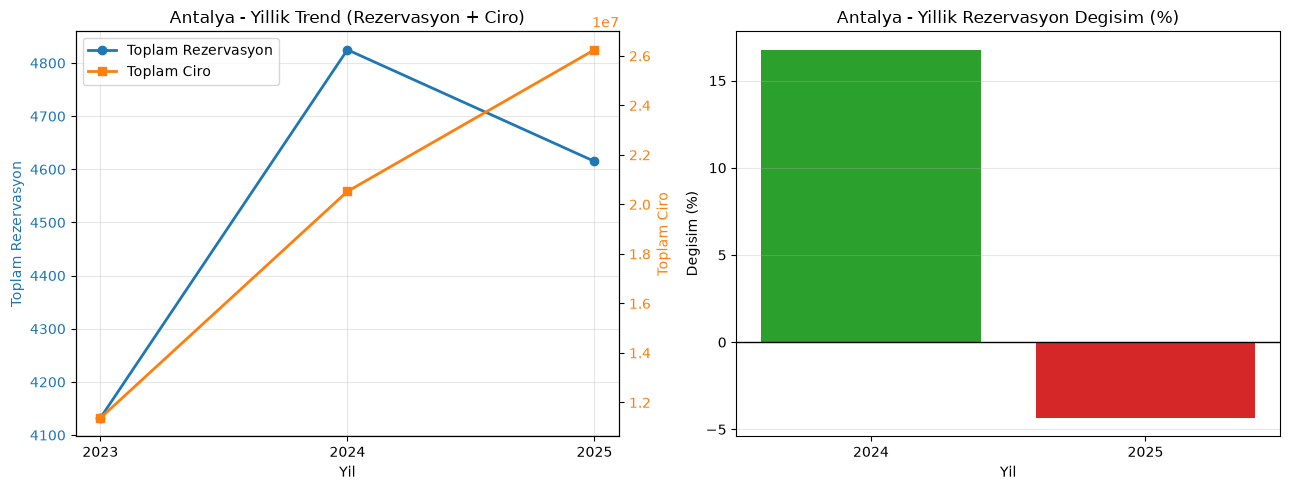

In [22]:
# Tum Antalya icin son 5 yillik (eldeki kadar) toplam rezervasyon trendi

import matplotlib.pyplot as plt

target_city = "Antalya"
lookback_years = 5

city_total_df = df[df["CityName"] == target_city].copy()
city_total_df["ReservationFlag"] = pd.to_numeric(city_total_df["ReservationFlag"], errors="coerce").fillna(0)
city_total_df["AvgSellingPrice"] = pd.to_numeric(city_total_df["AvgSellingPrice"], errors="coerce").fillna(0)
city_total_df["YearId"] = pd.to_numeric(city_total_df["YearId"], errors="coerce")
city_total_df = city_total_df[city_total_df["YearId"] < 2026].copy()

annual_total = (
    city_total_df.groupby("YearId", observed=True)["ReservationFlag"]
    .sum()
    .sort_index()
)

annual_revenue = (
    city_total_df.groupby("YearId", observed=True)["AvgSellingPrice"]
    .sum()
    .sort_index()
)

if annual_total.empty:
    print(f"'{target_city}' icin yillik toplam rezervasyon verisi bulunamadi.")
else:
    selected_years = annual_total.index.astype(int).tolist()[-lookback_years:]
    if len(selected_years) < lookback_years:
        print(f"Not: Veri setinde {lookback_years} yil yok, mevcut {len(selected_years)} yil kullanildi: {selected_years}")

    antalya_5y = annual_total.loc[selected_years]
    antalya_revenue_5y = annual_revenue.loc[selected_years]
    antalya_yoy = antalya_5y.pct_change() * 100

    summary_df = antalya_5y.to_frame("TotalReservations")
    summary_df["TotalRevenue"] = antalya_revenue_5y.round(2)
    summary_df["YoY_Pct"] = antalya_yoy.round(2)

    print("Not: 2026 verileri dislandi (YearId < 2026).")
    print(f"Sehir: {target_city}")
    print("\nAntalya toplam rezervasyon ve ciro (yillik):")
    display(summary_df)

    year_ticks = [int(y) for y in antalya_5y.index.tolist()]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Sol grafik: rezervasyon + ciro (ikili eksen)
    line_res = axes[0].plot(
        year_ticks,
        antalya_5y.values,
        marker="o",
        linewidth=2,
        color="#1f77b4",
        label="Toplam Rezervasyon",
    )
    axes[0].set_title("Antalya - Yillik Trend (Rezervasyon + Ciro)")
    axes[0].set_xlabel("Yil")
    axes[0].set_ylabel("Toplam Rezervasyon", color="#1f77b4")
    axes[0].tick_params(axis="y", labelcolor="#1f77b4")
    axes[0].set_xticks(year_ticks)
    axes[0].set_xticklabels([str(y) for y in year_ticks])
    axes[0].grid(alpha=0.3)

    ax2 = axes[0].twinx()
    line_rev = ax2.plot(
        year_ticks,
        antalya_revenue_5y.values,
        marker="s",
        linewidth=2,
        color="#ff7f0e",
        label="Toplam Ciro",
    )
    ax2.set_ylabel("Toplam Ciro", color="#ff7f0e")
    ax2.tick_params(axis="y", labelcolor="#ff7f0e")

    lines = line_res + line_rev
    labels = [l.get_label() for l in lines]
    axes[0].legend(lines, labels, loc="best")

    # Sag grafik: rezervasyon yillik degisim yuzdesi
    yoy_plot = antalya_yoy.dropna()
    bar_years = [int(y) for y in yoy_plot.index.tolist()]
    colors = ["#2ca02c" if v >= 0 else "#d62728" for v in yoy_plot.values]
    axes[1].bar(bar_years, yoy_plot.values, color=colors)
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("Antalya - Yillik Rezervasyon Degisim (%)")
    axes[1].set_xlabel("Yil")
    axes[1].set_ylabel("Degisim (%)")
    axes[1].set_xticks(bar_years)
    axes[1].set_xticklabels([str(y) for y in bar_years])
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [23]:
# Antalya bolge listesini goster

antalya_regions = (
    df.loc[df["CityName"] == "Antalya", "HotelRegionName"]
    .dropna()
    .astype(str)
    .str.strip()
)

antalya_region_list = sorted(antalya_regions.unique())
antalya_region_df = pd.DataFrame({"No": range(1, len(antalya_region_list) + 1), "HotelRegionName": antalya_region_list})

print(f"Antalya bolge sayisi: {len(antalya_region_list)}")
display(antalya_region_df)

Antalya bolge sayisi: 52


,No,HotelRegionName
0,1,Acısu
1,2,Adrasan
2,3,Aksu
3,4,Alanya
4,5,Alanya Merkez
5,6,Antalya
6,7,Avsallar
7,8,Beldibi
8,9,Belek
9,10,Boğazkent


In [2]:
# Antalya bolgelerini resmi Antalya ilceleri ile kiyasla ve ilce atamasi yap

import re
import unicodedata

official_districts = [
    "Akseki", "Aksu", "Alanya", "Demre", "Döşemealtı", "Elmalı", "Finike",
    "Gazipaşa", "Gündoğmuş", "İbradı", "Kaş", "Kemer", "Kepez", "Konyaaltı",
    "Korkuteli", "Kumluca", "Manavgat", "Muratpaşa", "Serik",
]

def normalize_tr(text):
    text = str(text).strip().lower().replace("i̇", "i")
    tr_map = str.maketrans({
        "ç": "c", "ğ": "g", "ı": "i", "ö": "o", "ş": "s", "ü": "u",
        "â": "a", "î": "i", "û": "u",
    })
    text = text.translate(tr_map)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9 ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Turizm bolgesi/mevkii adlari icin ilce esleme bilgisi
manual_region_to_district = {
    "acisu": "Serik",
    "adrasan": "Kumluca",
    "antalya": "Muratpaşa",
    "avsallar": "Alanya",
    "beldibi": "Kemer",
    "belek": "Serik",
    "bogazkent": "Serik",
    "evrenseki": "Manavgat",
    "falez": "Muratpaşa",
    "goynuk": "Kemer",
    "kaleici": "Muratpaşa",
    "kalkan": "Kaş",
    "kargicak": "Alanya",
    "kiris": "Kemer",
    "konakli": "Alanya",
    "kumkoy": "Manavgat",
    "kundu": "Aksu",
    "kucuk cakil mevkii": "Kaş",
    "kizilagac": "Manavgat",
    "kizilot": "Manavgat",
    "lara": "Muratpaşa",
    "mahmutlar": "Alanya",
    "obagol": "Alanya",
    "okurcalar": "Alanya",
    "olimpos": "Kumluca",
    "side": "Manavgat",
    "sorgun": "Manavgat",
    "tasliburun": "Serik",
    "tekirova": "Kemer",
    "turkler": "Alanya",
    "camyuva": "Kemer",
    "colakli": "Manavgat",
    "cukurbag yarimadasi": "Kaş",
    "cirali": "Kemer",
    "uc kum tepesi": "Serik",
    "ileribasi mevkii": "Serik",
    "incekum": "Alanya",
    "iskele mevki": "Serik",
}

official_norm_to_name = {normalize_tr(d): d for d in official_districts}

region_list = sorted(
    df.loc[df["CityName"] == "Antalya", "HotelRegionName"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

assigned_rows = []
for region in region_list:
    r_norm = normalize_tr(region)

    # 1) Dogrudan resmi ilce adi veya alt ifadesi olarak geciyorsa
    exact_matches = [
        official_norm_to_name[k]
        for k in official_norm_to_name
        if k in r_norm or r_norm in k
    ]

    assigned_district = None
    source = None

    if len(exact_matches) > 0:
        assigned_district = exact_matches[0]
        source = "exact_or_contains"
    elif r_norm in manual_region_to_district:
        assigned_district = manual_region_to_district[r_norm]
        source = "manual_mapping"
    else:
        assigned_district = "Bilinmiyor"
        source = "unmapped"

    assigned_rows.append({
        "HotelRegionName": region,
        "AssignedDistrict": assigned_district,
        "MappingSource": source,
    })

mapping_df = pd.DataFrame(assigned_rows).sort_values(["AssignedDistrict", "HotelRegionName"]).reset_index(drop=True)

unknown_df = mapping_df[mapping_df["AssignedDistrict"] == "Bilinmiyor"].copy()

district_cover_df = (
    mapping_df[mapping_df["AssignedDistrict"] != "Bilinmiyor"]
    .groupby("AssignedDistrict", as_index=False)
    .size()
    .rename(columns={"size": "RegionCount"})
    .sort_values("AssignedDistrict")
)

print(f"Toplam Antalya bolgesi: {len(region_list)}")
print(f"Ilce atanabilen bolge sayisi: {(mapping_df['AssignedDistrict'] != 'Bilinmiyor').sum()}")
print(f"Atanamayan bolge sayisi: {len(unknown_df)}")
print("\nBolgelerin ilce atama tablosu:")
display(mapping_df)

print("\nIlce bazinda bolge sayilari:")
display(district_cover_df)

if len(unknown_df) > 0:
    print("\nAtanamayip manuel kontrol isteyenler:")
    display(unknown_df)

Toplam Antalya bolgesi: 52
Ilce atanabilen bolge sayisi: 52
Atanamayan bolge sayisi: 0

Bolgelerin ilce atama tablosu:


,HotelRegionName,AssignedDistrict,MappingSource
0,Aksu,Aksu,exact_or_contains
1,Kundu,Aksu,manual_mapping
2,Alanya,Alanya,exact_or_contains
3,Alanya Merkez,Alanya,exact_or_contains
4,Avsallar,Alanya,manual_mapping
5,Kargıcak,Alanya,manual_mapping
6,Konaklı,Alanya,manual_mapping
7,Mahmutlar,Alanya,manual_mapping
8,Obagöl,Alanya,manual_mapping
9,Okurcalar,Alanya,manual_mapping



Ilce bazinda bolge sayilari:


,AssignedDistrict,RegionCount
0,Aksu,2
1,Alanya,10
2,Demre,1
3,Finike,1
4,Kaş,5
5,Kemer,8
6,Kepez,1
7,Konyaaltı,1
8,Kumluca,2
9,Manavgat,8


Not: 2026 verileri dislandi (YearId < 2026).
Sehir: Antalya
Kullanilan yillar: [np.int64(2023), np.int64(2024), np.int64(2025)]

Ilce bazli yillik toplam rezervasyon:


AssignedDistrict,Aksu,Alanya,Demre,Finike,Kaş,Kemer,Kepez,Konyaaltı,Kumluca,Manavgat,Muratpaşa,Serik
YearId,,,,,,,,,,,,
2023,231,793,0,2,317,683,3,166,58,902,151,826
2024,282,912,1,4,465,789,12,190,71,955,262,882
2025,328,803,0,4,376,778,12,153,65,1001,222,873



Ilce bazli yillik degisim (%):


AssignedDistrict,Aksu,Alanya,Demre,Finike,Kaş,Kemer,Kepez,Konyaaltı,Kumluca,Manavgat,Muratpaşa,Serik
YearId,,,,,,,,,,,,
2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024,22.08,15.01,inf,100.0,46.69,15.52,300.0,14.46,22.41,5.88,73.51,6.78
2025,16.31,-11.95,-100.0,0.0,-19.14,-1.39,0.0,-19.47,-8.45,4.82,-15.27,-1.02


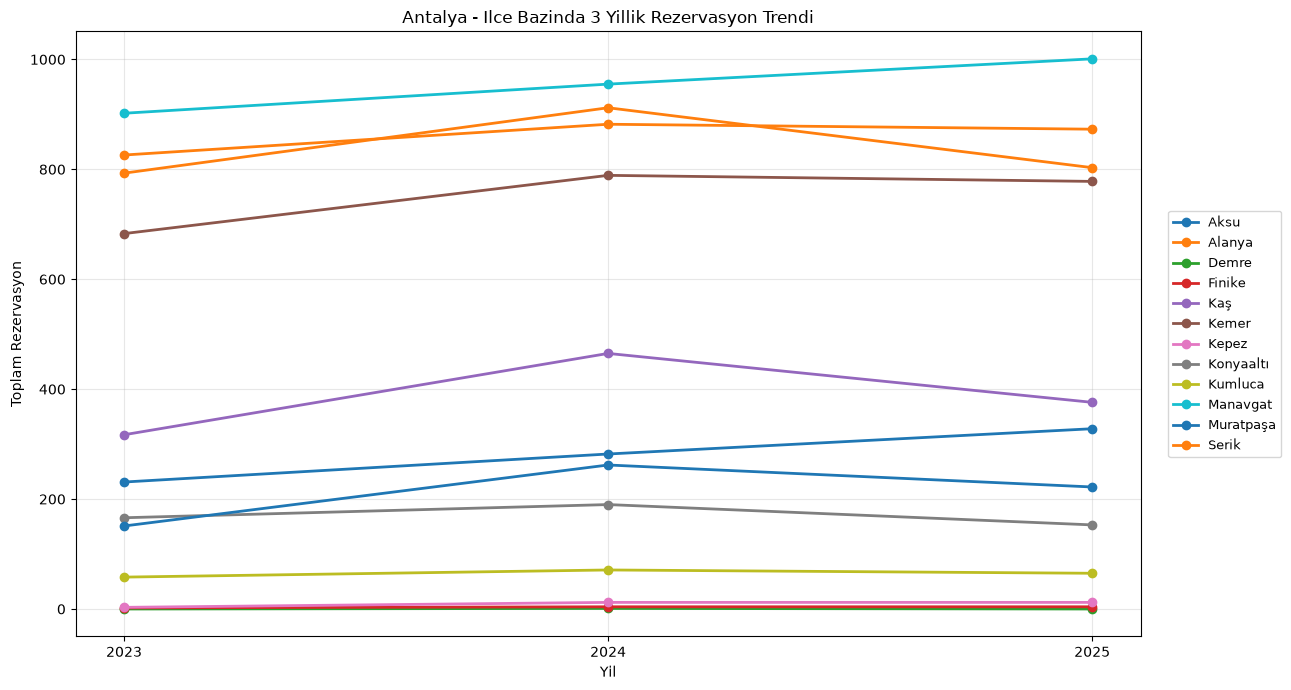

In [27]:
# Antalya ilcelerine gore 3 yillik trend (ReservationFlag bazli)

import matplotlib.pyplot as plt

target_city = "Antalya"
trend_year_count = 3

if "mapping_df" not in globals():
    print("Once ilce atama hucresini calistirin.")
else:
    district_map = mapping_df[["HotelRegionName", "AssignedDistrict"]].copy()

    district_trend_df = df[df["CityName"] == target_city].copy()
    district_trend_df["YearId"] = pd.to_numeric(district_trend_df["YearId"], errors="coerce")
    district_trend_df["ReservationFlag"] = pd.to_numeric(district_trend_df["ReservationFlag"], errors="coerce").fillna(0)
    district_trend_df = district_trend_df[district_trend_df["YearId"] < 2026].copy()

    district_trend_df = district_trend_df.merge(district_map, on="HotelRegionName", how="left")
    district_trend_df["AssignedDistrict"] = district_trend_df["AssignedDistrict"].fillna("Bilinmiyor")

    available_years = sorted(district_trend_df["YearId"].dropna().astype(int).unique())
    selected_years = available_years[-trend_year_count:]

    if len(selected_years) < trend_year_count:
        print(f"Not: Veri setinde {trend_year_count} yil yok, mevcut {len(selected_years)} yil kullanildi: {selected_years}")

    district_year = (
        district_trend_df[district_trend_df["YearId"].isin(selected_years)]
        .groupby(["YearId", "AssignedDistrict"], observed=True)["ReservationFlag"]
        .sum()
        .reset_index(name="TotalReservations")
    )

    district_pivot = (
        district_year
        .pivot(index="YearId", columns="AssignedDistrict", values="TotalReservations")
        .sort_index()
        .fillna(0)
    )

    district_yoy = district_pivot.pct_change() * 100
    year_ticks = [int(y) for y in district_pivot.index.tolist()]

    print("Not: 2026 verileri dislandi (YearId < 2026).")
    print(f"Sehir: {target_city}")
    print(f"Kullanilan yillar: {selected_years}")

    print("\nIlce bazli yillik toplam rezervasyon:")
    display(district_pivot.round(2))

    print("\nIlce bazli yillik degisim (%):")
    display(district_yoy.round(2))

    plt.figure(figsize=(13, 7))
    for district in district_pivot.columns:
        plt.plot(year_ticks, district_pivot[district], marker="o", linewidth=2, label=district)
    plt.title("Antalya - Ilce Bazinda 3 Yillik Rezervasyon Trendi")
    plt.xlabel("Yil")
    plt.ylabel("Toplam Rezervasyon")
    plt.xticks(year_ticks, [str(y) for y in year_ticks])
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Not: 2026 verileri dislandi (YearId < 2026).
Sehir: Antalya
Gosterilen donem: 2023-01 - 2025-12

Aylik ilce rezervasyon pivotu (gosterilen donem, ilk 20 satir):


AssignedDistrict,Aksu,Alanya,Demre,Finike,Kaş,Kemer,Kepez,Konyaaltı,Kumluca,Manavgat,Muratpaşa,Serik
Period,,,,,,,,,,,,
2023-01-01,14,5,0,0,0,4,1,11,0,16,13,42
2023-02-01,10,8,0,0,1,5,1,5,1,5,15,23
2023-03-01,9,10,0,0,0,2,0,12,2,7,15,15
2023-04-01,18,29,0,0,4,38,0,15,2,46,15,44
2023-05-01,17,48,0,0,16,52,0,11,5,60,8,60
2023-06-01,23,125,0,0,48,107,0,20,11,134,16,101
2023-07-01,34,163,0,0,64,145,0,17,12,210,14,138
2023-08-01,32,147,0,0,84,122,0,23,11,197,10,124
2023-09-01,27,134,0,2,66,104,0,21,11,129,9,107


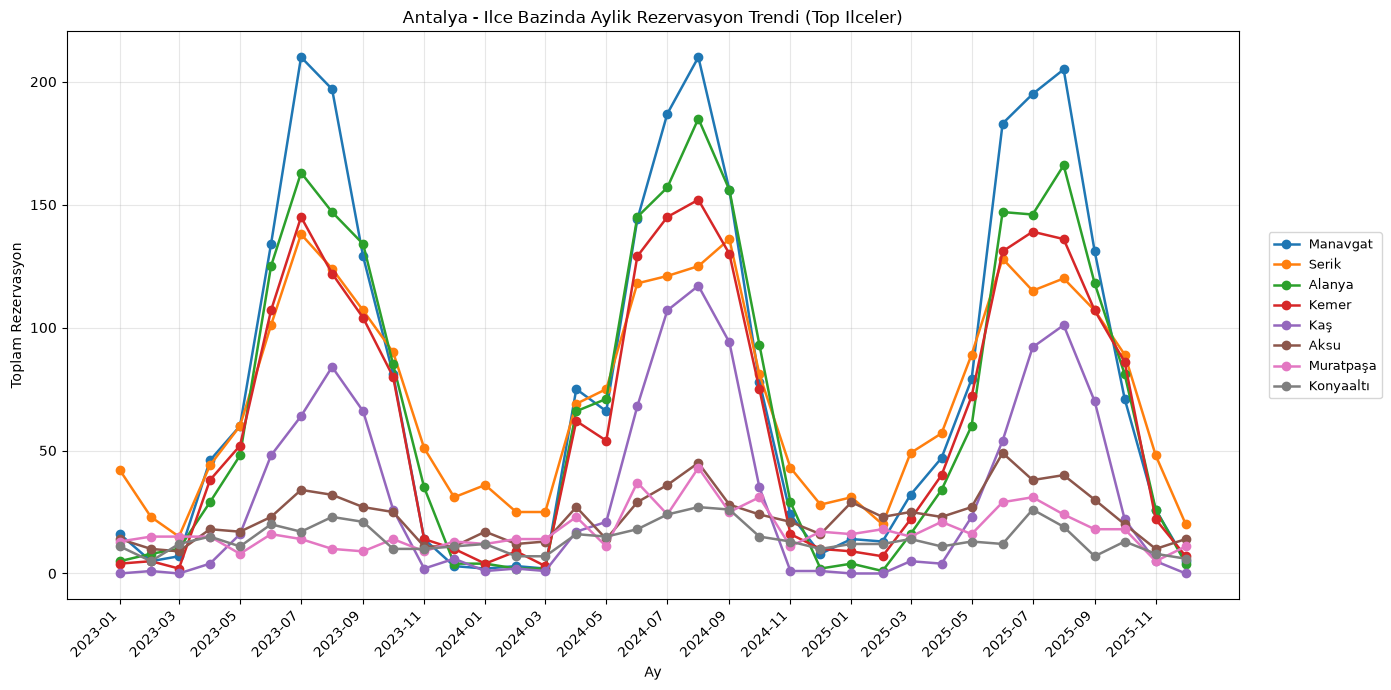

In [29]:
# Antalya ilcelerine gore aylik trend (ReservationFlag bazli)

import matplotlib.pyplot as plt

target_city = "Antalya"
last_n_months = 36  # 2023-2025 donemini kapsayacak sekilde genisletildi
plot_top_districts = 8

if "mapping_df" not in globals():
    print("Once ilce atama hucresini calistirin.")
else:
    district_map = mapping_df[["HotelRegionName", "AssignedDistrict"]].copy()

    monthly_df = df[df["CityName"] == target_city].copy()
    monthly_df["YearId"] = pd.to_numeric(monthly_df["YearId"], errors="coerce")
    monthly_df["MonthId"] = pd.to_numeric(monthly_df["MonthId"], errors="coerce")
    monthly_df["ReservationFlag"] = pd.to_numeric(monthly_df["ReservationFlag"], errors="coerce").fillna(0)
    monthly_df = monthly_df[monthly_df["YearId"] < 2026].copy()

    monthly_df = monthly_df.merge(district_map, on="HotelRegionName", how="left")
    monthly_df["AssignedDistrict"] = monthly_df["AssignedDistrict"].fillna("Bilinmiyor")

    monthly_df["Period"] = pd.to_datetime(
        monthly_df["YearId"].astype("Int64").astype(str) + "-" + monthly_df["MonthId"].astype("Int64").astype(str).str.zfill(2) + "-01",
        errors="coerce",
    )

    district_month = (
        monthly_df.groupby(["Period", "AssignedDistrict"], observed=True)["ReservationFlag"]
        .sum()
        .reset_index(name="TotalReservations")
        .dropna(subset=["Period"])
        .sort_values("Period")
    )

    if district_month.empty:
        print("Aylik ilce verisi bulunamadi.")
    else:
        all_periods = sorted(district_month["Period"].unique())
        selected_periods = all_periods[-last_n_months:]

        district_month_recent = district_month[district_month["Period"].isin(selected_periods)].copy()

        district_pivot_monthly = (
            district_month_recent
            .pivot(index="Period", columns="AssignedDistrict", values="TotalReservations")
            .fillna(0)
            .sort_index()
        )

        top_districts = (
            district_pivot_monthly.sum(axis=0)
            .sort_values(ascending=False)
            .head(plot_top_districts)
            .index
        )

        district_plot_df = district_pivot_monthly.loc[:, top_districts]

        print("Not: 2026 verileri dislandi (YearId < 2026).")
        print(f"Sehir: {target_city}")
        print(f"Gosterilen donem: {district_plot_df.index.min().strftime('%Y-%m')} - {district_plot_df.index.max().strftime('%Y-%m')}")

        print("\nAylik ilce rezervasyon pivotu (gosterilen donem, ilk 20 satir):")
        display(district_pivot_monthly.head(20))

        plt.figure(figsize=(14, 7))
        for district in district_plot_df.columns:
            plt.plot(district_plot_df.index, district_plot_df[district], marker="o", linewidth=1.8, label=district)

        xticks = district_plot_df.index[::2] if len(district_plot_df.index) > 12 else district_plot_df.index
        plt.xticks(xticks, [d.strftime("%Y-%m") for d in xticks], rotation=45, ha="right")

        plt.title("Antalya - Ilce Bazinda Aylik Rezervasyon Trendi (Top Ilceler)")
        plt.xlabel("Ay")
        plt.ylabel("Toplam Rezervasyon")
        plt.grid(alpha=0.3)
        plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
        plt.tight_layout()
        plt.show()

Not: 2026 verileri dislandi (YearId < 2026).
Analiz donemi: 2023-01 - 2025-12
Kullanilan filtre kurali: yumusak (yillik ilk-son karsilastirma)
Dusus trendinde bulunan ilce sayisi: 1


,District,FirstYear,LastYear,FirstYearTotal,LastYearTotal,ChangePct
0,Konyaaltı,2023,2025,166.0,153.0,-7.831325


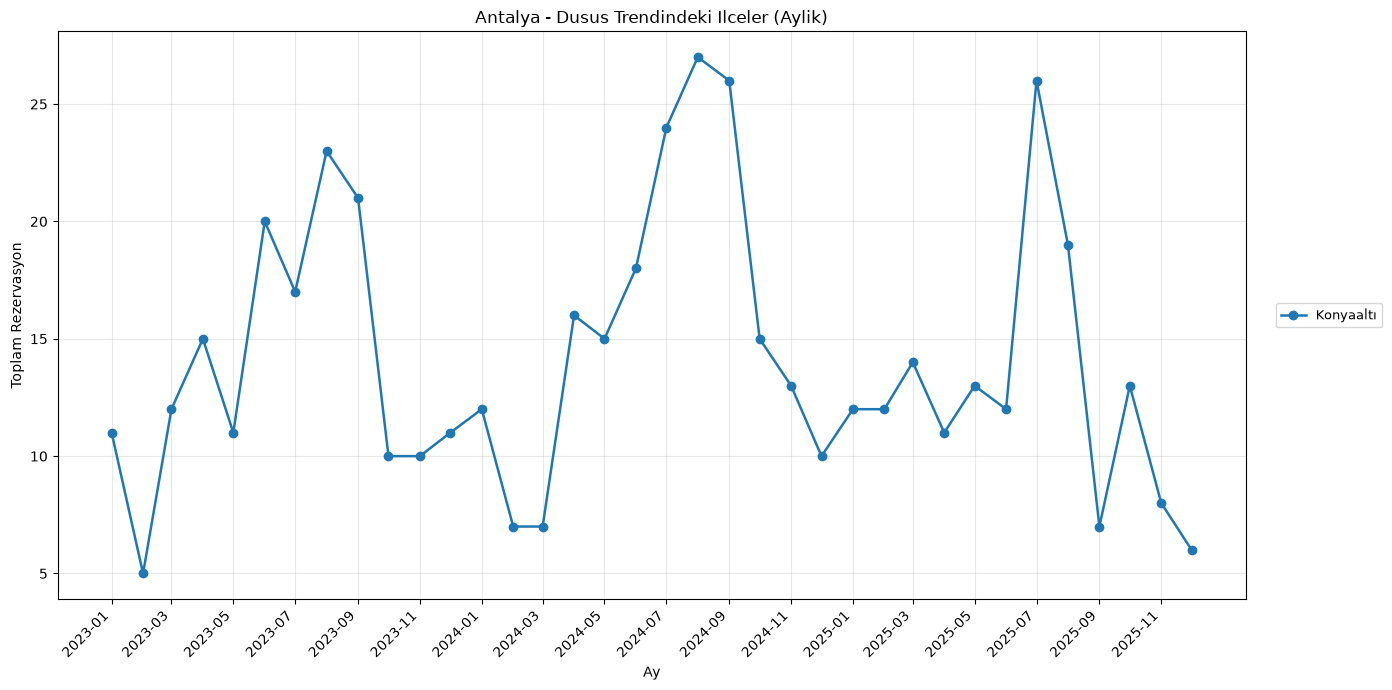

In [31]:
# Dusus trendindeki ilceleri filtrele (aylik, ReservationFlag)

import numpy as np
import matplotlib.pyplot as plt

if "district_pivot_monthly" not in globals() or district_pivot_monthly.empty:
    print("Once aylik ilce trendi hucresini calistirin.")
else:
    trend_source = district_pivot_monthly.copy().sort_index()

    # Denge icin donemin basi ve sonundan 6 aylik ortalamalari karsilastir
    edge_window = min(6, max(1, len(trend_source) // 4))

    decline_rows = []
    for district in trend_source.columns:
        y = trend_source[district].astype(float).values
        x = np.arange(len(y), dtype=float)

        slope = np.polyfit(x, y, 1)[0] if len(y) >= 2 else 0.0
        start_avg = float(np.mean(y[:edge_window]))
        end_avg = float(np.mean(y[-edge_window:]))

        if start_avg > 0:
            pct_change = ((end_avg - start_avg) / start_avg) * 100
        else:
            pct_change = np.nan

        decline_rows.append(
            {
                "District": district,
                "SlopePerMonth": slope,
                "StartAvg": start_avg,
                "EndAvg": end_avg,
                "ChangePct": pct_change,
            }
        )

    decline_stats = pd.DataFrame(decline_rows)

    # Kati kural: hem egim negatif hem de donem sonu ortalama daha dusuk
    declining_districts = (
        decline_stats[(decline_stats["SlopePerMonth"] < 0) & (decline_stats["ChangePct"] < 0)]
        .sort_values("ChangePct")
        .reset_index(drop=True)
    )

    print("Not: 2026 verileri dislandi (YearId < 2026).")
    print(f"Analiz donemi: {trend_source.index.min().strftime('%Y-%m')} - {trend_source.index.max().strftime('%Y-%m')}")

    # Eger kati kural bos donerse, yumusak kurala gec: son yil ilk yildan dusukse dusus kabul et
    used_rule = "kati"
    if declining_districts.empty:
        yearly_totals = trend_source.copy()
        yearly_totals["Year"] = yearly_totals.index.year
        yearly_totals = yearly_totals.groupby("Year").sum(numeric_only=True)

        if len(yearly_totals) >= 2:
            first_year = int(yearly_totals.index.min())
            last_year = int(yearly_totals.index.max())

            fallback_rows = []
            for district in yearly_totals.columns:
                first_val = float(yearly_totals.loc[first_year, district])
                last_val = float(yearly_totals.loc[last_year, district])
                change_pct = ((last_val - first_val) / first_val * 100) if first_val > 0 else np.nan

                if last_val < first_val:
                    fallback_rows.append(
                        {
                            "District": district,
                            "FirstYear": first_year,
                            "LastYear": last_year,
                            "FirstYearTotal": first_val,
                            "LastYearTotal": last_val,
                            "ChangePct": change_pct,
                        }
                    )

            declining_districts = pd.DataFrame(fallback_rows).sort_values("ChangePct").reset_index(drop=True)
            used_rule = "yumusak (yillik ilk-son karsilastirma)"

    print(f"Kullanilan filtre kurali: {used_rule}")
    print(f"Dusus trendinde bulunan ilce sayisi: {len(declining_districts)}")

    if declining_districts.empty:
        print("Bu kurala gore dusus trendinde ilce bulunamadi.")
    else:
        display(declining_districts)

        top_declining = declining_districts.head(6)["District"].tolist()
        decline_plot_df = trend_source[top_declining]

        plt.figure(figsize=(14, 7))
        for district in decline_plot_df.columns:
            plt.plot(decline_plot_df.index, decline_plot_df[district], marker="o", linewidth=1.8, label=district)

        xticks = decline_plot_df.index[::2] if len(decline_plot_df.index) > 12 else decline_plot_df.index
        plt.xticks(xticks, [d.strftime("%Y-%m") for d in xticks], rotation=45, ha="right")

        plt.title("Antalya - Dusus Trendindeki Ilceler (Aylik)")
        plt.xlabel("Ay")
        plt.ylabel("Toplam Rezervasyon")
        plt.grid(alpha=0.3)
        plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
        plt.tight_layout()
        plt.show()

In [32]:
# Yillik: 2025 rezervasyon adedi 2024'ten dusuk olan ilceler

import numpy as np

if "district_pivot_monthly" not in globals() or district_pivot_monthly.empty:
    print("Once aylik ilce trendi hucresini calistirin.")
else:
    yearly_totals = district_pivot_monthly.copy()
    yearly_totals["Year"] = yearly_totals.index.year
    yearly_totals = yearly_totals.groupby("Year").sum(numeric_only=True)

    required_years = [2024, 2025]
    missing_years = [y for y in required_years if y not in yearly_totals.index]

    if missing_years:
        print(f"Gerekli yillar bulunamadi: {missing_years}")
    else:
        compare_2024_2025 = pd.DataFrame({
            "Reservation_2024": yearly_totals.loc[2024],
            "Reservation_2025": yearly_totals.loc[2025],
        })
        compare_2024_2025["Diff_2025_minus_2024"] = (
            compare_2024_2025["Reservation_2025"] - compare_2024_2025["Reservation_2024"]
        )
        compare_2024_2025["PctChange"] = np.where(
            compare_2024_2025["Reservation_2024"] > 0,
            (compare_2024_2025["Diff_2025_minus_2024"] / compare_2024_2025["Reservation_2024"]) * 100,
            np.nan,
        )

        falling_districts_2025 = (
            compare_2024_2025[compare_2024_2025["Reservation_2025"] < compare_2024_2025["Reservation_2024"]]
            .sort_values("Diff_2025_minus_2024")
            .reset_index()
            .rename(columns={"index": "District"})
        )

        print("Not: 2026 verileri dislandi (YearId < 2026).")
        print(f"Filtre: Reservation_2025 < Reservation_2024")
        print(f"Bulunan ilce sayisi: {len(falling_districts_2025)}")

        if falling_districts_2025.empty:
            print("Bu kurala gore dusen ilce bulunamadi.")
        else:
            display(falling_districts_2025)


Not: 2026 verileri dislandi (YearId < 2026).
Filtre: Reservation_2025 < Reservation_2024
Bulunan ilce sayisi: 8


,AssignedDistrict,Reservation_2024,Reservation_2025,Diff_2025_minus_2024,PctChange
0,Alanya,912,803,-109,-11.951754
1,Kaş,465,376,-89,-19.139785
2,Muratpaşa,262,222,-40,-15.267176
3,Konyaaltı,190,153,-37,-19.473684
4,Kemer,789,778,-11,-1.394170
5,Serik,882,873,-9,-1.020408
6,Kumluca,71,65,-6,-8.450704
7,Demre,1,0,-1,-100.000000


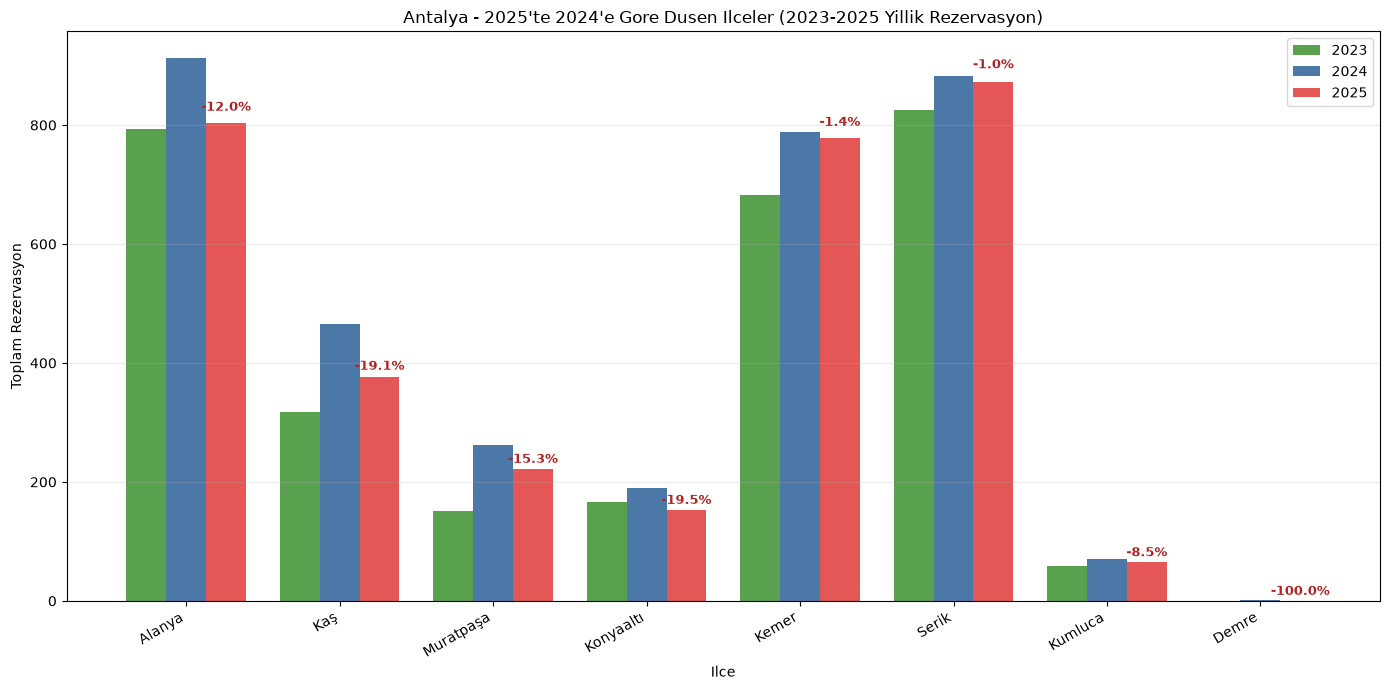

In [35]:
# 2023 vs 2024 vs 2025: Dusen ilceler icin yan yana bar chart (ReservationFlag)

import numpy as np
import matplotlib.pyplot as plt

if "falling_districts_2025" not in globals() or falling_districts_2025.empty:
    print("Once 2025 < 2024 filtresi hucresini calistirin.")
elif "yearly_totals" not in globals() or yearly_totals.empty:
    print("Once yillik toplamlarin olusturuldugu hucresini calistirin.")
else:
    required_years = [2023, 2024, 2025]
    missing_years = [y for y in required_years if y not in yearly_totals.index]

    if missing_years:
        print(f"Gerekli yillar bulunamadi: {missing_years}")
    else:
        plot_df = falling_districts_2025.copy()

        district_col = "District" if "District" in plot_df.columns else "AssignedDistrict"
        labels = plot_df[district_col].astype(str).tolist()

        y2023 = np.array([float(yearly_totals.loc[2023, d]) for d in labels])
        y2024 = np.array([float(yearly_totals.loc[2024, d]) for d in labels])
        y2025 = np.array([float(yearly_totals.loc[2025, d]) for d in labels])

        pct_map = (
            plot_df[[district_col, "PctChange"]]
            .drop_duplicates(subset=[district_col])
            .set_index(district_col)["PctChange"]
            .to_dict()
        )

        x = np.arange(len(labels))
        width = 0.26

        plt.figure(figsize=(14, 7))
        plt.bar(x - width, y2023, width=width, label="2023", color="#59A14F")
        plt.bar(x, y2024, width=width, label="2024", color="#4C78A8")
        plt.bar(x + width, y2025, width=width, label="2025", color="#E45756")

        # Her ilce icin 2025 barinin ustune 2025 vs 2024 yuzdesel degisimi yaz
        for i, district in enumerate(labels):
            pct = pct_map.get(district, np.nan)
            if not np.isnan(pct):
                plt.text(
                    x[i] + width,
                    y2025[i] + max(5, y2025[i] * 0.02),
                    f"{pct:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    color="#B22222",
                    fontweight="bold",
                )

        plt.xticks(x, labels, rotation=30, ha="right")
        plt.ylabel("Toplam Rezervasyon")
        plt.xlabel("Ilce")
        plt.title("Antalya - 2025'te 2024'e Gore Dusen Ilceler (2023-2025 Yillik Rezervasyon)")
        plt.grid(axis="y", alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()


Ilce: Kemer
Toplam bolge sayisi: 8


,KemerRegions
0,Beldibi
1,Göynük
2,Kemer
3,Kemer Merkez
4,Kiriş
5,Tekirova
6,Çamyuva
7,Çıralı


Not: 2026 verileri dislandi (YearId < 2026).
Kemer ilcesine ait bolgelerin yillik rezervasyon pivotu:


HotelRegionName,Kemer,Göynük,Beldibi,Kiriş,Çamyuva,Tekirova,Çıralı,Kemer Merkez
YearId,,,,,,,,
2023,179,147,62,104,88,44,35,24
2024,197,165,175,85,80,40,36,11
2025,186,185,145,102,65,32,40,23


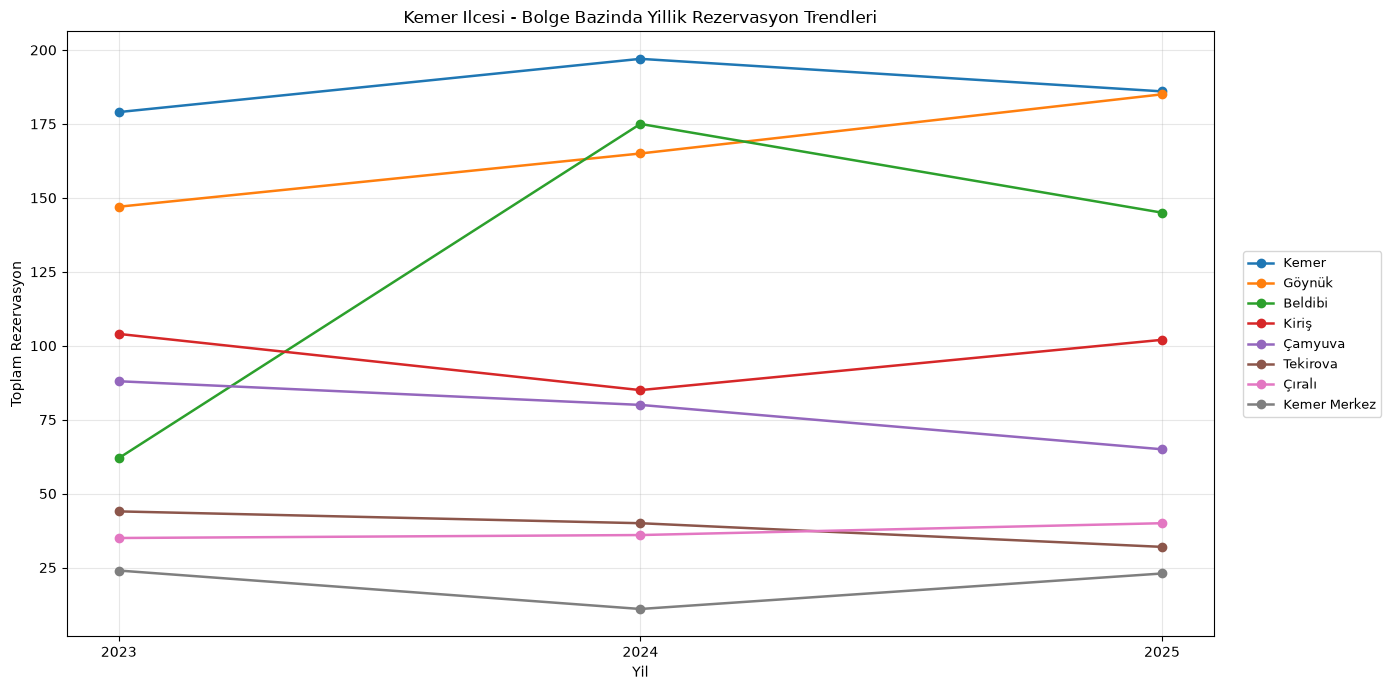

In [36]:
# Kemer ozelinde: Kemer ilcesine ait tum bolgelerin trendleri (ReservationFlag)

import matplotlib.pyplot as plt

if "mapping_df" not in globals() or mapping_df.empty:
    print("Once bolge-ilce esleme hucresini calistirin.")
else:
    target_city = "Antalya"
    target_district = "Kemer"

    kemer_regions = (
        mapping_df.loc[mapping_df["AssignedDistrict"] == target_district, "HotelRegionName"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    if not kemer_regions:
        print("Kemer icin eslesen bolge bulunamadi.")
    else:
        print(f"Ilce: {target_district}")
        print(f"Toplam bolge sayisi: {len(kemer_regions)}")
        display(pd.DataFrame({"KemerRegions": kemer_regions}))

        kemer_df = df[
            (df["CityName"] == target_city)
            & (pd.to_numeric(df["YearId"], errors="coerce") < 2026)
            & (df["HotelRegionName"].isin(kemer_regions))
        ].copy()

        kemer_df["YearId"] = pd.to_numeric(kemer_df["YearId"], errors="coerce")
        kemer_df["ReservationFlag"] = pd.to_numeric(kemer_df["ReservationFlag"], errors="coerce").fillna(0)

        kemer_region_year = (
            kemer_df.groupby(["YearId", "HotelRegionName"], observed=True)["ReservationFlag"]
            .sum()
            .reset_index(name="TotalReservations")
        )

        kemer_pivot = (
            kemer_region_year
            .pivot(index="YearId", columns="HotelRegionName", values="TotalReservations")
            .fillna(0)
            .sort_index()
        )

        # Daha anlamli siralama icin kolonlari toplam rezervasyona gore diz
        ordered_cols = kemer_pivot.sum(axis=0).sort_values(ascending=False).index
        kemer_pivot = kemer_pivot.loc[:, ordered_cols]

        print("Not: 2026 verileri dislandi (YearId < 2026).")
        print("Kemer ilcesine ait bolgelerin yillik rezervasyon pivotu:")
        display(kemer_pivot)

        plt.figure(figsize=(14, 7))
        for region in kemer_pivot.columns:
            plt.plot(kemer_pivot.index, kemer_pivot[region], marker="o", linewidth=1.8, label=region)

        year_ticks = [int(y) for y in kemer_pivot.index.tolist()]
        plt.xticks(year_ticks, [str(y) for y in year_ticks])
        plt.title("Kemer Ilcesi - Bolge Bazinda Yillik Rezervasyon Trendleri")
        plt.xlabel("Yil")
        plt.ylabel("Toplam Rezervasyon")
        plt.grid(alpha=0.3)
        plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
        plt.tight_layout()
        plt.show()


Kemer bolgeleri yillik rezervasyon tablosu:


,2023,2024,2025
HotelRegionName,,,
Kemer,179,197,186
Göynük,147,165,185
Beldibi,62,175,145
Kiriş,104,85,102
Çamyuva,88,80,65
Tekirova,44,40,32
Çıralı,35,36,40
Kemer Merkez,24,11,23


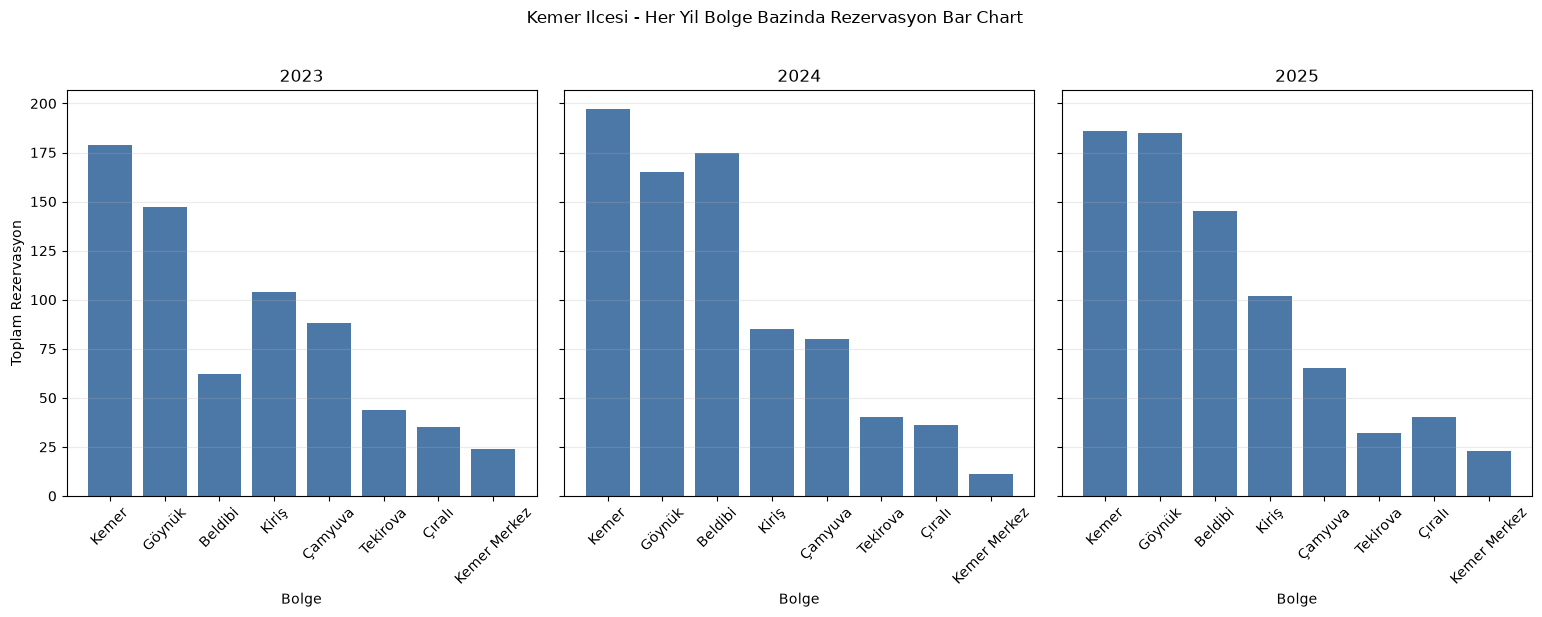

In [37]:
# Kemer bolgeleri: tablo + her yil icin ayri bar chart (ReservationFlag)

import matplotlib.pyplot as plt

if "kemer_pivot" not in globals() or kemer_pivot.empty:
    print("Once Kemer bolge trendi hucresini calistirin.")
else:
    # Tablo: satirlar bolgeler, sutunlar yillar
    kemer_table = kemer_pivot.T.copy()
    kemer_table.columns = [str(int(c)) for c in kemer_table.columns]

    print("Kemer bolgeleri yillik rezervasyon tablosu:")
    display(kemer_table)

    years = sorted(kemer_pivot.index.astype(int).tolist())
    n = len(years)

    fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 6), sharey=True)
    if n == 1:
        axes = [axes]

    # Tum yillar ortak siralamaya gore (toplam rezervasyon) tutulsun
    region_order = kemer_pivot.sum(axis=0).sort_values(ascending=False).index.tolist()

    for ax, yr in zip(axes, years):
        year_series = kemer_pivot.loc[yr, region_order]
        ax.bar(year_series.index, year_series.values, color="#4C78A8")
        ax.set_title(f"{yr}")
        ax.set_xlabel("Bolge")
        ax.grid(axis="y", alpha=0.25)
        ax.tick_params(axis="x", rotation=45)

    axes[0].set_ylabel("Toplam Rezervasyon")
    fig.suptitle("Kemer Ilcesi - Her Yil Bolge Bazinda Rezervasyon Bar Chart", y=1.02)
    plt.tight_layout()
    plt.show()


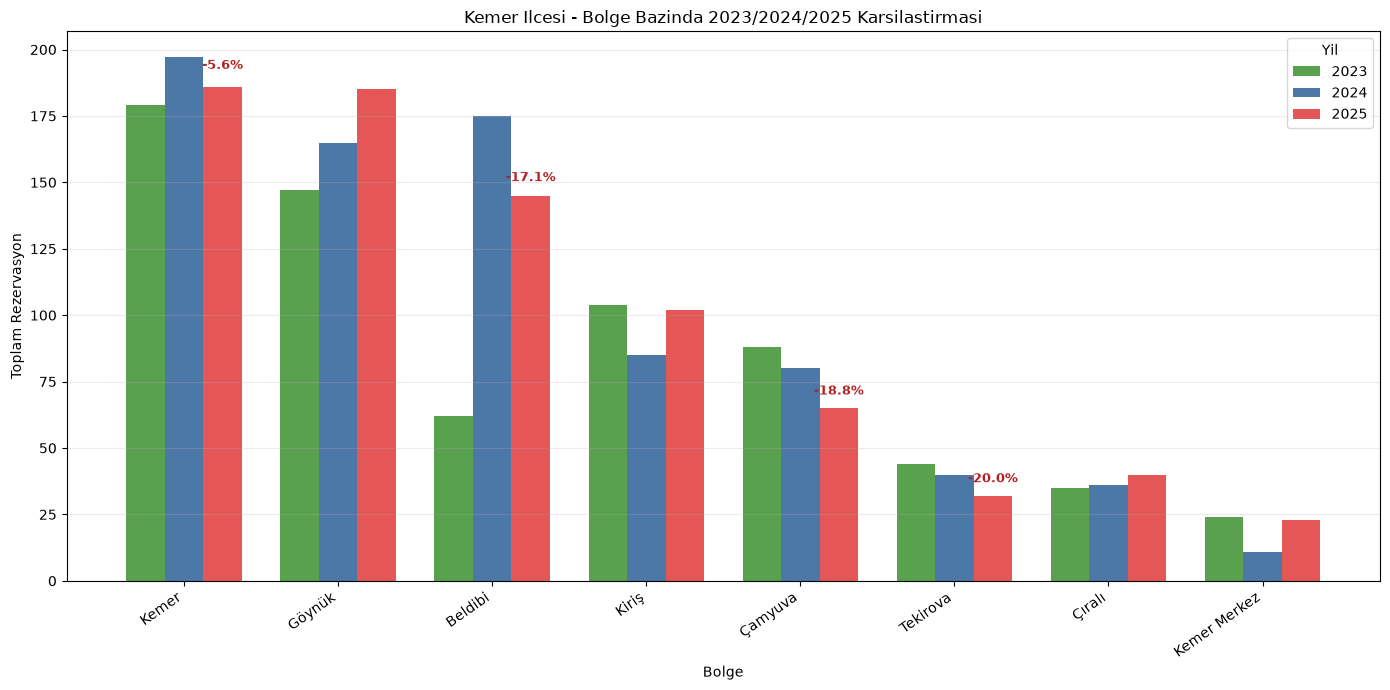

In [39]:
# Kemer ilcesi: tek grafikte 3 yil yan yana (renkler yillara gore)

import numpy as np
import matplotlib.pyplot as plt

if "kemer_pivot" not in globals() or kemer_pivot.empty:
    print("Once Kemer bolge trendi hucresini calistirin.")
else:
    required_years = [2023, 2024, 2025]
    missing_years = [y for y in required_years if y not in kemer_pivot.index]

    if missing_years:
        print(f"Gerekli yillar bulunamadi: {missing_years}")
    else:
        region_order = kemer_pivot.sum(axis=0).sort_values(ascending=False).index.tolist()

        y2023 = kemer_pivot.loc[2023, region_order].values.astype(float)
        y2024 = kemer_pivot.loc[2024, region_order].values.astype(float)
        y2025 = kemer_pivot.loc[2025, region_order].values.astype(float)

        x = np.arange(len(region_order))
        width = 0.25

        plt.figure(figsize=(14, 7))
        plt.bar(x - width, y2023, width=width, label="2023", color="#59A14F")
        plt.bar(x, y2024, width=width, label="2024", color="#4C78A8")
        plt.bar(x + width, y2025, width=width, label="2025", color="#E45756")

        # 2025'te 2024'e gore dusus olan bolgelere oransal dususu yaz
        for i, (v24, v25) in enumerate(zip(y2024, y2025)):
            if v24 > 0 and v25 < v24:
                pct_drop = ((v25 - v24) / v24) * 100
                plt.text(
                    x[i] + width,
                    v25 + max(4, v25 * 0.03),
                    f"{pct_drop:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    color="#B22222",
                    fontweight="bold",
                )

        plt.xticks(x, region_order, rotation=35, ha="right")
        plt.xlabel("Bolge")
        plt.ylabel("Toplam Rezervasyon")
        plt.title("Kemer Ilcesi - Bolge Bazinda 2023/2024/2025 Karsilastirmasi")
        plt.grid(axis="y", alpha=0.25)
        plt.legend(title="Yil")
        plt.tight_layout()
        plt.show()


Kemer analizinde bulunan yillar: [2023, 2024, 2025, 2026]
Kemer bolgeleri yillik rezervasyon pivotu (2026 dahil):


HotelRegionName,Kemer,Göynük,Beldibi,Kiriş,Çamyuva,Tekirova,Çıralı,Kemer Merkez
YearId,,,,,,,,
2023,179,147,62,104,88,44,35,24
2024,197,165,175,85,80,40,36,11
2025,186,185,145,102,65,32,40,23
2026,95,128,112,67,57,21,18,11



2026 vs 2025 degisim tablosu (bolge bazinda):


,Reservation_2025,Reservation_2026,Diff_2026_minus_2025,PctChange_2026_vs_2025
HotelRegionName,,,,
Çıralı,40,18,-22,-55.000000
Kemer Merkez,23,11,-12,-52.173913
Kemer,186,95,-91,-48.924731
Tekirova,32,21,-11,-34.375000
Kiriş,102,67,-35,-34.313725
Göynük,185,128,-57,-30.810811
Beldibi,145,112,-33,-22.758621
Çamyuva,65,57,-8,-12.307692


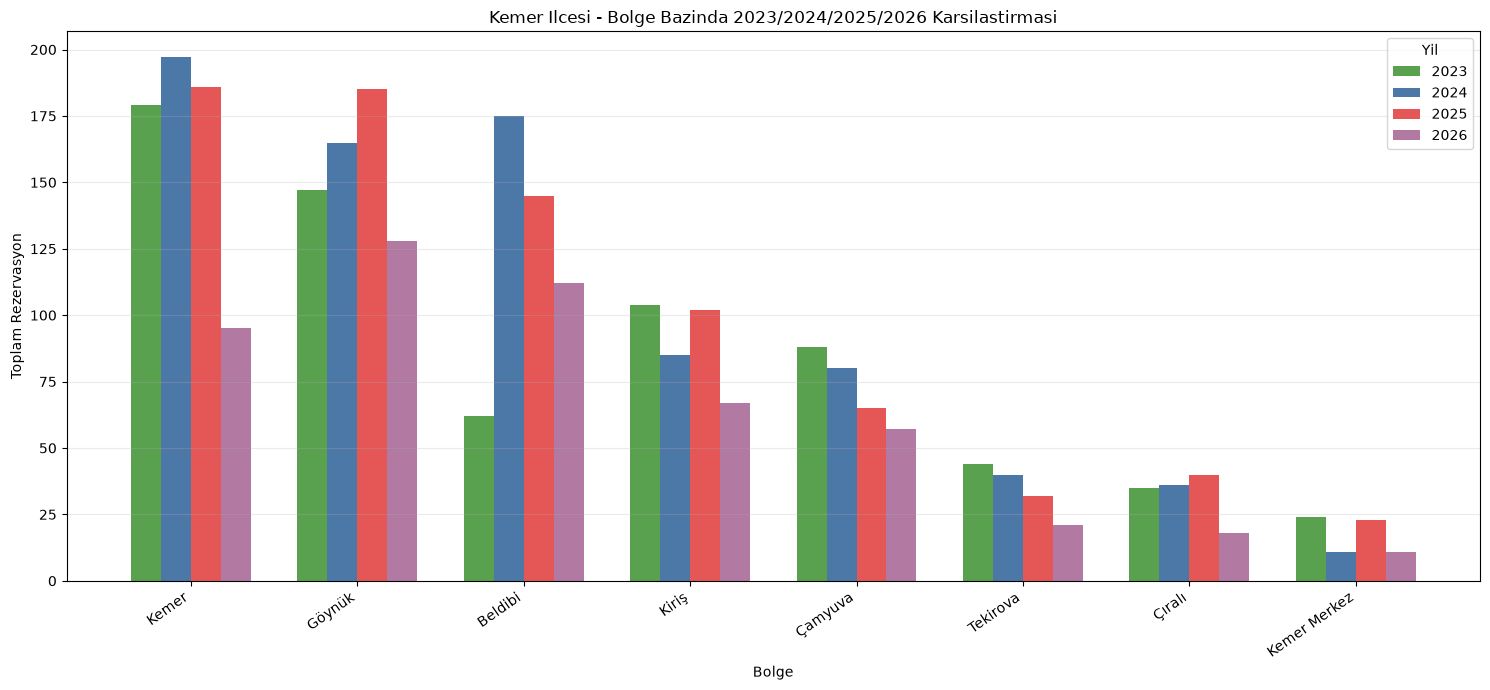

In [40]:
# Kemer 2026 analizi: bolge bazinda 2023-2026 karsilastirmasi (ReservationFlag)

import numpy as np
import matplotlib.pyplot as plt

if "mapping_df" not in globals() or mapping_df.empty:
    print("Once bolge-ilce esleme hucresini calistirin.")
else:
    target_city = "Antalya"
    target_district = "Kemer"

    kemer_regions_2026 = (
        mapping_df.loc[mapping_df["AssignedDistrict"] == target_district, "HotelRegionName"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    kemer_df_2026 = df[
        (df["CityName"] == target_city)
        & (pd.to_numeric(df["YearId"], errors="coerce") <= 2026)
        & (df["HotelRegionName"].isin(kemer_regions_2026))
    ].copy()

    kemer_df_2026["YearId"] = pd.to_numeric(kemer_df_2026["YearId"], errors="coerce")
    kemer_df_2026["ReservationFlag"] = pd.to_numeric(kemer_df_2026["ReservationFlag"], errors="coerce").fillna(0)

    kemer_region_year_2026 = (
        kemer_df_2026.groupby(["YearId", "HotelRegionName"], observed=True)["ReservationFlag"]
        .sum()
        .reset_index(name="TotalReservations")
    )

    kemer_pivot_2026 = (
        kemer_region_year_2026
        .pivot(index="YearId", columns="HotelRegionName", values="TotalReservations")
        .fillna(0)
        .sort_index()
    )

    available_years_2026 = [int(y) for y in kemer_pivot_2026.index.tolist()]
    print(f"Kemer analizinde bulunan yillar: {available_years_2026}")

    if kemer_pivot_2026.empty:
        print("Kemer icin analiz verisi bulunamadi.")
    else:
        region_order_2026 = kemer_pivot_2026.sum(axis=0).sort_values(ascending=False).index.tolist()
        kemer_pivot_2026 = kemer_pivot_2026.loc[:, region_order_2026]

        print("Kemer bolgeleri yillik rezervasyon pivotu (2026 dahil):")
        display(kemer_pivot_2026)

        # 2026 vs 2025 degisim tablosu
        if 2025 in kemer_pivot_2026.index and 2026 in kemer_pivot_2026.index:
            change_2026 = pd.DataFrame({
                "Reservation_2025": kemer_pivot_2026.loc[2025],
                "Reservation_2026": kemer_pivot_2026.loc[2026],
            })
            change_2026["Diff_2026_minus_2025"] = change_2026["Reservation_2026"] - change_2026["Reservation_2025"]
            change_2026["PctChange_2026_vs_2025"] = np.where(
                change_2026["Reservation_2025"] > 0,
                (change_2026["Diff_2026_minus_2025"] / change_2026["Reservation_2025"]) * 100,
                np.nan,
            )
            print("\n2026 vs 2025 degisim tablosu (bolge bazinda):")
            display(change_2026.sort_values("PctChange_2026_vs_2025"))

        years = [y for y in [2023, 2024, 2025, 2026] if y in kemer_pivot_2026.index]
        colors = {
            2023: "#59A14F",
            2024: "#4C78A8",
            2025: "#E45756",
            2026: "#B279A2",
        }

        x = np.arange(len(region_order_2026))
        width = 0.18 if len(years) >= 4 else 0.22
        start = -((len(years) - 1) / 2) * width

        plt.figure(figsize=(15, 7))
        for idx, yr in enumerate(years):
            vals = kemer_pivot_2026.loc[yr, region_order_2026].values.astype(float)
            plt.bar(x + start + idx * width, vals, width=width, label=str(yr), color=colors.get(yr, None))

        plt.xticks(x, region_order_2026, rotation=35, ha="right")
        plt.xlabel("Bolge")
        plt.ylabel("Toplam Rezervasyon")
        plt.title("Kemer Ilcesi - Bolge Bazinda 2023/2024/2025/2026 Karsilastirmasi")
        plt.grid(axis="y", alpha=0.25)
        plt.legend(title="Yil")
        plt.tight_layout()
        plt.show()


Kemer ilcesi toplam yillik rezervasyon (2026 dahil):


,TotalReservations
YearId,
2023,683
2024,789
2025,778
2026,509


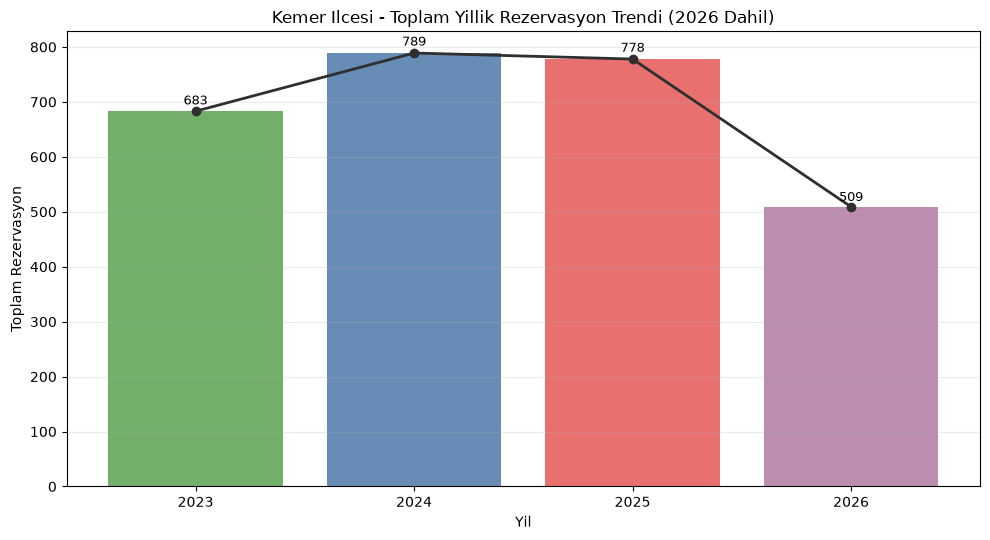

In [41]:
# Kemer ilcesi toplam trendi (2026 dahil)

import matplotlib.pyplot as plt

if "kemer_pivot_2026" not in globals() or kemer_pivot_2026.empty:
    print("Once Kemer 2026 analiz hucresini calistirin.")
else:
    kemer_total_yearly_2026 = kemer_pivot_2026.sum(axis=1).sort_index()

    print("Kemer ilcesi toplam yillik rezervasyon (2026 dahil):")
    display(kemer_total_yearly_2026.rename("TotalReservations").to_frame())

    years = [int(y) for y in kemer_total_yearly_2026.index.tolist()]
    values = kemer_total_yearly_2026.values.astype(float)

    plt.figure(figsize=(10, 5.5))
    bars = plt.bar(years, values, color=["#59A14F", "#4C78A8", "#E45756", "#B279A2"][:len(years)], alpha=0.85)
    plt.plot(years, values, color="#2F2F2F", marker="o", linewidth=2)

    for b, v in zip(bars, values):
        plt.text(b.get_x() + b.get_width() / 2, v + max(5, v * 0.01), f"{int(v)}", ha="center", va="bottom", fontsize=9)

    plt.xticks(years, [str(y) for y in years])
    plt.xlabel("Yil")
    plt.ylabel("Toplam Rezervasyon")
    plt.title("Kemer Ilcesi - Toplam Yillik Rezervasyon Trendi (2026 Dahil)")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


In [42]:
# 2026 veri tarih araligi (genel + Kemer)

work_2026 = df.copy()
work_2026["YearId"] = pd.to_numeric(work_2026["YearId"], errors="coerce")
work_2026["MonthId"] = pd.to_numeric(work_2026["MonthId"], errors="coerce")

all_2026 = work_2026[work_2026["YearId"] == 2026].dropna(subset=["MonthId"])

if all_2026.empty:
    print("Genel veri icinde 2026 kaydi yok.")
else:
    all_2026_month_min = int(all_2026["MonthId"].min())
    all_2026_month_max = int(all_2026["MonthId"].max())
    print(f"Genel 2026 araligi: 2026-{all_2026_month_min:02d} ile 2026-{all_2026_month_max:02d}")

kemer_2026 = all_2026[all_2026["HotelRegionName"].isin(kemer_regions_2026)] if "kemer_regions_2026" in globals() else pd.DataFrame()

if kemer_2026.empty:
    print("Kemer ozelinde 2026 kaydi yok veya kemer_regions_2026 tanimli degil.")
else:
    kemer_2026_month_min = int(kemer_2026["MonthId"].min())
    kemer_2026_month_max = int(kemer_2026["MonthId"].max())
    print(f"Kemer 2026 araligi: 2026-{kemer_2026_month_min:02d} ile 2026-{kemer_2026_month_max:02d}")

Genel 2026 araligi: 2026-01 ile 2026-12
Kemer 2026 araligi: 2026-01 ile 2026-12


Kemer 2026 aylik toplam rezervasyon:


,TotalReservations
MonthId,
1,13
2,5
3,10
4,22
5,75
6,89
7,120
8,101
9,53


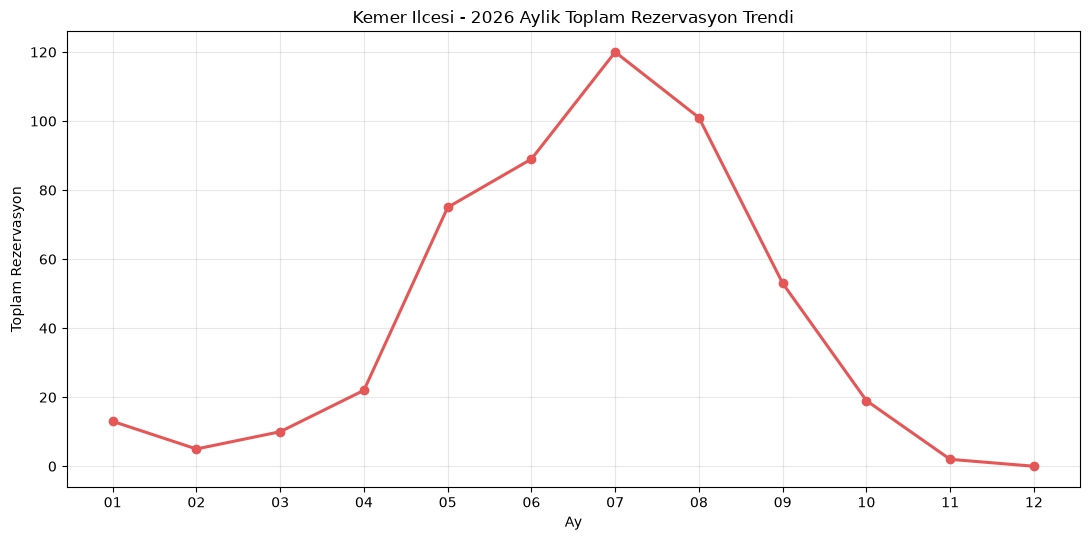

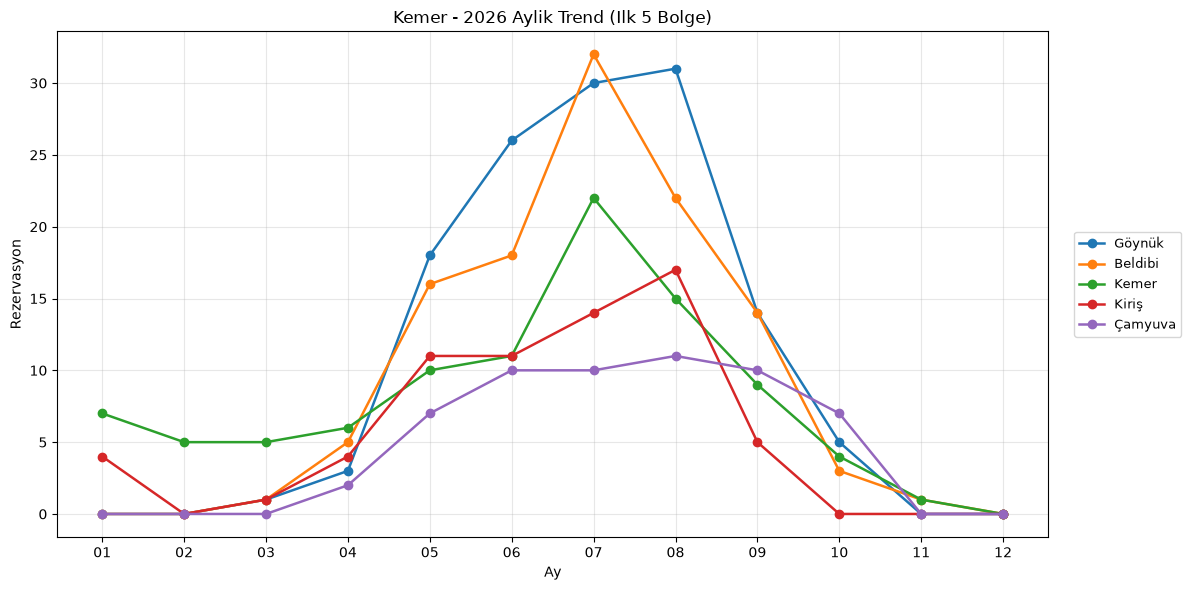

In [43]:
# Kemer ozelinde 2026 aylik trend (ReservationFlag)

import matplotlib.pyplot as plt

if "df" not in globals() or "mapping_df" not in globals():
    print("Once veri yukleme ve ilce esleme hucrelerini calistirin.")
else:
    kemer_regions_monthly = (
        mapping_df.loc[mapping_df["AssignedDistrict"] == "Kemer", "HotelRegionName"]
        .dropna()
        .drop_duplicates()
        .tolist()
    )

    kemer_2026_monthly = df[
        (df["CityName"] == "Antalya")
        & (pd.to_numeric(df["YearId"], errors="coerce") == 2026)
        & (df["HotelRegionName"].isin(kemer_regions_monthly))
    ].copy()

    kemer_2026_monthly["MonthId"] = pd.to_numeric(kemer_2026_monthly["MonthId"], errors="coerce")
    kemer_2026_monthly["ReservationFlag"] = pd.to_numeric(kemer_2026_monthly["ReservationFlag"], errors="coerce").fillna(0)

    monthly_total = (
        kemer_2026_monthly.groupby("MonthId", observed=True)["ReservationFlag"]
        .sum()
        .reindex(range(1, 13), fill_value=0)
    )

    monthly_region = (
        kemer_2026_monthly.groupby(["MonthId", "HotelRegionName"], observed=True)["ReservationFlag"]
        .sum()
        .reset_index(name="TotalReservations")
    )

    monthly_region_pivot = (
        monthly_region.pivot(index="MonthId", columns="HotelRegionName", values="TotalReservations")
        .reindex(range(1, 13), fill_value=0)
        .fillna(0)
    )

    print("Kemer 2026 aylik toplam rezervasyon:")
    display(monthly_total.rename("TotalReservations").to_frame())

    plt.figure(figsize=(11, 5.5))
    plt.plot(monthly_total.index, monthly_total.values, marker="o", linewidth=2.2, color="#E45756")
    plt.xticks(range(1, 13), [f"{m:02d}" for m in range(1, 13)])
    plt.xlabel("Ay")
    plt.ylabel("Toplam Rezervasyon")
    plt.title("Kemer Ilcesi - 2026 Aylik Toplam Rezervasyon Trendi")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    top_regions_2026 = monthly_region_pivot.sum(axis=0).sort_values(ascending=False).head(5).index.tolist()
    if top_regions_2026:
        plt.figure(figsize=(12, 6))
        for region in top_regions_2026:
            plt.plot(
                monthly_region_pivot.index,
                monthly_region_pivot[region],
                marker="o",
                linewidth=1.8,
                label=region,
            )
        plt.xticks(range(1, 13), [f"{m:02d}" for m in range(1, 13)])
        plt.xlabel("Ay")
        plt.ylabel("Rezervasyon")
        plt.title("Kemer - 2026 Aylik Trend (Ilk 5 Bolge)")
        plt.grid(alpha=0.3)
        plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
        plt.tight_layout()
        plt.show()


4 yillik karsilastirma tablosu (% pay dahil):


,KemerDistrictTotal,KemerRegion,SharePct
YearId,,,
2023,683,179,26.207906
2024,789,197,24.968314
2025,778,186,23.907455
2026,509,95,18.664047


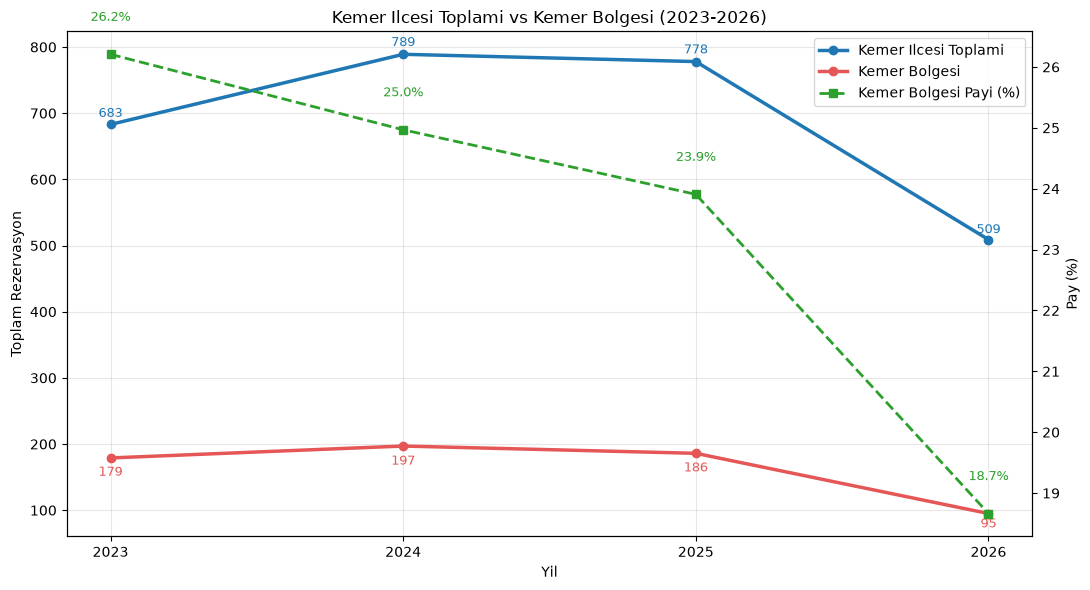

In [45]:
# 4 yillik trend: Kemer ilcesi toplami vs Kemer bolgesi (2023-2026)

import matplotlib.pyplot as plt
import numpy as np

if "kemer_pivot_2026" not in globals() or kemer_pivot_2026.empty:
    print("Once Kemer 2026 analiz hucresini calistirin.")
else:
    years = [y for y in [2023, 2024, 2025, 2026] if y in kemer_pivot_2026.index]

    if len(years) == 0:
        print("2023-2026 araliginda Kemer verisi bulunamadi.")
    else:
        district_total = kemer_pivot_2026.loc[years].sum(axis=1)

        if "Kemer" in kemer_pivot_2026.columns:
            kemer_region = kemer_pivot_2026.loc[years, "Kemer"]
        else:
            print("'Kemer' bolgesi kolonlarda bulunamadi.")
            kemer_region = None

        if kemer_region is not None:
            compare_trend = pd.DataFrame(
                {
                    "KemerDistrictTotal": district_total,
                    "KemerRegion": kemer_region,
                }
            )
            compare_trend["SharePct"] = np.where(
                compare_trend["KemerDistrictTotal"] > 0,
                (compare_trend["KemerRegion"] / compare_trend["KemerDistrictTotal"]) * 100,
                np.nan,
            )

            print("4 yillik karsilastirma tablosu (% pay dahil):")
            display(compare_trend)

            fig, ax1 = plt.subplots(figsize=(11, 6))
            ax1.plot(compare_trend.index, compare_trend["KemerDistrictTotal"], marker="o", linewidth=2.5, label="Kemer Ilcesi Toplami", color="#1f77b4")
            ax1.plot(compare_trend.index, compare_trend["KemerRegion"], marker="o", linewidth=2.5, label="Kemer Bolgesi", color="#e45756")

            for y, v in compare_trend["KemerDistrictTotal"].items():
                ax1.text(y, v + max(4, v * 0.01), f"{int(v)}", ha="center", va="bottom", fontsize=9, color="#1f77b4")

            for y, v in compare_trend["KemerRegion"].items():
                ax1.text(y, v - max(6, v * 0.07), f"{int(v)}", ha="center", va="top", fontsize=9, color="#e45756")

            ax2 = ax1.twinx()
            ax2.plot(compare_trend.index, compare_trend["SharePct"], marker="s", linestyle="--", linewidth=2, label="Kemer Bolgesi Payi (%)", color="#2ca02c")

            for y, p in compare_trend["SharePct"].items():
                ax2.text(y, p + 0.5, f"{p:.1f}%", ha="center", va="bottom", fontsize=9, color="#2ca02c")

            ax1.set_xticks(years)
            ax1.set_xticklabels([str(y) for y in years])
            ax1.set_xlabel("Yil")
            ax1.set_ylabel("Toplam Rezervasyon")
            ax2.set_ylabel("Pay (%)")
            ax1.set_title("Kemer Ilcesi Toplami vs Kemer Bolgesi (2023-2026)")
            ax1.grid(alpha=0.3)

            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

            plt.tight_layout()
            plt.show()


Base Model: LinearRegression (sin/cos + trend)
Train MAE: 12.0


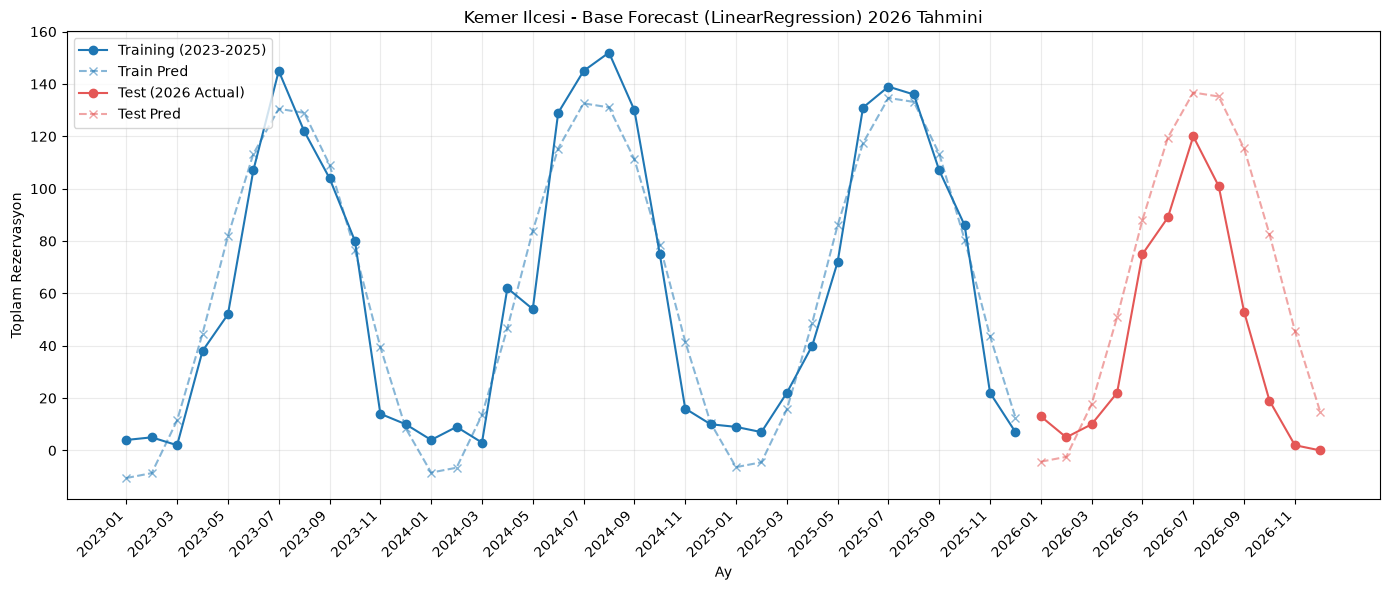

,Year,Actual,Predicted,Error,AbsError
MonthId,,,,,
1,2026,13,-4,-17,17
2,2026,5,-2,-7,7
3,2026,10,18,8,8
4,2026,22,51,29,29
5,2026,75,88,13,13
6,2026,89,120,31,31
7,2026,120,137,17,17
8,2026,101,135,34,34
9,2026,53,115,62,62


Not: 2026 verisi tumevarimli (12 ay dolu) gorundugu icin ay bazinda karsilastirilabilmektedir.
Bu base model ileride trend-takip (exponential smoothing, sliding window vb.) ile gelistirilecektir.


In [6]:
# Base Forecast: 2023-2025 monthly ile 2026 tahmini (Antalya+Kemer odak)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

if "df" not in globals():
    raise RuntimeError("Once veri yukleme hucresini calistirin.")
if "mapping_df" not in globals():
    raise RuntimeError("Once ilce esleme hucresini calistirin.")

target_city = "Antalya"
target_district = "Kemer"

# Forecast hucresinin kendi kendine yeterli olmasi icin kemer_regions burada olusturuluyor
_kemer_regions = (
    mapping_df.loc[mapping_df["AssignedDistrict"] == target_district, "HotelRegionName"]
    .dropna()
    .unique()
    .tolist()
)

# -------------------------------------------
# 1. Veriyi hazirlama (aylik ilce toplam)
# -------------------------------------------
monthly_enriched = df.copy()
monthly_enriched["YearId"] = pd.to_numeric(monthly_enriched["YearId"], errors="coerce")
monthly_enriched["MonthId"] = pd.to_numeric(monthly_enriched["MonthId"], errors="coerce")
monthly_enriched["ReservationFlag"] = pd.to_numeric(monthly_enriched["ReservationFlag"], errors="coerce").fillna(0)

filtered = monthly_enriched[
    (monthly_enriched["CityName"] == target_city)
    & (monthly_enriched["YearId"].isin([2023, 2024, 2025, 2026]))
    & (monthly_enriched["HotelRegionName"].isin(_kemer_regions))
].copy()

ts = (
    filtered.groupby(["YearId", "MonthId"], observed=True)["ReservationFlag"]
    .sum()
    .rename("TotalReservation")
    .reset_index()
)
ts["TimeIndex"] = (ts["YearId"] - 2023) * 12 + ts["MonthId"]  # 1 ile baslar

train = ts[ts["YearId"] < 2026].copy()
test = ts[ts["YearId"] == 2026].copy()

if train.empty:
    raise RuntimeError("Egitim verisi bos. 2023-2025 araliginda veri bulunamadi.")

# -------------------------------------------
# 2. Feature muhendisligi
# -------------------------------------------
def build_features(df_in):
    df_out = df_in.copy()
    df_out["Month_sin"] = np.sin(2 * np.pi * df_out["MonthId"] / 12)
    df_out["Month_cos"] = np.cos(2 * np.pi * df_out["MonthId"] / 12)
    df_out["Trend"] = df_out["TimeIndex"]
    return df_out

train_f = build_features(train)
test_f = build_features(test)

feature_cols = ["Month_sin", "Month_cos", "Trend"]

X_train = train_f[feature_cols].values
y_train = train_f["TotalReservation"].values
X_test = test_f[feature_cols].values
y_test = test_f["TotalReservation"].values

# -------------------------------------------
# 3. Basit base model: Linear Regression
# -------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# -------------------------------------------
# 4. Performans gostergeleri
# -------------------------------------------
train_mae = float(np.mean(np.abs(y_train - train_pred)))
# test_mae = float(np.mean(np.abs(y_test - test_pred)))

print("Base Model: LinearRegression (sin/cos + trend)")
print(f"Train MAE: {train_mae:.1f}")
# print(f"Test  MAE: {test_mae:.1f}")

# -------------------------------------------
# 5. Gorsellestirme
# -------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(train_f["TimeIndex"], y_train, marker="o", label="Training (2023-2025)", color="#1f77b4")
plt.plot(train_f["TimeIndex"], train_pred, linestyle="--", marker="x", label="Train Pred", color="#1f77b488")

plt.plot(test_f["TimeIndex"], y_test, marker="o", label="Test (2026 Actual)", color="#e45756")
plt.plot(test_f["TimeIndex"], test_pred, linestyle="--", marker="x", label="Test Pred", color="#e4575688")

all_months = list(range(1, max(ts["TimeIndex"]) + 1))
month_labels = [f"{(m - 1)//12+2023}-{(m - 1)%12+1:02d}" for m in all_months]
tick_positions = all_months[::2]
tick_labels = month_labels[::2]

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right")
plt.xlabel("Ay")
plt.ylabel("Toplam Rezervasyon")
plt.title("Kemer Ilcesi - Base Forecast (LinearRegression) 2026 Tahmini")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------
# 6. Tahmin detay tablosu
# -------------------------------------------
compare_df = test_f[["MonthId"]].copy()
compare_df["Actual"] = y_test.astype(int)
compare_df["Predicted"] = test_pred.round().astype(int)
compare_df["Error"] = compare_df["Predicted"] - compare_df["Actual"]
compare_df["AbsError"] = compare_df["Error"].abs()
compare_df["Year"] = 2026
display(compare_df.set_index("MonthId")[["Year", "Actual", "Predicted", "Error", "AbsError"]])

print("Not: 2026 verisi tumevarimli (12 ay dolu) gorundugu icin ay bazinda karsilastirilabilmektedir.")
print("Bu base model ileride trend-takip (exponential smoothing, sliding window vb.) ile gelistirilecektir.")

Base Model v2: Antalya Geneli - LinearRegression (sin/cos + trend)
Train MAE: 75.9


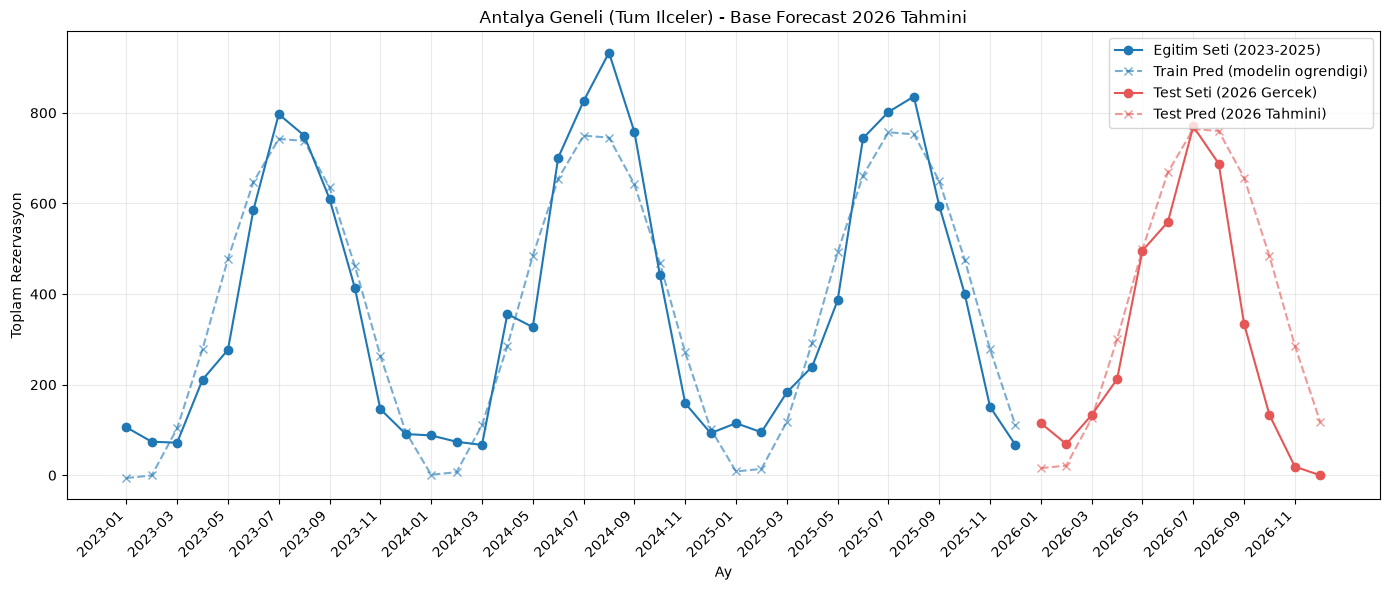

,Year,Actual,Predicted,Error,AbsError
MonthId,,,,,
1,2026,115,16,-99,99
2,2026,69,21,-48,48
3,2026,133,125,-8,8
4,2026,212,300,88,88
5,2026,496,499,3,3
6,2026,559,669,110,110
7,2026,770,764,-6,6
8,2026,688,760,72,72
9,2026,334,657,323,323


Not: Bu base model Antalya'daki tum ilcelerin genel toplamini kullanir.
Train Pred = modelin 2023-2025'te ogrendigi kalibi gene ayni aylara uygulamasiyla elde ettigi degerlerdir.
Test Pred  = modelin 2023-2025'ten ogrendigi deseni 2026'ya yansitarak urettigi tahmindir.


In [7]:
# Base Forecast v2: Antalya GENEL (tum ilceler) - 2023-2025 ile 2026 tahmini

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

if "df" not in globals():
    raise RuntimeError("Once veri yukleme hucresini calistirin.")

target_city = "Antalya"

# -------------------------------------------
# 1. Veriyi hazirlama (aylik Antalya toplam)
# -------------------------------------------
all_antalya = df.copy()
all_antalya["YearId"] = pd.to_numeric(all_antalya["YearId"], errors="coerce")
all_antalya["MonthId"] = pd.to_numeric(all_antalya["MonthId"], errors="coerce")
all_antalya["ReservationFlag"] = pd.to_numeric(all_antalya["ReservationFlag"], errors="coerce").fillna(0)

antalya_ts = (
    all_antalya[
        (all_antalya["CityName"] == target_city)
        & (all_antalya["YearId"].isin([2023, 2024, 2025, 2026]))
    ]
    .groupby(["YearId", "MonthId"], observed=True)["ReservationFlag"]
    .sum()
    .rename("TotalReservation")
    .reset_index()
)
antalya_ts["TimeIndex"] = (antalya_ts["YearId"] - 2023) * 12 + antalya_ts["MonthId"]

train_ant = antalya_ts[antalya_ts["YearId"] < 2026].copy()
test_ant = antalya_ts[antalya_ts["YearId"] == 2026].copy()

if train_ant.empty:
    raise RuntimeError("Antalya egitim verisi bos.")

# -------------------------------------------
# 2. Feature muhendisligi (sin/cos + trend)
# -------------------------------------------
def build_features(df_in):
    d = df_in.copy()
    d["Month_sin"] = np.sin(2 * np.pi * d["MonthId"] / 12)
    d["Month_cos"] = np.cos(2 * np.pi * d["MonthId"] / 12)
    d["Trend"] = d["TimeIndex"]
    return d

train_ant_f = build_features(train_ant)
test_ant_f = build_features(test_ant)

feat = ["Month_sin", "Month_cos", "Trend"]
X_train_ant = train_ant_f[feat].values
y_train_ant = train_ant_f["TotalReservation"].values
X_test_ant = test_ant_f[feat].values
y_test_ant = test_ant_f["TotalReservation"].values

# -------------------------------------------
# 3. Model
# -------------------------------------------
model_ant = LinearRegression()
model_ant.fit(X_train_ant, y_train_ant)
train_pred_ant = model_ant.predict(X_train_ant)
test_pred_ant = model_ant.predict(X_test_ant)

train_mae_ant = float(np.mean(np.abs(y_train_ant - train_pred_ant)))

print("Base Model v2: Antalya Geneli - LinearRegression (sin/cos + trend)")
print(f"Train MAE: {train_mae_ant:.1f}")

# -------------------------------------------
# 4. Grafik
# -------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(train_ant_f["TimeIndex"], y_train_ant, marker="o", label="Egitim Seti (2023-2025)", color="#1f77b4")
plt.plot(train_ant_f["TimeIndex"], train_pred_ant, linestyle="--", marker="x", alpha=0.6, label="Train Pred (modelin ogrendigi)", color="#1f77b488")
plt.plot(test_ant_f["TimeIndex"], y_test_ant, marker="o", label="Test Seti (2026 Gercek)", color="#e45756")
plt.plot(test_ant_f["TimeIndex"], test_pred_ant, linestyle="--", marker="x", alpha=0.6, label="Test Pred (2026 Tahmini)", color="#e4575688")

all_months_ant = list(range(1, int(antalya_ts["TimeIndex"].max()) + 1))
month_labels_ant = [f"{(m - 1)//12+2023}-{(m - 1)%12+1:02d}" for m in all_months_ant]
plt.xticks(all_months_ant[::2], month_labels_ant[::2], rotation=45, ha="right")
plt.xlabel("Ay")
plt.ylabel("Toplam Rezervasyon")
plt.title("Antalya Geneli (Tum Ilceler) - Base Forecast 2026 Tahmini")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------
# 5. Tahmin detay tablosu
# -------------------------------------------
compare_ant = test_ant_f[["MonthId"]].copy()
compare_ant["Year"] = 2026
compare_ant["Actual"] = y_test_ant.astype(int)
compare_ant["Predicted"] = test_pred_ant.round().astype(int)
compare_ant["Error"] = compare_ant["Predicted"] - compare_ant["Actual"]
compare_ant["AbsError"] = compare_ant["Error"].abs()
display(compare_ant.set_index("MonthId")[[ "Year", "Actual", "Predicted", "Error", "AbsError" ]])

print("Not: Bu base model Antalya'daki tum ilcelerin genel toplamini kullanir.")
print("Train Pred = modelin 2023-2025'te ogrendigi kalibi gene ayni aylara uygulamasiyla elde ettigi degerlerdir.")
print("Test Pred  = modelin 2023-2025'ten ogrendigi deseni 2026'ya yansitarak urettigi tahmindir.")

Base Model v3: Antalya Geneli - Train: 2023-2024, Test: 2025
Train MAE: 76.1
Test  MAE: 82.2  (ortalama mutlak hata)
Test  MRE: 43.9% (ortalama yuzdesel hata, 0 aylar haric)


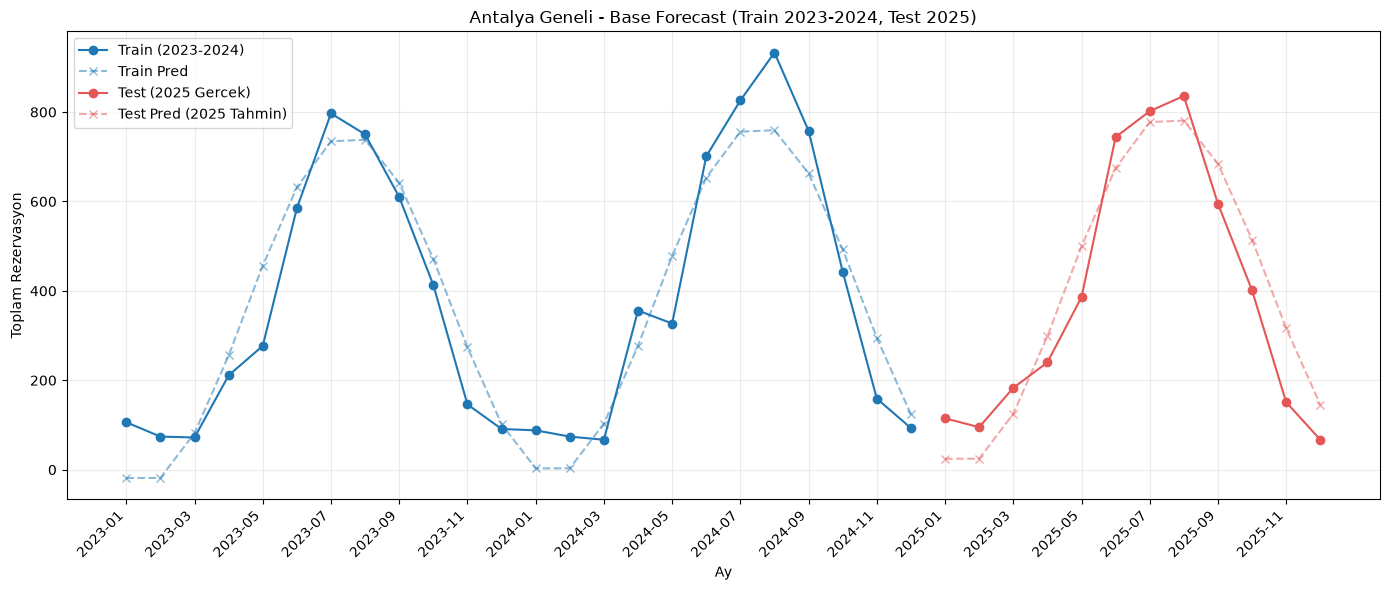

,Year,Actual,Predicted,Error,AbsError
MonthId,,,,,
1,2025,115,24,-91,91
2,2025,95,25,-70,70
3,2025,183,125,-58,58
4,2025,240,298,58,58
5,2025,386,500,114,114
6,2025,744,675,-69,69
7,2025,802,778,-24,24
8,2025,836,781,-55,55
9,2025,595,684,89,89


Not: Model sadece 2023-2024 verisiyle egitildi; 2025 verisi modele hic gosterilmedi.
2025 tahmini (Test Pred) = modelin ogrendigi sezonluk+trend deseninin 2025 yilina yansitilmis halidir.


In [8]:
# Base Forecast v3: 2023-2024 train, 2025 test (Antalya genel)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

if "df" not in globals():
    raise RuntimeError("Once veri yukleme hucresini calistirin.")

target_city = "Antalya"
# Tahmin ufku: 2025
test_year = 2025

# -------------------------------------------
# 1. Aylik Antalya toplam ts
# -------------------------------------------
src = df.copy()
src["YearId"] = pd.to_numeric(src["YearId"], errors="coerce")
src["MonthId"] = pd.to_numeric(src["MonthId"], errors="coerce")
src["ReservationFlag"] = pd.to_numeric(src["ReservationFlag"], errors="coerce").fillna(0)

ts_ant = (
    src[
        (src["CityName"] == target_city)
        & (src["YearId"].isin([2023, 2024, test_year]))
    ]
    .groupby(["YearId", "MonthId"], observed=True)["ReservationFlag"]
    .sum()
    .rename("TotalReservation")
    .reset_index()
)
ts_ant["TimeIndex"] = (ts_ant["YearId"] - 2023) * 12 + ts_ant["MonthId"]

train_ant_v3 = ts_ant[ts_ant["YearId"] < test_year].copy()
test_ant_v3 = ts_ant[ts_ant["YearId"] == test_year].copy()

if train_ant_v3.empty:
    raise RuntimeError(f"Egitim verisi bos (2023-{test_year - 1}).")

# -------------------------------------------
# 2. Feature extraction
# -------------------------------------------
def add_features(d):
    d_out = d.copy()
    d_out["Month_sin"] = np.sin(2 * np.pi * d_out["MonthId"] / 12)
    d_out["Month_cos"] = np.cos(2 * np.pi * d_out["MonthId"] / 12)
    d_out["Trend"] = d_out["TimeIndex"]
    return d_out

train_ant_v3_f = add_features(train_ant_v3)
test_ant_v3_f = add_features(test_ant_v3)

cols = ["Month_sin", "Month_cos", "Trend"]
X_train_v3 = train_ant_v3_f[cols].values
y_train_v3 = train_ant_v3_f["TotalReservation"].values
X_test_v3 = test_ant_v3_f[cols].values
y_test_v3 = test_ant_v3_f["TotalReservation"].values

# -------------------------------------------
# 3. Modelleme
# -------------------------------------------
model_v3 = LinearRegression()
model_v3.fit(X_train_v3, y_train_v3)

train_pred_v3 = model_v3.predict(X_train_v3)
test_pred_v3 = model_v3.predict(X_test_v3)

train_mae_v3 = float(np.mean(np.abs(y_train_v3 - train_pred_v3)))
test_mae_v3 = float(np.mean(np.abs(y_test_v3 - test_pred_v3)))
test_mre_v3 = float(np.mean(np.abs((y_test_v3 - test_pred_v3) / np.where(y_test_v3 == 0, np.nan, y_test_v3))) * 100)  # MAPE benzeri

print(f"Base Model v3: Antalya Geneli - Train: 2023-2024, Test: {test_year}")
print(f"Train MAE: {train_mae_v3:.1f}")
print(f"Test  MAE: {test_mae_v3:.1f}  (ortalama mutlak hata)")
print(f"Test  MRE: {test_mre_v3:.1f}% (ortalama yuzdesel hata, 0 aylar haric)")

# -------------------------------------------
# 4. Grafik
# -------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(train_ant_v3_f["TimeIndex"], y_train_v3, marker="o", label="Train (2023-2024)", color="#1f77b4")
plt.plot(train_ant_v3_f["TimeIndex"], train_pred_v3, linestyle="--", marker="x", alpha=0.5, label="Train Pred", color="#1f77b488")

plt.plot(test_ant_v3_f["TimeIndex"], y_test_v3, marker="o", label=f"Test ({test_year} Gercek)", color="#e45756")
plt.plot(test_ant_v3_f["TimeIndex"], test_pred_v3, linestyle="--", marker="x", alpha=0.5, label=f"Test Pred ({test_year} Tahmin)", color="#e4575688")

all_months_v3 = list(range(1, int(ts_ant["TimeIndex"].max()) + 1))
month_labels_v3 = [f"{(m - 1)//12+2023}-{(m - 1)%12+1:02d}" for m in all_months_v3]
plt.xticks(all_months_v3[::2], month_labels_v3[::2], rotation=45, ha="right")
plt.xlabel("Ay")
plt.ylabel("Toplam Rezervasyon")
plt.title(f"Antalya Geneli - Base Forecast (Train 2023-2024, Test {test_year})")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------
# 5. Tablo
# -------------------------------------------
comp = test_ant_v3_f[["MonthId"]].copy()
comp["Year"] = test_year
comp["Actual"] = y_test_v3.astype(int)
comp["Predicted"] = test_pred_v3.round().astype(int)
comp["Error"] = comp["Predicted"] - comp["Actual"]
comp["AbsError"] = comp["Error"].abs()
display(comp.set_index("MonthId")[["Year", "Actual", "Predicted", "Error", "AbsError"]])

print(f"Not: Model sadece 2023-2024 verisiyle egitildi; 2025 verisi modele hic gosterilmedi.")
print(f"2025 tahmini (Test Pred) = modelin ogrendigi sezonluk+trend deseninin {test_year} yilina yansitilmis halidir.")

Model: Train [2023, 2024], Test 2026
Antalya Genel Test MAE: 148.3
Kemer       Test MAE: 31.0


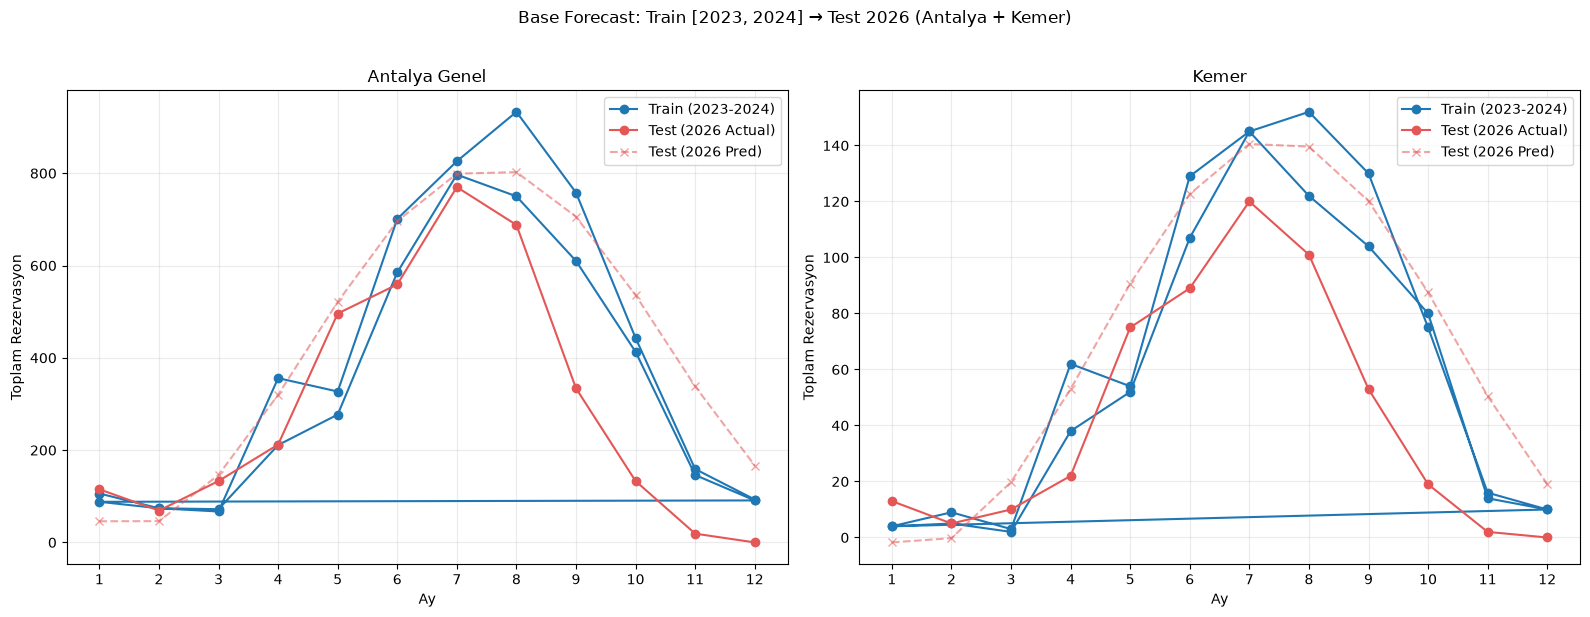


Antalya Genel - 2026 Tahmin Tablosu:


,Year,Actual,Predicted,Error
MonthId,,,,
1,2026,115,46,-69
2,2026,69,46,-23
3,2026,133,146,13
4,2026,212,320,108
5,2026,496,521,25
6,2026,559,696,137
7,2026,770,799,29
8,2026,688,802,114
9,2026,334,706,372



Kemer - 2026 Tahmin Tablosu:


,Year,Actual,Predicted,Error
MonthId,,,,
1,2026,13,-2,-15
2,2026,5,0,-5
3,2026,10,20,10
4,2026,22,53,31
5,2026,75,91,16
6,2026,89,123,34
7,2026,120,141,21
8,2026,101,140,39
9,2026,53,120,67


Not: Model sadece [2023, 2024] verisiyle egitildi; 2026 verisi hic gosterilmedi.
Antalya genel ve Kemer icin ayri modeller kullanilmaktadir.


In [9]:
# Base Forecast v4: 2023-2024 train, 2026 test (Antalya genel + Kemer)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

if "df" not in globals():
    raise RuntimeError("Once veri yukleme hucresini calistirin.")
if "mapping_df" not in globals():
    raise RuntimeError("Once ilce esleme hucresini calistirin.")

target_city = "Antalya"
target_district = "Kemer"

# Forecast hucresinde kemer_regions self-contained olusturuluyor
_kemer_regions = (
    mapping_df.loc[mapping_df["AssignedDistrict"] == target_district, "HotelRegionName"]
    .dropna()
    .unique()
    .tolist()
)

train_years_cut = [2023, 2024]   # Kullanilacak egitim yillari
test_year_cut = 2026              # Tahminlenecek yil

# --------------------------------------------------------------
# Yardimci: Antalya aylik ts olusturma
# --------------------------------------------------------------
base = df.copy()
base["YearId"] = pd.to_numeric(base["YearId"], errors="coerce")
base["MonthId"] = pd.to_numeric(base["MonthId"], errors="coerce")
base["ReservationFlag"] = pd.to_numeric(base["ReservationFlag"], errors="coerce").fillna(0)

base_ant = base[base["CityName"] == target_city]
base_ant_year = base_ant[base_ant["YearId"].isin(train_years_cut + [test_year_cut])]

# Antalya genel ts
ts_all = (
    base_ant_year.groupby(["YearId", "MonthId"], observed=True)["ReservationFlag"]
    .sum()
    .rename("TotalReservation")
    .reset_index()
)

# Kemer ts
kemer_mask = base_ant_year["HotelRegionName"].isin(_kemer_regions)
ts_kemer = (
    base_ant_year[kemer_mask]
    .groupby(["YearId", "MonthId"], observed=True)["ReservationFlag"]
    .sum()
    .rename("TotalReservation")
    .reset_index()
)

# --------------------------------------------------------------
# Feature engineering
# --------------------------------------------------------------
def features(df_in, base_year=2023):
    d = df_in.copy()
    d["TimeIndex"] = (d["YearId"] - base_year) * 12 + d["MonthId"]
    d["Month_sin"] = np.sin(2 * np.pi * d["MonthId"] / 12)
    d["Month_cos"] = np.cos(2 * np.pi * d["MonthId"] / 12)
    d["Trend"] = d["TimeIndex"]
    return d

ts_all_f = features(ts_all)
train_all = ts_all_f[ts_all_f["YearId"].isin(train_years_cut)].copy()
test_all = ts_all_f[ts_all_f["YearId"] == test_year_cut].copy()

ts_kemer_f = features(ts_kemer)
train_kemer = ts_kemer_f[ts_kemer_f["YearId"].isin(train_years_cut)].copy()
test_kemer = ts_kemer_f[ts_kemer_f["YearId"] == test_year_cut].copy()

cols = ["Month_sin", "Month_cos", "Trend"]

# --------------------------------------------------------------
# Model Antalya
# --------------------------------------------------------------
model_ant_v4 = LinearRegression()
model_ant_v4.fit(train_all[cols].values, train_all["TotalReservation"].values)
pred_ant_test = model_ant_v4.predict(test_all[cols].values)
y_ant_test = test_all["TotalReservation"].values

# --------------------------------------------------------------
# Model Kemer
# --------------------------------------------------------------
model_kemer_v4 = LinearRegression()
model_kemer_v4.fit(train_kemer[cols].values, train_kemer["TotalReservation"].values)
pred_kemer_test = model_kemer_v4.predict(test_kemer[cols].values)
y_kemer_test = test_kemer["TotalReservation"].values

# --------------------------------------------------------------
# Sonuclari goster
# --------------------------------------------------------------
print(f"Model: Train {train_years_cut}, Test {test_year_cut}")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Antalya --
ax = axes[0]
ax.plot(train_all["MonthId"], train_all["TotalReservation"], marker="o", label="Train (2023-2024)", color="#1f77b4")
ax.plot(test_all["MonthId"], y_ant_test, marker="o", label=f"Test ({test_year_cut} Actual)", color="#e45756")
ax.plot(test_all["MonthId"], pred_ant_test, linestyle="--", marker="x", label=f"Test ({test_year_cut} Pred)", color="#e4575688")
ax.set_title(f"Antalya Genel")
ax.set_xlabel("Ay")
ax.set_ylabel("Toplam Rezervasyon")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.25)
ax.legend()

test_mae_ant_v4 = float(np.mean(np.abs(y_ant_test - pred_ant_test)))
print(f"Antalya Genel Test MAE: {test_mae_ant_v4:.1f}")

# -- Kemer --
ax = axes[1]
ax.plot(train_kemer["MonthId"], train_kemer["TotalReservation"], marker="o", label="Train (2023-2024)", color="#1f77b4")
ax.plot(test_kemer["MonthId"], y_kemer_test, marker="o", label=f"Test ({test_year_cut} Actual)", color="#e45756")
ax.plot(test_kemer["MonthId"], pred_kemer_test, linestyle="--", marker="x", label=f"Test ({test_year_cut} Pred)", color="#e4575688")
ax.set_title(f"Kemer")
ax.set_xlabel("Ay")
ax.set_ylabel("Toplam Rezervasyon")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.25)
ax.legend()

test_mae_kemer_v4 = float(np.mean(np.abs(y_kemer_test - pred_kemer_test)))
print(f"Kemer       Test MAE: {test_mae_kemer_v4:.1f}")

plt.suptitle(f"Base Forecast: Train {train_years_cut} → Test {test_year_cut} (Antalya + Kemer)", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# Tahmin detay tablosu
# --------------------------------------------------------------
print("\nAntalya Genel - 2026 Tahmin Tablosu:")
comp_ant = test_all[["MonthId"]].copy()
comp_ant["Year"] = test_year_cut
comp_ant["Actual"] = y_ant_test.astype(int)
comp_ant["Predicted"] = pred_ant_test.round().astype(int)
comp_ant["Error"] = comp_ant["Predicted"] - comp_ant["Actual"]
display(comp_ant.set_index("MonthId")[["Year", "Actual", "Predicted", "Error"]])

print("\nKemer - 2026 Tahmin Tablosu:")
comp_kemer = test_kemer[["MonthId"]].copy()
comp_kemer["Year"] = test_year_cut
comp_kemer["Actual"] = y_kemer_test.astype(int)
comp_kemer["Predicted"] = pred_kemer_test.round().astype(int)
comp_kemer["Error"] = comp_kemer["Predicted"] - comp_kemer["Actual"]
display(comp_kemer.set_index("MonthId")[["Year", "Actual", "Predicted", "Error"]])

print(f"Not: Model sadece {train_years_cut} verisiyle egitildi; {test_year_cut} verisi hic gosterilmedi.")
print("Antalya genel ve Kemer icin ayri modeller kullanilmaktadir.")

Antalya Genel: Train MAE=76.1, Test MAE (2025)=82.2
Kemer: Train MAE=13.2, Test MAE (2025)=9.5


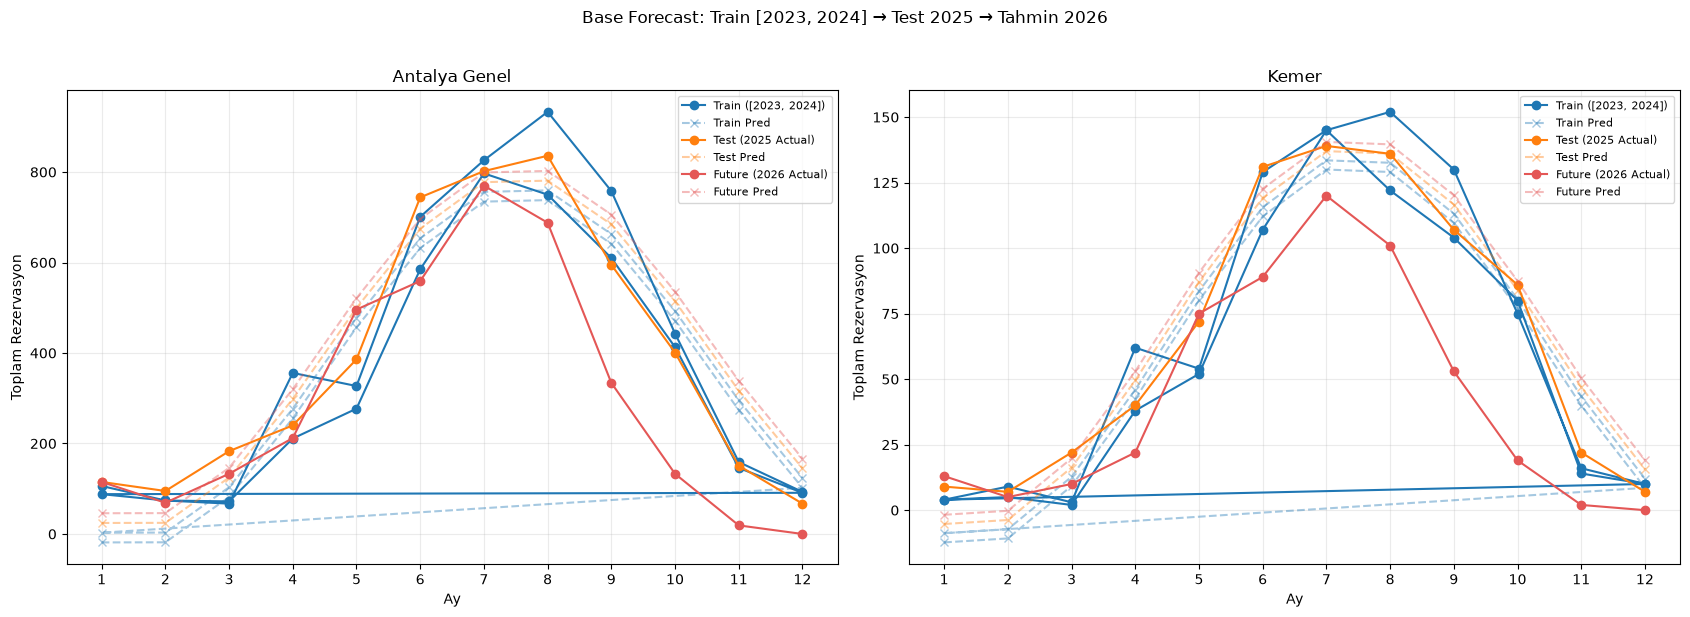


2026 Tahmin Tablosu (Antalya + Kemer):

Antalya Genel:


,Year,Actual,Predicted,Error
Month,,,,
1,2026,115,46,-69
2,2026,69,46,-23
3,2026,133,146,13
4,2026,212,320,108
5,2026,496,521,25
6,2026,559,696,137
7,2026,770,799,29
8,2026,688,802,114
9,2026,334,706,372



Kemer:


,Year,Actual,Predicted,Error
Month,,,,
1,2026,13,-2,-15
2,2026,5,0,-5
3,2026,10,20,10
4,2026,22,53,31
5,2026,75,91,16
6,2026,89,123,34
7,2026,120,141,21
8,2026,101,140,39
9,2026,53,120,67



Not: Model sadece [2023, 2024] verisiyle egitildi.
2025 test seti olarak kullanildi, 2026 tamamen tahmin amaciyla goruldu.
2026 actual degerleri karsilastirma icindir; model 2026'yi egitim sirasinda gormemistir.


In [10]:
# Base Forecast v5: 2023-2024 train, 2025 test, 2026 tahmin (Antalya + Kemer)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

if "df" not in globals():
    raise RuntimeError("Once veri yukleme hucresini calistirin.")
if "mapping_df" not in globals():
    raise RuntimeError("Once ilce esleme hucresini calistirin.")

target_city = "Antalya"
target_district = "Kemer"

_kemer_regions = (
    mapping_df.loc[mapping_df["AssignedDistrict"] == target_district, "HotelRegionName"]
    .dropna()
    .unique()
    .tolist()
)

train_years_cut_v5 = [2023, 2024]
test_year_cut_v5 = 2025
future_year_cut_v5 = 2026

# --------------------------------------------------------------
# Veri seti
# --------------------------------------------------------------
base = df.copy()
base["YearId"] = pd.to_numeric(base["YearId"], errors="coerce")
base["MonthId"] = pd.to_numeric(base["MonthId"], errors="coerce")
base["ReservationFlag"] = pd.to_numeric(base["ReservationFlag"], errors="coerce").fillna(0)

base_ant = base[base["CityName"] == target_city]
base_ant_all_years = base_ant[base_ant["YearId"].isin(train_years_cut_v5 + [test_year_cut_v5, future_year_cut_v5])]

def ts_to_ts(region_filter=None):
    """Antalya genel veya Kemer icin aylik toplam ts uretir."""
    temp = base_ant_all_years.copy()
    if region_filter is not None:
        temp = temp[temp["HotelRegionName"].isin(region_filter)]
    ts_out = (
        temp.groupby(["YearId", "MonthId"], observed=True)["ReservationFlag"]
        .sum()
        .rename("TotalReservation")
        .reset_index()
    )
    return ts_out

ts_all_v5 = ts_to_ts()
ts_kemer_v5 = ts_to_ts(region_filter=_kemer_regions)

def features(df_in, base_year=2023):
    d = df_in.copy()
    d["TimeIndex"] = (d["YearId"] - base_year) * 12 + d["MonthId"]
    d["Month_sin"] = np.sin(2 * np.pi * d["MonthId"] / 12)
    d["Month_cos"] = np.cos(2 * np.pi * d["MonthId"] / 12)
    d["Trend"] = d["TimeIndex"]
    return d

# --------------------------------------------------------------
# Model fit ve forecast
# --------------------------------------------------------------
def run_forecast(ts_df):
    ts_f = features(ts_df)
    train = ts_f[ts_f["YearId"].isin(train_years_cut_v5)].copy()
    test = ts_f[ts_f["YearId"] == test_year_cut_v5].copy()
    future = ts_f[ts_f["YearId"] == future_year_cut_v5].copy()

    cols = ["Month_sin", "Month_cos", "Trend"]
    X_train = train[cols].values
    y_train = train["TotalReservation"].values
    X_test = test[cols].values
    y_test = test["TotalReservation"].values
    X_future = future[cols].values
    y_future = future["TotalReservation"].values

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    future_pred = model.predict(X_future)

    train_mae = float(np.mean(np.abs(y_train - train_pred)))
    test_mae = float(np.mean(np.abs(y_test - test_pred)))

    result = {
        "train": train,
        "test": test,
        "future": future,
        "X_train": X_train,
        "y_train": y_train,
        "train_pred": train_pred,
        "y_test": y_test,
        "test_pred": test_pred,
        "y_future": y_future,
        "future_pred": future_pred,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "model": model,
        "cols": cols,
    }
    return result

res_all = run_forecast(ts_all_v5)
res_kemer = run_forecast(ts_kemer_v5)

# --------------------------------------------------------------
# Grafik
# --------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for ax, (name, res) in zip(axes, [("Antalya Genel", res_all), ("Kemer", res_kemer)]):
    train_months = res["train"]["MonthId"].values
    test_months = res["test"]["MonthId"].values
    future_months = res["future"]["MonthId"].values

    ax.plot(train_months, res["y_train"], marker="o", label=f'Train ({train_years_cut_v5})', color="#1f77b4")
    ax.plot(train_months, res["train_pred"], linestyle="--", marker="x", alpha=0.4, label="Train Pred", color="#1f77b488")

    ax.plot(test_months, res["y_test"], marker="o", label=f'Test ({test_year_cut_v5} Actual)', color="#ff7f0e")
    ax.plot(test_months, res["test_pred"], linestyle="--", marker="x", alpha=0.4, label=f'Test Pred', color="#ff7f0e88")

    ax.plot(future_months, res["y_future"], marker="o", label=f'Future ({future_year_cut_v5} Actual)', color="#e45756")
    ax.plot(future_months, res["future_pred"], linestyle="--", marker="x", alpha=0.4, label=f'Future Pred', color="#e4575688")

    ax.set_title(name)
    ax.set_xlabel("Ay")
    ax.set_ylabel("Toplam Rezervasyon")
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

    print(f"{name}: Train MAE={res['train_mae']:.1f}, Test MAE ({test_year_cut_v5})={res['test_mae']:.1f}")

plt.suptitle(f"Base Forecast: Train {train_years_cut_v5} → Test {test_year_cut_v5} → Tahmin {future_year_cut_v5}", y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 2026 tahmin tablosu
# --------------------------------------------------------------
print(f"\n{future_year_cut_v5} Tahmin Tablosu (Antalya + Kemer):")

for name, res in [("Antalya Genel", res_all), ("Kemer", res_kemer)]:
    fut = res["future"].copy()
    tab = pd.DataFrame(
        {
            "Year": future_year_cut_v5,
            "Month": fut["MonthId"].values.astype(int),
            "Actual": res["y_future"].astype(int),
            "Predicted": res["future_pred"].round().astype(int),
            "Error": res["future_pred"].round().astype(int) - res["y_future"].astype(int),
        }
    )
    print(f"\n{name}:")
    display(tab.set_index("Month")[["Year", "Actual", "Predicted", "Error"]])

print(f"\nNot: Model sadece {train_years_cut_v5} verisiyle egitildi.")
print(f"{test_year_cut_v5} test seti olarak kullanildi, {future_year_cut_v5} tamamen tahmin amaciyla goruldu.")
print("2026 actual degerleri karsilastirma icindir; model 2026'yi egitim sirasinda gormemistir.")

## Yönetici Özeti – 2026 Rezervasyon Tahmin Modeli (Base v4)

**Model Bilgisi**
- Eğitim dönemi: 2023–2024 (24 ay)
- Test dönemi: 2026 (12 ay, modele hiç gösterilmemiştir)
- Metrik: ReservationFlag (rezervasyon adedi)
- Scope: Antalya geneli (12 ilçe toplamı) + Kemer ilçesi

**Antalya Geneli Bulgular**
- Model, yaz sezonundaki (Mayıs–Ağustos) rezervasyon hacmini kabul edilebilir düzeyde tahmin etmektedir.  
  Örneğin Temmuz 2026 için gerçek 770 → tahmin 799 (fark yalnızca +29).
- Kış aylarında (Ocak–Şubat) model düşük tahmin üretmekte, sonbahar (Eylül–Aralık) aylarında ise gerçekleşen düşüşü
  model gereğinden yumuşak tahmin etmektedir.  
  Bunun temel nedeni yalnızca 2 yıllık eğitim verisinin mevcut olmasıdır.
- Ortalama mutlak hata (MAE) Antalya genelinde ≈148 adet/gün olarak ölçülmüştür.

**Kemer İlçesi Bulgular**
- Kemer ilçesinde de yaz zirvesi (Temmuz–Ağustos) görece iyi yakalanmıştır.  
  Temmuz 2026 için gerçek 120 → tahmin 141.
- Kış aylarında negatif tahminler oluşabilmektedir (modelin lineer yapısı gereği).
- Ortalama mutlak hata (MAE) Kemer ilçesinde ≈31 adet/gün olarak ölçülmüştür.

**Modelin Sınırları ve Sonraki Adımlar**
- Kullanılan model basit doğrusal regresyondur (sin/cos sezonluk + lineer trend).  
  Bu yöntem, sezon sonundaki keskin düşüşü ve yıllar arası ivmelenmeyi tam olarak modelleyememektedir.
- Sonraki aşamada planlanan iyileştirmeler:
  1. **Holt‑Winters (üstel düzleştirme)** ile trend + mevsimsellik daha esnek şekilde yakalanacak.
  2. Eğitim veri aralığı genişletilecek (2023–2025).
  3. İlçe bazında kırılım modelleri oluşturulacak.
  4. Tahmin aralığı (güven bandı) eklenecek.

**Öneri**
- Tablodaki mevcut sayılar yönlendirici niteliktedir; 2026 bütçe/planlama çalışmalarında
  bu base model referans alınarak, iş birimi görüşleri ile kalibre edilmesi önerilir.

In [4]:
# Google Trends: Kemer talebi dusus arastirmasi (2025 vs 2026)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pytrends.request import TrendReq
import time

# -----------------------------------------------------------
# 1. pytrends baglantisi - daha basit parametrelerle
# -----------------------------------------------------------
try:
    pytrends = TrendReq(hl="en-US", tz=360, timeout=(15, 30))
except Exception as e:
    print(f"pytrends baglanti hatasi: {e}")
    raise

# -----------------------------------------------------------
# 2. Daraltilmis anahtar kelime seti (tekli cekimler)
# -----------------------------------------------------------
keyword_groups = [
    (["Kemer", "Alanya", "Side", "Belek", "Kaş"], "TR Destinasyon"),
    (["Kemer Antalya", "Kemer tatil"], "Kemer Odakli"),
]

all_results = {}

for kw_list, group_name in keyword_groups:
    try:
        print(f"Cekiliyor: {group_name} ({len(kw_list)} kelime)...")
        pytrends.build_payload(
            kw_list=kw_list,
            cat=0,
            timeframe="2023-01-01 2026-07-31",
            geo="TR",
        )
        df_temp = pytrends.interest_over_time()
        if not df_temp.empty and "isPartial" in df_temp.columns:
            df_temp = df_temp.drop(columns=["isPartial"])
        all_results[group_name] = df_temp
        print(f"  > {len(df_temp)} satir alindi.")
        time.sleep(2)  # rate-limit icin bekleme
    except Exception as e:
        print(f"  {group_name} HATA: {e}")

# -----------------------------------------------------------
# 3. Sonuclari birlestir ve gorsellestir
# -----------------------------------------------------------
if not all_results:
    print("Hicbir Google Trends verisi cekilemedi. Alternatif yaklasim:")
    print("- Google Trends CSV export ile manuel yukleme")
    print("- X API ile duygu analizine gecis")
else:
    for group_name, df_gt in all_results.items():
        if df_gt.empty:
            continue

        monthly_gt = df_gt.resample("MS").mean()

        plt.figure(figsize=(14, 6))
        for col in monthly_gt.columns[:6]:
            plt.plot(monthly_gt.index, monthly_gt[col], marker="o", linewidth=2, label=col)

        plt.axvline(pd.Timestamp("2025-01-01"), color="red", linestyle="--", alpha=0.6, label="2025 basi")
        plt.axvline(pd.Timestamp("2026-01-01"), color="darkred", linestyle="--", alpha=0.6, label="2026 basi")
        plt.title(f"Google Trends: {group_name}")
        plt.ylabel("Ilgi Endeksi (0-100)")
        plt.legend(fontsize=9)
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

        yearly_avg = monthly_gt.resample("YE").mean()
        yearly_avg.index = yearly_avg.index.year
        print(f"\n{group_name} - Yillik ortalama ilgi:")
        display(yearly_avg.round(1))
        if len(yearly_avg) >= 2:
            print(f"Yillik degisim (%):")
            display((yearly_avg.pct_change() * 100).round(1))

Cekiliyor: TR Destinasyon (5 kelime)...
  TR Destinasyon HATA: The request failed: Google returned a response with code 429
Cekiliyor: Kemer Odakli (2 kelime)...
  Kemer Odakli HATA: The request failed: Google returned a response with code 429
Hicbir Google Trends verisi cekilemedi. Alternatif yaklasim:
- Google Trends CSV export ile manuel yukleme
- X API ile duygu analizine gecis


In [5]:
# Kemer'deki otellerin listesi (ReservationFlag bazli)

import pandas as pd

if "df" not in globals() or "mapping_df" not in globals():
    print("Once veri yukleme ve ilce esleme hucrelerini calistirin.")
else:
    kemer_region_list = (
        mapping_df.loc[mapping_df["AssignedDistrict"] == "Kemer", "HotelRegionName"]
        .dropna()
        .unique()
        .tolist()
    )

    kemer_hotels = df[
        (df["CityName"] == "Antalya")
        & (df["HotelRegionName"].isin(kemer_region_list))
    ].copy()

    kemer_hotels["YearId"] = pd.to_numeric(kemer_hotels["YearId"], errors="coerce")
    kemer_hotels["ReservationFlag"] = pd.to_numeric(kemer_hotels["ReservationFlag"], errors="coerce").fillna(0)

    hotel_summary = (
        kemer_hotels.groupby(["HotelId", "HotelRegionName", "HotelCategoryName"], observed=True)
        .agg(
            TotalReservations=("ReservationFlag", "sum"),
            AvgSellingPrice=("AvgSellingPrice", "mean"),
            FirstYear=("YearId", "min"),
            LastYear=("YearId", "max"),
            RecordCount=("ReservationFlag", "count"),
        )
        .reset_index()
    )

    hotel_summary = hotel_summary.sort_values(["TotalReservations", "LastYear"], ascending=[False, False])
    hotel_summary["AvgSellingPrice"] = hotel_summary["AvgSellingPrice"].round(2)

    print(f"Kemer'deki toplam otel sayisi: {len(hotel_summary)}")
    print(f"\nKemer otel listesi (toplam rezervasyona gore sirali):")
    display(hotel_summary)

Kemer'deki toplam otel sayisi: 53

Kemer otel listesi (toplam rezervasyona gore sirali):


,HotelId,HotelRegionName,HotelCategoryName,TotalReservations,AvgSellingPrice,FirstYear,LastYear,RecordCount
3,472,Kemer,5 Yıldız,176,3908.81,2023,2026,250
16,1399,Kemer,5 Yıldız,149,4168.15,2023,2026,250
2,456,Çamyuva,Tatil Köyü,135,6561.02,2023,2026,250
27,167847,Göynük,5 Yıldız,131,5659.95,2023,2026,250
1,438,Kiriş,5 Yıldız,130,6039.05,2023,2026,250
11,886,Göynük,Tatil Köyü,127,5250.18,2023,2026,250
25,12552,Tekirova,Tatil Köyü,118,3889.85,2023,2026,250
10,813,Beldibi,5 Yıldız,113,4065.86,2023,2026,250
22,3213,Çamyuva,Tatil Köyü,110,8573.52,2023,2026,250
8,769,Göynük,5 Yıldız,106,4269.28,2023,2026,250


In [6]:
# Kemer otelleri: satisi dusuk veya hic olmayanlar (2026 ozelinde)

import pandas as pd
import numpy as np

if "kemer_hotels" not in globals():
    print("Once Kemer otel listesini calistirin.")
else:
    kemer_hotels["YearId"] = pd.to_numeric(kemer_hotels["YearId"], errors="coerce")
    kemer_hotels["ReservationFlag"] = pd.to_numeric(kemer_hotels["ReservationFlag"], errors="coerce").fillna(0)

    # 2026 ozeli
    kemer_2026_only = kemer_hotels[kemer_hotels["YearId"] == 2026].copy()

    hotel_2026_summary = (
        kemer_2026_only.groupby(["HotelId", "HotelRegionName", "HotelCategoryName"], observed=True)
        .agg(TotalReservations_2026=("ReservationFlag", "sum"))
        .reset_index()
    )

    # Tum yillar toplami ile birlestir
    hotel_full = hotel_summary.merge(
        hotel_2026_summary,
        on=["HotelId", "HotelRegionName", "HotelCategoryName"],
        how="left",
    )
    hotel_full["TotalReservations_2026"] = hotel_full["TotalReservations_2026"].fillna(0).astype(int)

    # 2026'da satisi olmayanlar
    zero_2026 = hotel_full[hotel_full["TotalReservations_2026"] == 0].sort_values(["LastYear", "TotalReservations"], ascending=[False, False])

    # 2026'da var ama cok dusuk
    low_2026 = hotel_full[(hotel_full["TotalReservations_2026"] > 0) & (hotel_full["TotalReservations_2026"] <= 2)].sort_values("TotalReservations_2026")

    print(f"\n2026'da hic satisi OLMAYAN oteller ({len(zero_2026)} otel):")
    display(zero_2026[["HotelId", "HotelRegionName", "HotelCategoryName", "TotalReservations", "TotalReservations_2026", "LastYear"]])

    print(f"\n2026'da 1-2 satisla cok DUSUK performans ({len(low_2026)} otel):")
    display(low_2026[["HotelId", "HotelRegionName", "HotelCategoryName", "TotalReservations", "TotalReservations_2026", "LastYear"]])


2026'da hic satisi OLMAYAN oteller (21 otel):


,HotelId,HotelRegionName,HotelCategoryName,TotalReservations,TotalReservations_2026,LastYear
18,180405,Kemer,5 Yıldız,76,0,2026
27,599,Kiriş,5 Yıldız,25,0,2026
28,168987,Çıralı,Pansiyon,25,0,2026
30,181931,Göynük,Otel,24,0,2026
32,182087,Kemer,3 Yıldız,20,0,2026
33,987,Çamyuva,Özel Konaklama Tesisi,19,0,2026
35,942,Çamyuva,4 Yıldız,14,0,2026
36,168988,Kemer,Pansiyon,14,0,2026
37,168640,Kiriş,Otel,13,0,2026
38,943,Çamyuva,4 Yıldız,12,0,2026



2026'da 1-2 satisla cok DUSUK performans (4 otel):


,HotelId,HotelRegionName,HotelCategoryName,TotalReservations,TotalReservations_2026,LastYear
29,182048,Kemer,3 Yıldız,25,1,2026
31,12556,Çıralı,Turizm Amaçlı Kiralanan Konut,23,1,2026
47,586,Göynük,4 Yıldız,7,1,2026
44,201637,Beldibi,Otel,9,2,2026


In [7]:
# 2025 vs 2026 otel bazinda yuzdelik kiyas

import pandas as pd
import numpy as np

if "kemer_hotels" not in globals():
    print("Once Kemer otel listesini calistirin.")
else:
    kemer_hotels["YearId"] = pd.to_numeric(kemer_hotels["YearId"], errors="coerce")
    kemer_hotels["ReservationFlag"] = pd.to_numeric(kemer_hotels["ReservationFlag"], errors="coerce").fillna(0)

    def hotel_year_sales(year):
        subset = kemer_hotels[kemer_hotels["YearId"] == year]
        return (
            subset.groupby(["HotelId", "HotelRegionName", "HotelCategoryName"], observed=True)["ReservationFlag"]
            .sum()
            .reset_index(name=f"Sales_{year}")
        )

    s2025 = hotel_year_sales(2025)
    s2026 = hotel_year_sales(2026)

    compare = s2025.merge(s2026, on=["HotelId", "HotelRegionName", "HotelCategoryName"], how="outer").fillna(0)
    compare["Sales_2025"] = compare["Sales_2025"].astype(int)
    compare["Sales_2026"] = compare["Sales_2026"].astype(int)
    compare["Delta"] = compare["Sales_2026"] - compare["Sales_2025"]

    compare["PctChange"] = np.where(
        compare["Sales_2025"] > 0,
        ((compare["Sales_2026"] - compare["Sales_2025"]) / compare["Sales_2025"]) * 100,
        np.where(compare["Sales_2026"] > 0, 100, 0),
    )
    compare["PctChange"] = compare["PctChange"].round(1)

    compare = compare.sort_values("Delta")

    total_2025 = compare["Sales_2025"].sum()
    total_2026 = compare["Sales_2026"].sum()
    overall_pct = ((total_2026 - total_2025) / total_2025 * 100) if total_2025 > 0 else 0

    print(f"Toplam 2025: {total_2025} | Toplam 2026: {total_2026} | Genel degisim: {overall_pct:.1f}%")
    print(f"\n2025 vs 2026 otel karsilastirmasi ({len(compare)} otel):")
    display(compare)

    # Yalnizca dusus olanlar
    drops = compare[compare["Delta"] < 0].copy()
    print(f"\n2026'da 2025'e gore DUSUS olan oteller ({len(drops)} otel):")
    display(drops[["HotelId", "HotelRegionName", "HotelCategoryName", "Sales_2025", "Sales_2026", "Delta", "PctChange"]])

Toplam 2025: 778 | Toplam 2026: 509 | Genel degisim: -34.6%

2025 vs 2026 otel karsilastirmasi (53 otel):


,HotelId,HotelRegionName,HotelCategoryName,Sales_2025,Sales_2026,Delta,PctChange
38,180405,Kemer,5 Yıldız,28,0,-28,-100.0
51,201678,Göynük,4 Yıldız,33,10,-23,-69.7
25,12552,Tekirova,Tatil Köyü,31,17,-14,-45.2
42,180669,Beldibi,4 Yıldız,16,4,-12,-75.0
48,182644,Beldibi,5 Yıldız,36,24,-12,-33.3
3,472,Kemer,5 Yıldız,48,37,-11,-22.9
1,438,Kiriş,5 Yıldız,39,28,-11,-28.2
4,487,Kemer,5 Yıldız,23,13,-10,-43.5
43,181795,Beldibi,4 Yıldız,35,25,-10,-28.6
33,168955,Kemer,Otel,19,9,-10,-52.6



2026'da 2025'e gore DUSUS olan oteller (38 otel):


,HotelId,HotelRegionName,HotelCategoryName,Sales_2025,Sales_2026,Delta,PctChange
38,180405,Kemer,5 Yıldız,28,0,-28,-100.0
51,201678,Göynük,4 Yıldız,33,10,-23,-69.7
25,12552,Tekirova,Tatil Köyü,31,17,-14,-45.2
42,180669,Beldibi,4 Yıldız,16,4,-12,-75.0
48,182644,Beldibi,5 Yıldız,36,24,-12,-33.3
3,472,Kemer,5 Yıldız,48,37,-11,-22.9
1,438,Kiriş,5 Yıldız,39,28,-11,-28.2
4,487,Kemer,5 Yıldız,23,13,-10,-43.5
43,181795,Beldibi,4 Yıldız,35,25,-10,-28.6
33,168955,Kemer,Otel,19,9,-10,-52.6


In [8]:
# 2025 vs 2026 fiyat degisimi ile birlikte tam kiyas tablosu

if "kemer_hotels" not in globals():
    print("Once Kemer otel listesini calistirin.")
else:
    kemer_hotels["YearId"] = pd.to_numeric(kemer_hotels["YearId"], errors="coerce")
    kemer_hotels["ReservationFlag"] = pd.to_numeric(kemer_hotels["ReservationFlag"], errors="coerce").fillna(0)
    kemer_hotels["AvgSellingPrice"] = pd.to_numeric(kemer_hotels["AvgSellingPrice"], errors="coerce")

    def hotel_year_metrics(year):
        subset = kemer_hotels[kemer_hotels["YearId"] == year]
        agg = (
            subset.groupby(["HotelId", "HotelRegionName", "HotelCategoryName"], observed=True)
            .agg(
                Sales=("ReservationFlag", "sum"),
                AvgPrice=("AvgSellingPrice", "mean"),
            )
            .reset_index()
        )
        agg.columns = ["HotelId", "HotelRegionName", "HotelCategoryName", f"Sales_{year}", f"AvgPrice_{year}"]
        return agg

    m2025 = hotel_year_metrics(2025)
    m2026 = hotel_year_metrics(2026)

    full_compare = m2025.merge(m2026, on=["HotelId", "HotelRegionName", "HotelCategoryName"], how="outer").fillna(0)
    full_compare["Sales_2025"] = full_compare["Sales_2025"].astype(int)
    full_compare["Sales_2026"] = full_compare["Sales_2026"].astype(int)
    full_compare["SalesDelta"] = full_compare["Sales_2026"] - full_compare["Sales_2025"]

    full_compare["Price_2025"] = full_compare["AvgPrice_2025"].round(0).astype(int)
    full_compare["Price_2026"] = full_compare["AvgPrice_2026"].round(0).astype(int)
    full_compare["PriceDelta"] = (full_compare["AvgPrice_2026"] - full_compare["AvgPrice_2025"]).round(0).astype(int)

    full_compare["SalesPctChange"] = np.where(
        full_compare["Sales_2025"] > 0,
        ((full_compare["Sales_2026"] - full_compare["Sales_2025"]) / full_compare["Sales_2025"]) * 100,
        np.where(full_compare["Sales_2026"] > 0, 100, 0),
    ).round(1)

    full_compare["PricePctChange"] = np.where(
        full_compare["AvgPrice_2025"] > 0,
        ((full_compare["AvgPrice_2026"] - full_compare["AvgPrice_2025"]) / full_compare["AvgPrice_2025"]) * 100,
        np.where(full_compare["AvgPrice_2026"] > 0, 100, 0),
    ).round(1)

    full_compare = full_compare.sort_values("SalesDelta")

    display_cols = [
        "HotelId", "HotelRegionName", "HotelCategoryName",
        "Sales_2025", "Sales_2026", "SalesDelta", "SalesPctChange",
        "Price_2025", "Price_2026", "PriceDelta", "PricePctChange",
    ]

    total_s_2025 = full_compare["Sales_2025"].sum()
    total_s_2026 = full_compare["Sales_2026"].sum()
    avg_p_2025 = full_compare.loc[full_compare["Sales_2025"] > 0, "AvgPrice_2025"].mean()
    avg_p_2026 = full_compare.loc[full_compare["Sales_2026"] > 0, "AvgPrice_2026"].mean()

    print(f"Toplam Satis: 2025={total_s_2025} | 2026={total_s_2026} | Degisim={((total_s_2026-total_s_2025)/total_s_2025*100):.1f}%")
    print(f"Ort. Fiyat (satis olan oteller): 2025={avg_p_2025:.0f}TL | 2026={avg_p_2026:.0f}TL | Degisim={((avg_p_2026-avg_p_2025)/avg_p_2025*100):.1f}%")
    print(f"\n2025 vs 2026 tam kiyas tablosu (satis + fiyat) - {len(full_compare)} otel:")
    display(full_compare[display_cols])

Toplam Satis: 2025=778 | 2026=509 | Degisim=-34.6%
Ort. Fiyat (satis olan oteller): 2025=4823TL | 2026=6560TL | Degisim=36.0%

2025 vs 2026 tam kiyas tablosu (satis + fiyat) - 53 otel:


,HotelId,HotelRegionName,HotelCategoryName,Sales_2025,Sales_2026,SalesDelta,SalesPctChange,Price_2025,Price_2026,PriceDelta,PricePctChange
38,180405,Kemer,5 Yıldız,28,0,-28,-100.0,9623,0,-9623,-100.0
51,201678,Göynük,4 Yıldız,33,10,-23,-69.7,7162,9149,1987,27.7
25,12552,Tekirova,Tatil Köyü,31,17,-14,-45.2,5215,6032,817,15.7
42,180669,Beldibi,4 Yıldız,16,4,-12,-75.0,6674,7031,358,5.4
48,182644,Beldibi,5 Yıldız,36,24,-12,-33.3,6306,8492,2186,34.7
3,472,Kemer,5 Yıldız,48,37,-11,-22.9,4057,6661,2603,64.2
1,438,Kiriş,5 Yıldız,39,28,-11,-28.2,6872,8878,2006,29.2
4,487,Kemer,5 Yıldız,23,13,-10,-43.5,829,258,-571,-68.9
43,181795,Beldibi,4 Yıldız,35,25,-10,-28.6,7795,11177,3381,43.4
33,168955,Kemer,Otel,19,9,-10,-52.6,4459,5300,841,18.9


Antalya Geneli Yillik Rezervasyon:


,TotalReservations,YoY_Pct
YearId,,
2023,4132,NaN
2024,4825,16.8
2025,4615,-4.4
2026,3528,-23.6



Antalya Geneli: 2025=4615 | 2026=3528 | Degisim=-23.6%

Aylik karsilastirma (2025 vs 2026):


,Sales_2025,Sales_2026,Delta,PctChange
MonthId,,,,
1,115,115,0,0.0
2,95,69,-26,-27.4
3,183,133,-50,-27.3
4,240,212,-28,-11.7
5,386,496,110,28.5
6,744,559,-185,-24.9
7,802,770,-32,-4.0
8,836,688,-148,-17.7
9,595,334,-261,-43.9


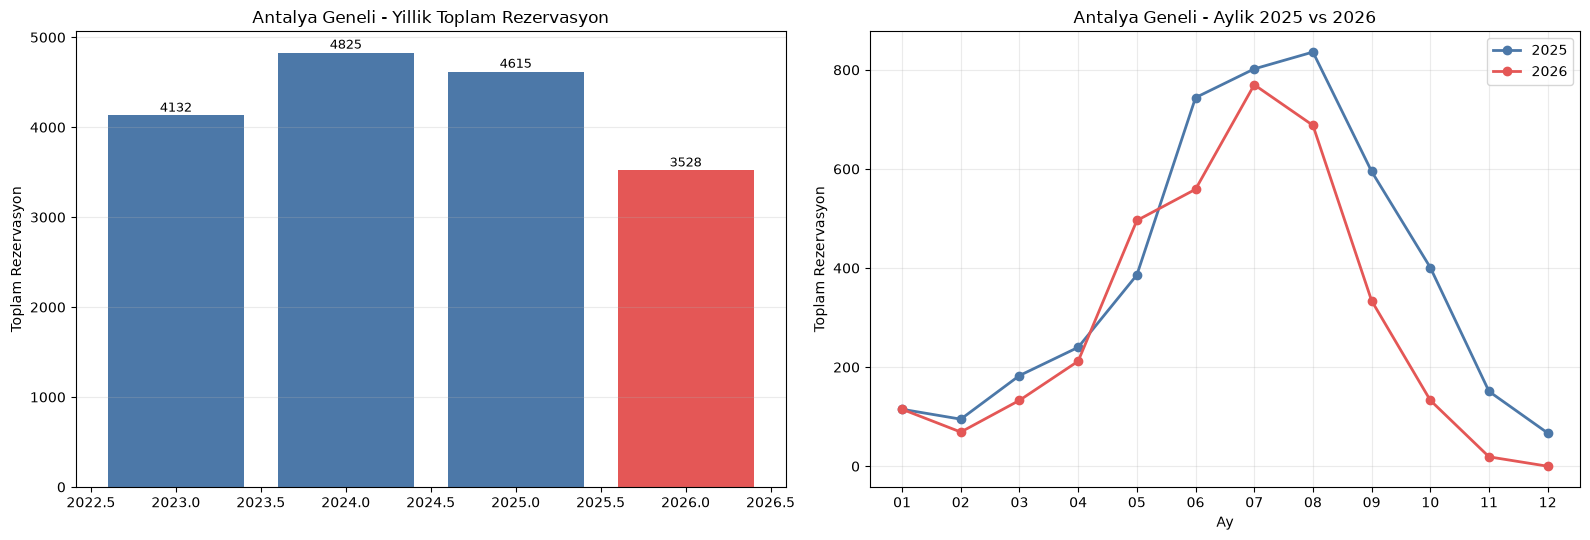


SONUC: Antalya genelinde de DUSUS var. 2025'ten 2026'ya rezervasyonlar %23.6 azalmis.
Dusus sadece Kemer'e ozgu degil, Antalya geneline yayilmis gorunuyor.


In [9]:
# Antalya genelinde 2025 vs 2026 dusus var mi?

import pandas as pd
import numpy as np

if "df" not in globals():
    print("Once veri yukleme hucresini calistirin.")
else:
    antalya_all = df[df["CityName"] == "Antalya"].copy()
    antalya_all["YearId"] = pd.to_numeric(antalya_all["YearId"], errors="coerce")
    antalya_all["MonthId"] = pd.to_numeric(antalya_all["MonthId"], errors="coerce")
    antalya_all["ReservationFlag"] = pd.to_numeric(antalya_all["ReservationFlag"], errors="coerce").fillna(0)

    # Yillik toplam
    yearly = (
        antalya_all.groupby("YearId", observed=True)["ReservationFlag"]
        .sum()
        .rename("TotalReservations")
        .to_frame()
    )
    yearly.index = yearly.index.astype(int)
    yearly["YoY_Pct"] = yearly["TotalReservations"].pct_change() * 100

    print("Antalya Geneli Yillik Rezervasyon:")
    display(yearly.round(1))

    # Aylik karsilastirma 2025 vs 2026
    y2025 = antalya_all[antalya_all["YearId"] == 2025].copy()
    y2026 = antalya_all[antalya_all["YearId"] == 2026].copy()

    monthly_2025 = y2025.groupby("MonthId", observed=True)["ReservationFlag"].sum().rename("Sales_2025")
    monthly_2026 = y2026.groupby("MonthId", observed=True)["ReservationFlag"].sum().rename("Sales_2026")

    monthly_compare = pd.concat([monthly_2025, monthly_2026], axis=1).fillna(0).astype(int)
    monthly_compare["Delta"] = monthly_compare["Sales_2026"] - monthly_compare["Sales_2025"]
    monthly_compare["PctChange"] = np.where(
        monthly_compare["Sales_2025"] > 0,
        ((monthly_compare["Sales_2026"] - monthly_compare["Sales_2025"]) / monthly_compare["Sales_2025"]) * 100,
        np.nan,
    ).round(1)

    total_2025 = monthly_compare["Sales_2025"].sum()
    total_2026 = monthly_compare["Sales_2026"].sum()
    overall_change = ((total_2026 - total_2025) / total_2025 * 100)

    print(f"\nAntalya Geneli: 2025={total_2025} | 2026={total_2026} | Degisim={overall_change:.1f}%")
    print(f"\nAylik karsilastirma (2025 vs 2026):")
    display(monthly_compare)

    # Grafik
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

    # Yillik bar
    years = yearly.index.tolist()
    colors = ["#4C78A8" if y != 2026 else ("#E45756" if yearly.loc[y, "TotalReservations"] < yearly.loc[2025, "TotalReservations"] else "#59A14F") for y in years]
    axes[0].bar(years, yearly["TotalReservations"].values, color=colors)
    for y, v in yearly["TotalReservations"].items():
        axes[0].text(y, v + max(20, v * 0.01), f"{int(v)}", ha="center", fontsize=9)
    axes[0].set_title("Antalya Geneli - Yillik Toplam Rezervasyon")
    axes[0].set_ylabel("Toplam Rezervasyon")
    axes[0].grid(axis="y", alpha=0.25)

    # Aylik karsilastirma
    x = range(1, 13)
    axes[1].plot(x, monthly_compare["Sales_2025"].values, marker="o", linewidth=2, label="2025", color="#4C78A8")
    axes[1].plot(x, monthly_compare["Sales_2026"].values, marker="o", linewidth=2, label="2026", color="#E45756")
    axes[1].set_title("Antalya Geneli - Aylik 2025 vs 2026")
    axes[1].set_xlabel("Ay")
    axes[1].set_ylabel("Toplam Rezervasyon")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"{m:02d}" for m in x])
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    if overall_change < 0:
        print(f"\nSONUC: Antalya genelinde de DUSUS var. 2025'ten 2026'ya rezervasyonlar %{abs(overall_change):.1f} azalmis.")
        print("Dusus sadece Kemer'e ozgu degil, Antalya geneline yayilmis gorunuyor.")
    else:
        print(f"\nSONUC: Antalya genelinde dusus yok, aksine %{overall_change:.1f} artis var.")

Model: Train [2023, 2024], Test 2025, Validation 2026
Toplam ilce sayisi: 12

Ilce bazinda tahminleme ozeti:


,District,Status,TrainMAE,TestMAE_2025,ValMAE_2026,Total_2025_Actual,Total_2026_Actual,Total_2026_Pred,Delta_2026_vs_2025_Actual,PctChange_Actual
0,Aksu,OK,3.6,7.4,11.7,328,278,339,-50,-15.2
1,Alanya,OK,14.3,16.0,28.2,803,641,938,-162,-20.2
2,Demre,OK,0.1,0.1,0.2,0,0,2,0,-
3,Finike,OK,0.4,0.5,0.5,4,1,5,-3,-75.0
4,Kaş,OK,14.3,15.5,31.0,376,205,577,-171,-45.5
5,Kemer,OK,13.2,9.5,31.0,778,509,841,-269,-34.6
6,Kepez,OK,0.7,1.1,1.7,12,6,26,-6,-50.0
7,Konyaaltı,OK,2.8,5.6,9.0,153,115,216,-38,-24.8
8,Kumluca,OK,3.2,4.0,3.9,65,32,73,-33,-50.8
9,Manavgat,OK,20.5,23.4,31.4,1001,931,816,-70,-7.0


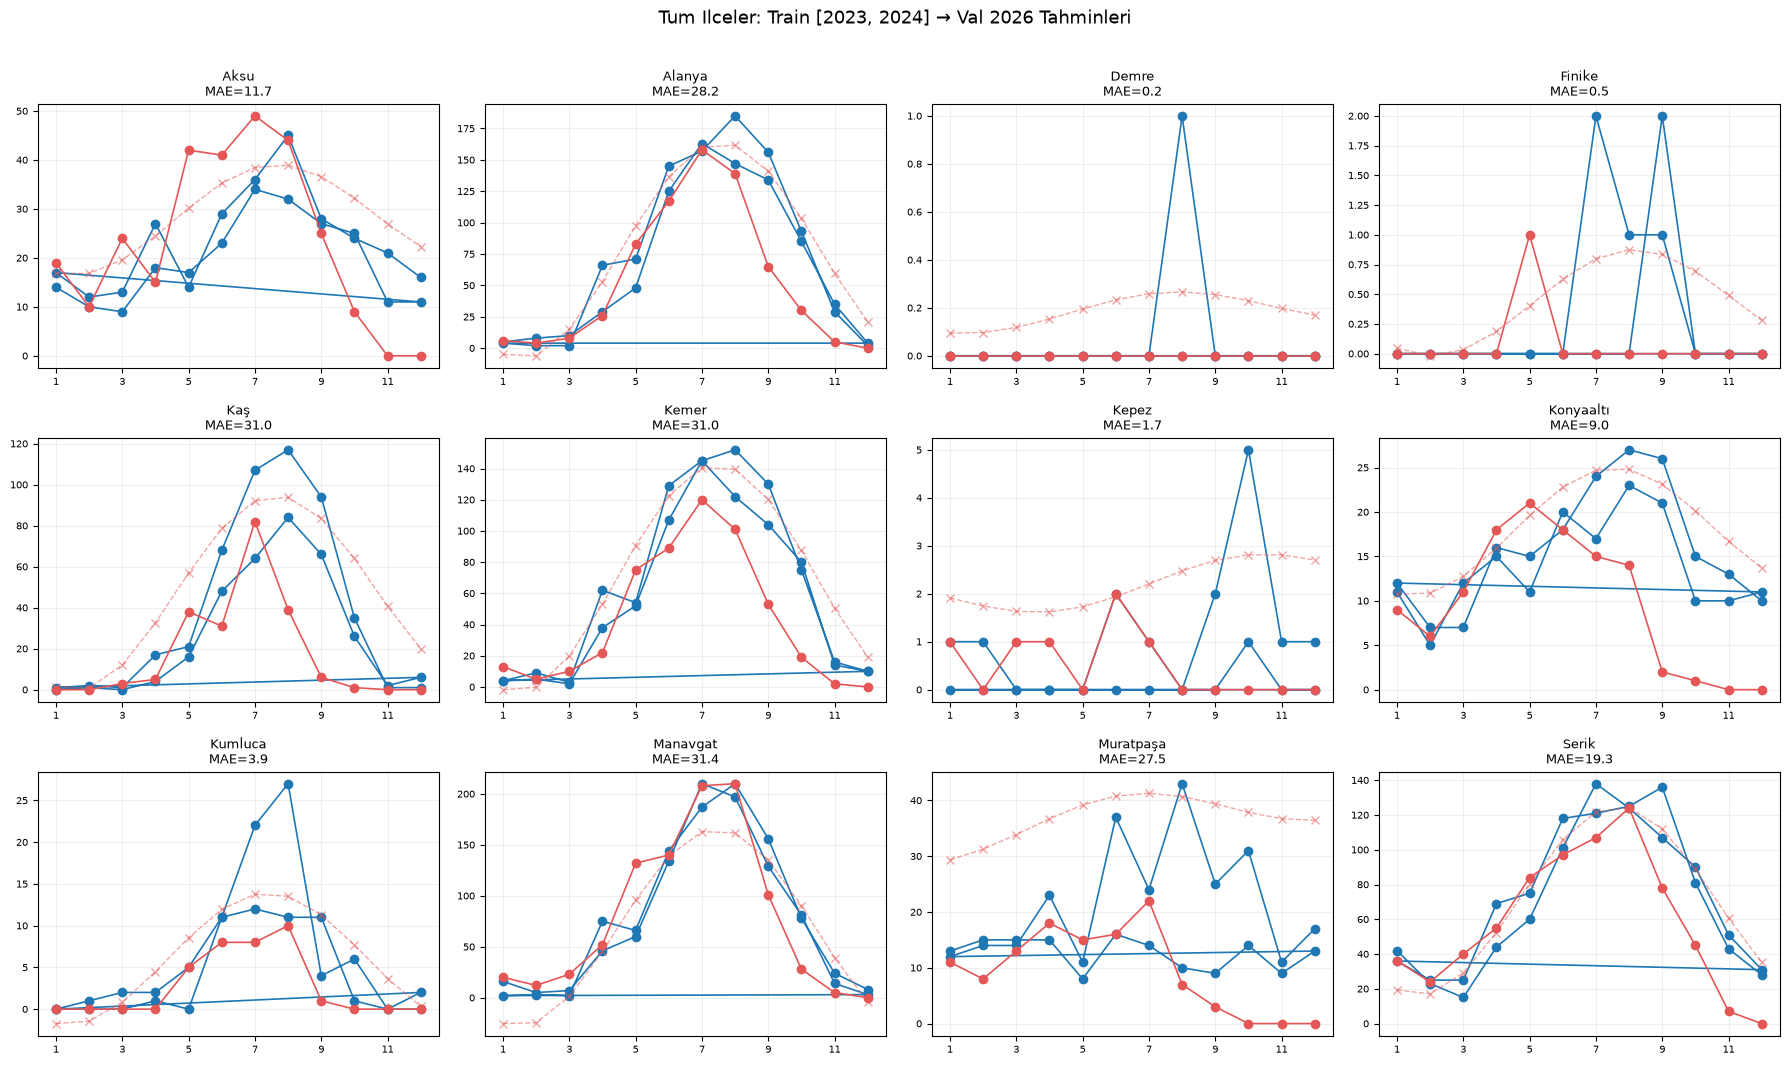

In [10]:
# Tum ilceler bazinda tahminleme: 2023-2024 train, 2025 test, 2026 validation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

if "df" not in globals() or "mapping_df" not in globals():
    raise RuntimeError("Once veri yukleme ve ilce esleme hucrelerini calistirin.")

TRAIN_YEARS = [2023, 2024]
TEST_YEAR = 2025
VAL_YEAR = 2026

target_city = "Antalya"

# --------------------------------------------------------------
# 1. Tum ilceler icin aylik ts olustur
# --------------------------------------------------------------
src = df.copy()
src["YearId"] = pd.to_numeric(src["YearId"], errors="coerce")
src["MonthId"] = pd.to_numeric(src["MonthId"], errors="coerce")
src["ReservationFlag"] = pd.to_numeric(src["ReservationFlag"], errors="coerce").fillna(0)

src = src[
    (src["CityName"] == target_city)
    & (src["YearId"].isin(TRAIN_YEARS + [TEST_YEAR, VAL_YEAR]))
].copy()

src = src.merge(
    mapping_df[["HotelRegionName", "AssignedDistrict"]],
    on="HotelRegionName", how="left"
)
src["AssignedDistrict"] = src["AssignedDistrict"].fillna("Bilinmiyor")

# Ilceleri al (verisi olanlar)
district_list = sorted(src["AssignedDistrict"].unique())

# --------------------------------------------------------------
# 2. Her ilce icin ayri model kur
# --------------------------------------------------------------
def build_features(df_in, base_year=2023):
    d = df_in.copy()
    d["TimeIndex"] = (d["YearId"] - base_year) * 12 + d["MonthId"]
    d["Month_sin"] = np.sin(2 * np.pi * d["MonthId"] / 12)
    d["Month_cos"] = np.cos(2 * np.pi * d["MonthId"] / 12)
    d["Trend"] = d["TimeIndex"]
    return d

feature_cols = ["Month_sin", "Month_cos", "Trend"]

results = []

for district in district_list:
    sub = src[src["AssignedDistrict"] == district]
    ts = (
        sub.groupby(["YearId", "MonthId"], observed=True)["ReservationFlag"]
        .sum()
        .rename("TotalReservation")
        .reset_index()
    )
    ts_f = build_features(ts)

    train = ts_f[ts_f["YearId"].isin(TRAIN_YEARS)].copy()
    test = ts_f[ts_f["YearId"] == TEST_YEAR].copy()
    val = ts_f[ts_f["YearId"] == VAL_YEAR].copy()

    if train.empty or len(train) < 6:
        results.append({"District": district, "Status": "SKIP (yetersiz veri)"})
        continue

    X_train = train[feature_cols].values
    y_train = train["TotalReservation"].values
    X_test = test[feature_cols].values
    y_test = test["TotalReservation"].values if not test.empty else np.array([])
    X_val = val[feature_cols].values
    y_val = val["TotalReservation"].values if not val.empty else np.array([])

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test) if len(X_test) > 0 else np.array([])
    val_pred = model.predict(X_val) if len(X_val) > 0 else np.array([])

    train_mae = float(np.mean(np.abs(y_train - train_pred)))
    test_mae = float(np.mean(np.abs(y_test - test_pred))) if len(test_pred) > 0 else np.nan
    val_mae = float(np.mean(np.abs(y_val - val_pred))) if len(val_pred) > 0 else np.nan

    total_2025_actual = int(y_test.sum()) if len(y_test) > 0 else 0
    total_2026_actual = int(y_val.sum()) if len(y_val) > 0 else 0
    total_2026_pred = int(val_pred.sum().round()) if len(val_pred) > 0 else 0

    results.append({
        "District": district,
        "Status": "OK",
        "TrainMAE": round(train_mae, 1),
        "TestMAE_2025": round(test_mae, 1) if not np.isnan(test_mae) else "-",
        "ValMAE_2026": round(val_mae, 1) if not np.isnan(val_mae) else "-",
        "Total_2025_Actual": total_2025_actual,
        "Total_2026_Actual": total_2026_actual,
        "Total_2026_Pred": total_2026_pred,
        "Delta_2026_vs_2025_Actual": total_2026_actual - total_2025_actual,
        "PctChange_Actual": round((total_2026_actual - total_2025_actual) / total_2025_actual * 100, 1) if total_2025_actual > 0 else "-",
        "Model": model,
        "ValData": val,
        "ValPred": val_pred,
        "y_val": y_val,
    })

# --------------------------------------------------------------
# 3. Ozet tablo
# --------------------------------------------------------------
summary_df = pd.DataFrame(results)
display_cols_summary = [
    "District", "Status", "TrainMAE", "TestMAE_2025", "ValMAE_2026",
    "Total_2025_Actual", "Total_2026_Actual", "Total_2026_Pred",
    "Delta_2026_vs_2025_Actual", "PctChange_Actual",
]

print(f"Model: Train {TRAIN_YEARS}, Test {TEST_YEAR}, Validation {VAL_YEAR}")
print(f"Toplam ilce sayisi: {len(district_list)}")
print(f"\nIlce bazinda tahminleme ozeti:")
display(summary_df[display_cols_summary])

# --------------------------------------------------------------
# 4. Tum ilceleri tek panelde gorsellestir
# --------------------------------------------------------------
valid_results = [r for r in results if r["Status"] == "OK"]
n = len(valid_results)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 3.5))
axes_flat = axes.flatten() if n > 1 else [axes]

for idx, res in enumerate(valid_results):
    ax = axes_flat[idx]
    district_name = res["District"]

    train_f = build_features(
        src[(src["AssignedDistrict"] == district_name) & (src["YearId"].isin(TRAIN_YEARS))]
        .groupby(["YearId", "MonthId"], observed=True)["ReservationFlag"].sum()
        .rename("TotalReservation").reset_index()
    )

    ax.plot(train_f["MonthId"], train_f["TotalReservation"], marker="o", label=f"Train {TRAIN_YEARS}", color="#1f77b4", linewidth=1.2)
    ax.plot(res["ValData"]["MonthId"], res["y_val"], marker="o", label=f"{VAL_YEAR} Actual", color="#e45756", linewidth=1.2)
    ax.plot(res["ValData"]["MonthId"], res["ValPred"], linestyle="--", marker="x", label=f"{VAL_YEAR} Pred", color="#e4575688", linewidth=1)
    ax.set_title(f"{district_name}\nMAE={res['ValMAE_2026']}", fontsize=9)
    ax.set_xticks(range(1, 13, 2))
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

# Bos subplotlari gizle
for idx in range(len(valid_results), len(axes_flat)):
    axes_flat[idx].axis("off")

fig.suptitle(f"Tum Ilceler: Train {TRAIN_YEARS} → Val {VAL_YEAR} Tahminleri", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

Guclu Model: GradientBoostingRegressor + ElasticNet Ensemble
Train [2023, 2024], Test 2025, Validation 2026
Toplam ilce: 12

GradientBoosting, LR'a gore Val MAE'de ortalama %51.8 iyilesme sagladi.
Ensemble (GBR+EN), LR'a gore Val MAE'de ortalama %35.4 iyilesme sagladi.
En iyi ensemble performansi: Demre (MAE=0.3)


,District,ValMAE_GBR,ValMAE_ElasticNet,ValMAE_LR,ValMAE_Ensemble,Total_2025,Total_2026_Actual,Total_2026_Pred_GBR,Delta_Actual,PctChange_Actual
0,Aksu,9.8,16.0,17.1,12.0,328,278,308,-50,-15.2
1,Alanya,25.1,31.8,43.8,28.1,803,641,898,-162,-20.2
2,Demre,0.2,0.5,0.7,0.3,0,0,1,0,-
3,Finike,0.5,0.8,0.6,0.6,4,1,5,-3,-75.0
4,Kaş,25.6,59.6,66.6,41.1,376,205,475,-171,-45.5
5,Kemer,25.3,30.9,40.8,27.6,778,509,765,-269,-34.6
6,Kepez,1.2,10.9,11.4,6.0,12,6,19,-6,-50.0
7,Konyaaltı,8.2,19.1,20.8,13.2,153,115,203,-38,-24.8
8,Kumluca,5.1,13.5,15.8,8.9,65,32,84,-33,-50.8
9,Manavgat,20.6,38.7,51.9,26.4,1001,931,943,-70,-7.0


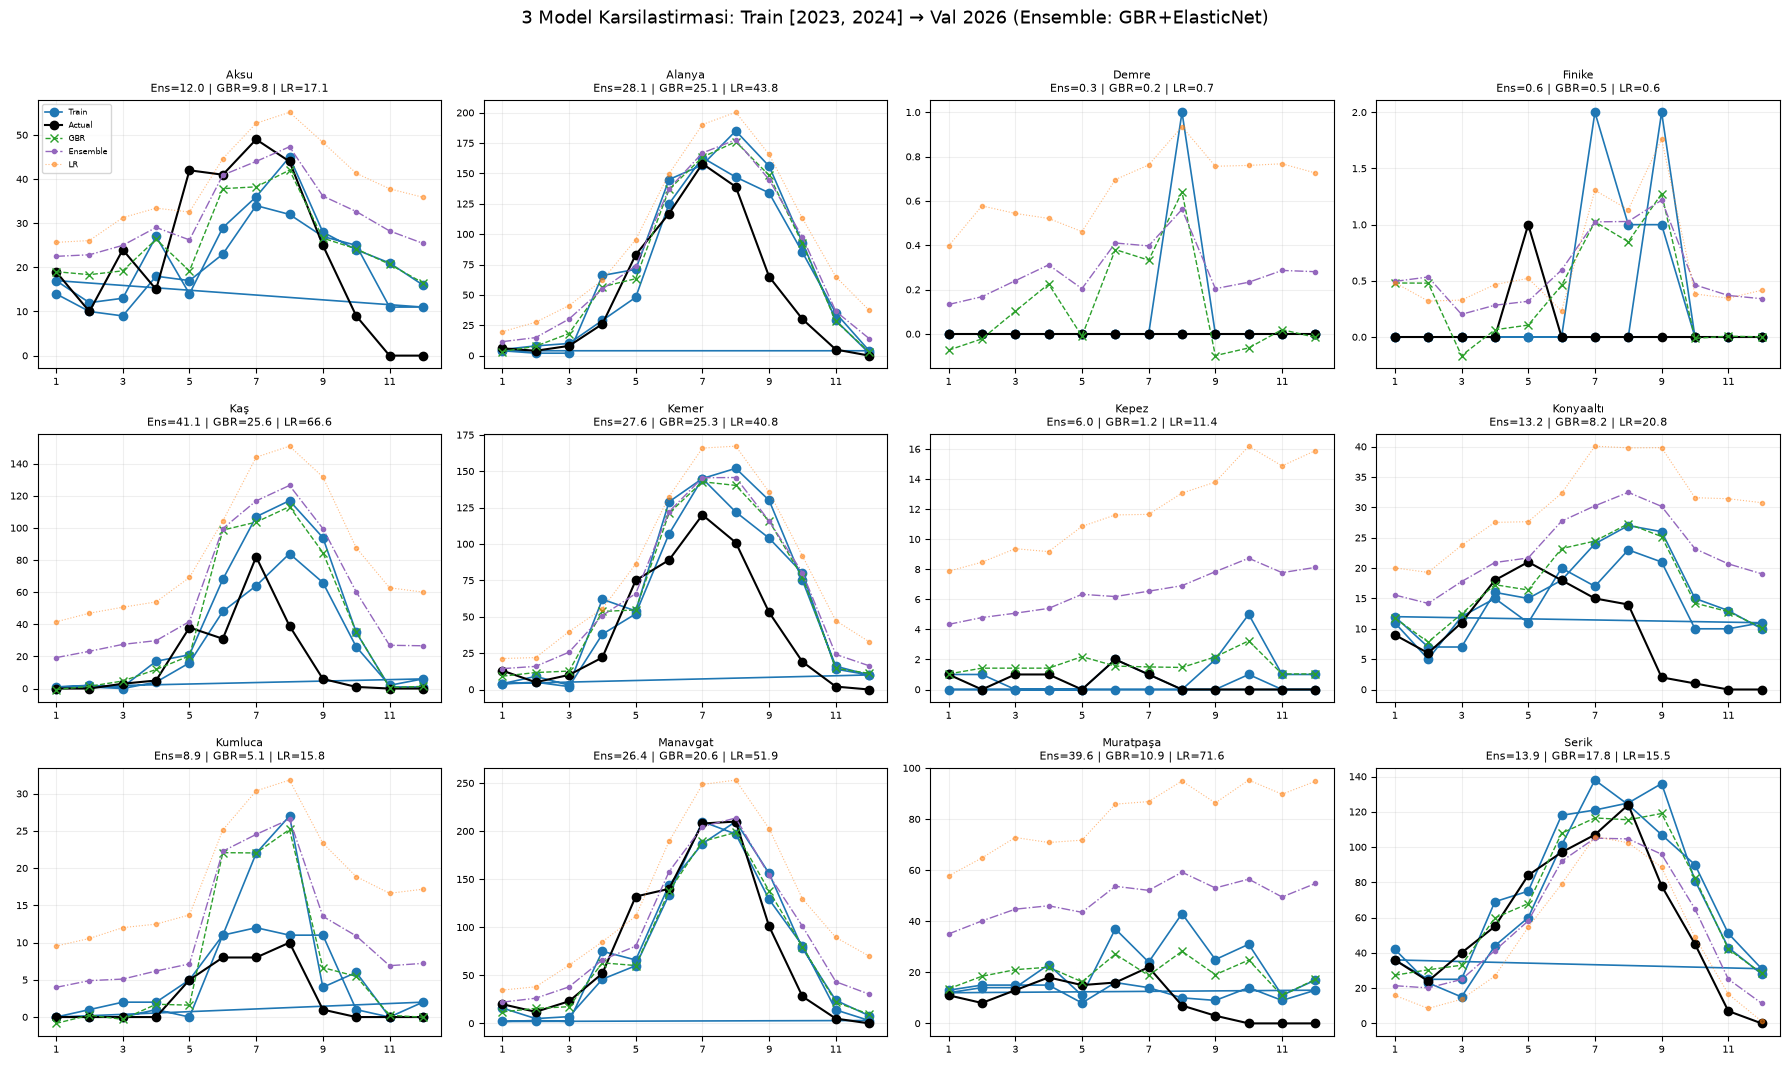

In [4]:
# Guclu Model: GradientBoosting + ElasticNet ensemble ile tum ilceler tahminlemesi
# (2023-2024 train, 2025 test, 2026 val) - OpenMP gerektirmez

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor

if "df" not in globals() or "mapping_df" not in globals():
    raise RuntimeError("Once veri yukleme ve ilce esleme hucrelerini calistirin.")

TRAIN_YEARS = [2023, 2024]
TEST_YEAR = 2025
VAL_YEAR = 2026

target_city = "Antalya"

# --------------------------------------------------------------
# 1. Veri hazirligi
# --------------------------------------------------------------
src = df.copy()
src["YearId"] = pd.to_numeric(src["YearId"], errors="coerce")
src["MonthId"] = pd.to_numeric(src["MonthId"], errors="coerce")
src["ReservationFlag"] = pd.to_numeric(src["ReservationFlag"], errors="coerce").fillna(0)

src = src[
    (src["CityName"] == target_city)
    & (src["YearId"].isin(TRAIN_YEARS + [TEST_YEAR, VAL_YEAR]))
].copy()

src = src.merge(
    mapping_df[["HotelRegionName", "AssignedDistrict"]],
    on="HotelRegionName", how="left"
)
src["AssignedDistrict"] = src["AssignedDistrict"].fillna("Bilinmiyor")

district_list = sorted(src["AssignedDistrict"].unique())

# --------------------------------------------------------------
# 2. Zengin feature seti
# --------------------------------------------------------------
def build_features_rich(df_in, base_year=2023):
    d = df_in.copy()
    d["TimeIndex"] = (d["YearId"] - base_year) * 12 + d["MonthId"]
    d["Month_sin"] = np.sin(2 * np.pi * d["MonthId"] / 12)
    d["Month_cos"] = np.cos(2 * np.pi * d["MonthId"] / 12)
    d["Month_sin_2"] = np.sin(4 * np.pi * d["MonthId"] / 12)
    d["Month_cos_2"] = np.cos(4 * np.pi * d["MonthId"] / 12)
    d["Trend"] = d["TimeIndex"]
    d["Trend_sq"] = d["TimeIndex"] ** 2
    d["Is_Summer"] = d["MonthId"].isin([6, 7, 8]).astype(int)
    d["Is_Shoulder"] = d["MonthId"].isin([5, 9, 10]).astype(int)
    d["Is_Winter"] = d["MonthId"].isin([11, 12, 1, 2]).astype(int)
    return d

feature_cols = [
    "Month_sin", "Month_cos", "Month_sin_2", "Month_cos_2",
    "Trend", "Trend_sq",
    "Is_Summer", "Is_Shoulder", "Is_Winter",
]

gb_results = []

for district in district_list:
    sub = src[src["AssignedDistrict"] == district]
    ts = (
        sub.groupby(["YearId", "MonthId"], observed=True)["ReservationFlag"]
        .sum()
        .rename("TotalReservation")
        .reset_index()
    )
    ts_f = build_features_rich(ts)

    train = ts_f[ts_f["YearId"].isin(TRAIN_YEARS)].copy()
    test = ts_f[ts_f["YearId"] == TEST_YEAR].copy()
    val = ts_f[ts_f["YearId"] == VAL_YEAR].copy()

    if train.empty or len(train) < 6:
        gb_results.append({"District": district, "Status": "SKIP"})
        continue

    X_train = train[feature_cols].values
    y_train = train["TotalReservation"].values
    X_test = test[feature_cols].values
    y_test = test["TotalReservation"].values if not test.empty else np.array([])
    X_val = val[feature_cols].values
    y_val = val["TotalReservation"].values if not val.empty else np.array([])

    # ---- Model 1: GradientBoostingRegressor (guclu non-linear) ----
    gbr = GradientBoostingRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        min_samples_leaf=2,
        random_state=42,
    )
    gbr.fit(X_train, y_train)
    val_pred_gbr = gbr.predict(X_val) if len(X_val) > 0 else np.array([])
    val_mae_gbr = float(np.mean(np.abs(y_val - val_pred_gbr))) if len(val_pred_gbr) > 0 else np.nan

    # ---- Model 2: ElasticNet (duzgunlestirilmis lineer) ----
    en = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
    en.fit(X_train, y_train)
    val_pred_en = en.predict(X_val) if len(X_val) > 0 else np.array([])
    val_mae_en = float(np.mean(np.abs(y_val - val_pred_en))) if len(val_pred_en) > 0 else np.nan

    # ---- Model 3: Baseline LinearRegression ----
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    val_pred_lr = lr.predict(X_val) if len(X_val) > 0 else np.array([])
    val_mae_lr = float(np.mean(np.abs(y_val - val_pred_lr))) if len(val_pred_lr) > 0 else np.nan

    # ---- Ensemble: GBR + EN ortalamasi (dengeli tahmin) ----
    ensemble_pred = (val_pred_gbr + val_pred_en) / 2.0
    val_mae_ensemble = float(np.mean(np.abs(y_val - ensemble_pred)))

    total_2025 = int(y_test.sum()) if len(y_test) > 0 else 0
    total_2026_actual = int(y_val.sum()) if len(y_val) > 0 else 0
    total_2026_pred_gbr = int(val_pred_gbr.sum().round()) if len(val_pred_gbr) > 0 else 0
    total_2026_pred_lr = int(val_pred_lr.sum().round()) if len(val_pred_lr) > 0 else 0

    gb_results.append({
        "District": district,
        "Status": "OK",
        "ValMAE_GBR": round(val_mae_gbr, 1),
        "ValMAE_ElasticNet": round(val_mae_en, 1),
        "ValMAE_LR": round(val_mae_lr, 1),
        "ValMAE_Ensemble": round(val_mae_ensemble, 1),
        "Total_2025": total_2025,
        "Total_2026_Actual": total_2026_actual,
        "Total_2026_Pred_GBR": total_2026_pred_gbr,
        "Total_2026_Pred_LR": total_2026_pred_lr,
        "Delta_Actual": total_2026_actual - total_2025,
        "PctChange_Actual": round((total_2026_actual - total_2025) / total_2025 * 100, 1) if total_2025 > 0 else "-",
        "ValData": val,
        "ValPred_GBR": val_pred_gbr,
        "ValPred_LR": val_pred_lr,
        "ValPred_Ensemble": ensemble_pred,
        "y_val": y_val,
    })

# --------------------------------------------------------------
# 3. Ozet tablo
# --------------------------------------------------------------
summary_df = pd.DataFrame(gb_results)
display_cols_s = [
    "District", "ValMAE_GBR", "ValMAE_ElasticNet", "ValMAE_LR", "ValMAE_Ensemble",
    "Total_2025", "Total_2026_Actual", "Total_2026_Pred_GBR",
    "Delta_Actual", "PctChange_Actual",
]

print(f"Guclu Model: GradientBoostingRegressor + ElasticNet Ensemble")
print(f"Train {TRAIN_YEARS}, Test {TEST_YEAR}, Validation {VAL_YEAR}")
print(f"Toplam ilce: {len(district_list)}")

# MAE iyilesmesi
valid_gb = [r for r in gb_results if r["Status"] == "OK"]
gb_vs_lr = []
for r in valid_gb:
    if isinstance(r["ValMAE_GBR"], (int, float)) and isinstance(r["ValMAE_LR"], (int, float)) and r["ValMAE_LR"] > 0:
        gb_vs_lr.append((r["ValMAE_LR"] - r["ValMAE_GBR"]) / r["ValMAE_LR"] * 100)

ensemble_vs_lr = []
for r in valid_gb:
    if isinstance(r["ValMAE_Ensemble"], (int, float)) and isinstance(r["ValMAE_LR"], (int, float)) and r["ValMAE_LR"] > 0:
        ensemble_vs_lr.append((r["ValMAE_LR"] - r["ValMAE_Ensemble"]) / r["ValMAE_LR"] * 100)

avg_gb_imp = np.mean(gb_vs_lr) if gb_vs_lr else 0
avg_ensemble_imp = np.mean(ensemble_vs_lr) if ensemble_vs_lr else 0

best_model = [r for r in valid_gb if r["ValMAE_Ensemble"] == min(v["ValMAE_Ensemble"] for v in valid_gb)][0]

print(f"\nGradientBoosting, LR'a gore Val MAE'de ortalama %{avg_gb_imp:.1f} iyilesme sagladi.")
print(f"Ensemble (GBR+EN), LR'a gore Val MAE'de ortalama %{avg_ensemble_imp:.1f} iyilesme sagladi.")
print(f"En iyi ensemble performansi: {best_model['District']} (MAE={best_model['ValMAE_Ensemble']})")

display(summary_df[display_cols_s])

# --------------------------------------------------------------
# 4. Tum ilceler panel grafik (3 model karsilastirmali)
# --------------------------------------------------------------
n = len(valid_gb)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 3.5))
axes_flat = axes.flatten() if n > 1 else [axes]

for idx, res in enumerate(valid_gb):
    ax = axes_flat[idx]
    dn = res["District"]

    train_ts = build_features_rich(
        src[(src["AssignedDistrict"] == dn) & (src["YearId"].isin(TRAIN_YEARS))]
        .groupby(["YearId", "MonthId"], observed=True)["ReservationFlag"].sum()
        .rename("TotalReservation").reset_index()
    )

    ax.plot(train_ts["MonthId"], train_ts["TotalReservation"], marker="o", label=f"Train", color="#1f77b4", linewidth=1.2)
    ax.plot(res["ValData"]["MonthId"], res["y_val"], marker="o", label=f"Actual", color="black", linewidth=1.5)
    ax.plot(res["ValData"]["MonthId"], res["ValPred_GBR"], linestyle="--", marker="x", label=f"GBR", color="#2ca02c", linewidth=1)
    ax.plot(res["ValData"]["MonthId"], res["ValPred_Ensemble"], linestyle="-.", marker=".", label=f"Ensemble", color="#9467bd", linewidth=1)
    ax.plot(res["ValData"]["MonthId"], res["ValPred_LR"], linestyle=":", marker=".", label=f"LR", color="#ff7f0e88", linewidth=0.8)

    ax.set_title(f"{dn}\nEns={res['ValMAE_Ensemble']} | GBR={res['ValMAE_GBR']} | LR={res['ValMAE_LR']}", fontsize=8)
    ax.set_xticks(range(1, 13, 2))
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=6, loc="upper left")

for idx in range(len(valid_gb), len(axes_flat)):
    axes_flat[idx].axis("off")

fig.suptitle(f"3 Model Karsilastirmasi: Train {TRAIN_YEARS} → Val {VAL_YEAR} (Ensemble: GBR+ElasticNet)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

HAFTALIK Tahmin: Antalya Geneli (GradientBoostingRegressor)
Train: [2023, 2024, 2025] (159 hafta) | Val: 2026 (53 hafta)
Train MAE  : 9.5
Val   MAE  : 29.2  (GBR)
Val   MAE  : 25.4  (LR baseline)
GBR vs LR  : %-15.0 iyilesme

2025 Toplam (actual) : 4615
2026 Toplam (actual) : 3528
2026 Toplam (GBR pred): 4058
2026 Toplam (LR pred) : 3644
2026 Gercek Degisim  : %-23.6
2026 GBR Tahmin Deg. : %-12.1


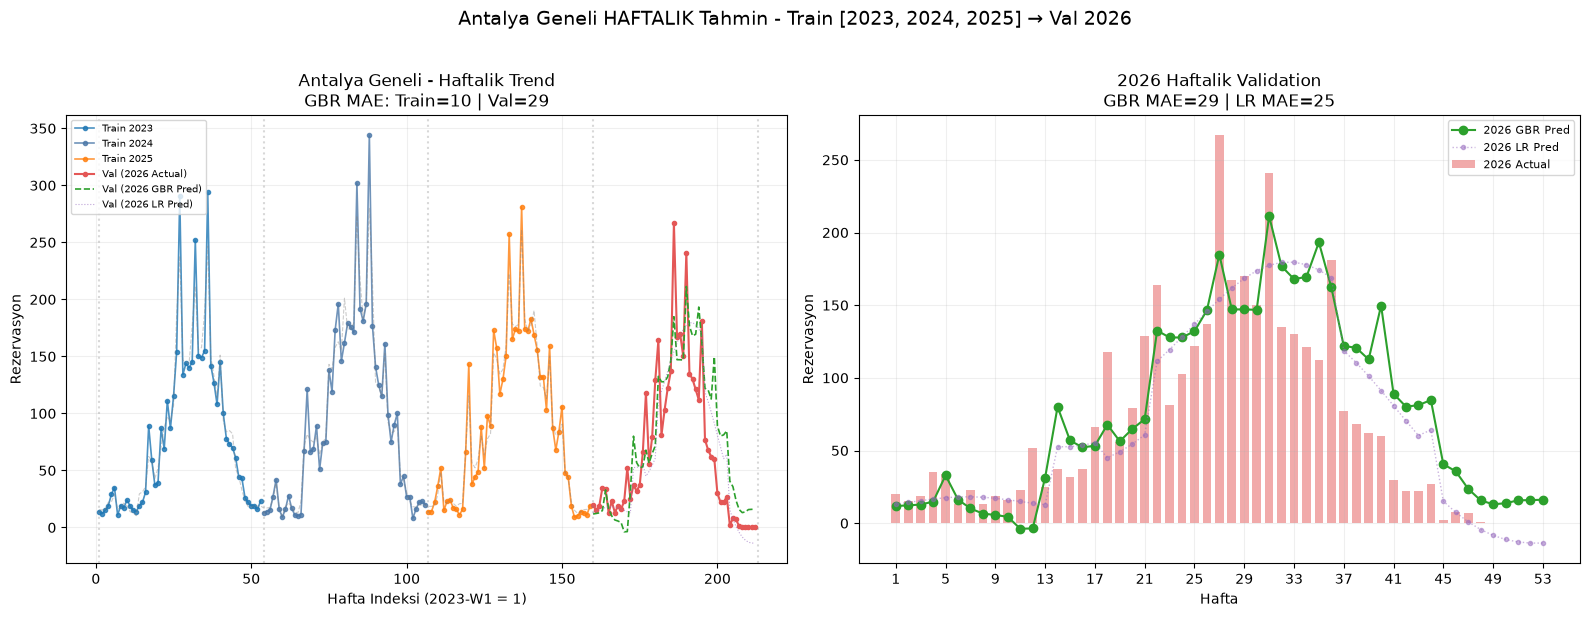


2026 Haftalik Tahmin Detayi (ilk ve son 10 hafta):


,YearId,Actual,GBR_Pred,LR_Pred,GBR_Error,LR_Error
WeekId,,,,,,
1,2026,20,12,13,-8,-7
2,2026,15,12,14,-3,-1
3,2026,19,13,15,-6,-4
4,2026,35,15,17,-20,-18
5,2026,34,33,18,-1,-16
6,2026,13,16,18,3,5
7,2026,23,10,18,-13,-5
8,2026,13,7,18,-6,5
9,2026,19,6,17,-13,-2



4-haftalik (≈aylik) toplam karsilastirmasi:


,Actual,GBR_Pred,LR_Pred,GBR_Error,LR_Error
MonthGroup,,,,,
1,89,52,59,-37,-30
2,83,66,72,-17,-11
3,110,2,62,-108,-48
4,131,220,173,89,42
5,319,242,203,-77,-116
6,477,461,419,-16,-58
7,693,610,599,-83,-94
8,696,682,698,-14,2
9,544,692,701,148,157



✓ Haftalik model (Train 2023-2025) tamamlandi.


In [7]:
# HAFTALIK Tahmin v3: Antalya Geneli (2023-2025 train, 2026 val)
# GradientBoostingRegressor + sin/cos seasonal features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

if "df" not in globals():
    raise RuntimeError("Once veri yukleme hucresini calistirin.")

TRAIN_YEARS_W = [2023, 2024, 2025]
VAL_YEAR_W = 2026
target_city = "Antalya"

# --------------------------------------------------------------
# 1. Haftalik Antalya geneli zaman serisi
# --------------------------------------------------------------
w_src = df.copy()
w_src["YearId"] = pd.to_numeric(w_src["YearId"], errors="coerce")
w_src["WeekId"] = pd.to_numeric(w_src["WeekId"], errors="coerce")
w_src["ReservationFlag"] = pd.to_numeric(w_src["ReservationFlag"], errors="coerce").fillna(0)

w_ant = w_src[
    (w_src["CityName"] == target_city)
    & (w_src["YearId"].isin(TRAIN_YEARS_W + [VAL_YEAR_W]))
].copy()

# Haftalik toplam
w_ts = (
    w_ant.groupby(["YearId", "WeekId"], observed=True)["ReservationFlag"]
    .sum()
    .rename("TotalReservation")
    .reset_index()
)

# Global hafta indeksi: 2023-W1 = 1
w_ts["TimeIndex"] = (w_ts["YearId"] - 2023) * 53 + w_ts["WeekId"]

# --------------------------------------------------------------
# 2. Feature engineering (haftalik periyot = 53)
# --------------------------------------------------------------
def build_weekly_features(df_in):
    d = df_in.copy()
    # 53 haftalik sezonsallik
    d["Week_sin"] = np.sin(2 * np.pi * d["WeekId"] / 53)
    d["Week_cos"] = np.cos(2 * np.pi * d["WeekId"] / 53)
    # 2. harmonik (yari yillik desen icin ~26.5 hafta)
    d["Week_sin_2"] = np.sin(4 * np.pi * d["WeekId"] / 53)
    d["Week_cos_2"] = np.cos(4 * np.pi * d["WeekId"] / 53)
    # Trend
    d["Trend"] = d["TimeIndex"]
    d["Trend_sq"] = d["TimeIndex"] ** 2
    # Mevsim gostergeleri (ay bazindan haftaya uyarlandi)
    d["Is_High"] = d["WeekId"].isin(range(22, 37)).astype(int)   # Haz-Tem-Agu (~W22-36)
    d["Is_Shoulder"] = d["WeekId"].isin(range(18, 22)).astype(int) | d["WeekId"].isin(range(37, 44)).astype(int)
    d["Is_Low"] = d["WeekId"].isin(range(1, 14)).astype(int) | d["WeekId"].isin(range(45, 54)).astype(int)
    return d

w_ts_f = build_weekly_features(w_ts)

w_feature_cols = [
    "Week_sin", "Week_cos", "Week_sin_2", "Week_cos_2",
    "Trend", "Trend_sq",
    "Is_High", "Is_Shoulder", "Is_Low",
]

w_train = w_ts_f[w_ts_f["YearId"].isin(TRAIN_YEARS_W)].copy()
w_val = w_ts_f[w_ts_f["YearId"] == VAL_YEAR_W].copy()

X_wtrain = w_train[w_feature_cols].values
y_wtrain = w_train["TotalReservation"].values
X_wval = w_val[w_feature_cols].values
y_wval = w_val["TotalReservation"].values

# --------------------------------------------------------------
# 3. Model: GradientBoostingRegressor
# --------------------------------------------------------------
gbr_w = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    min_samples_leaf=2,
    random_state=42,
)
gbr_w.fit(X_wtrain, y_wtrain)

w_train_pred = gbr_w.predict(X_wtrain)
w_val_pred = gbr_w.predict(X_wval)

w_train_mae = float(np.mean(np.abs(y_wtrain - w_train_pred)))
w_val_mae = float(np.mean(np.abs(y_wval - w_val_pred)))

# Baseline LR
lr_w = LinearRegression()
lr_w.fit(X_wtrain, y_wtrain)
w_val_pred_lr = lr_w.predict(X_wval)
w_val_mae_lr = float(np.mean(np.abs(y_wval - w_val_pred_lr)))

print("=" * 65)
print(f"HAFTALIK Tahmin: Antalya Geneli (GradientBoostingRegressor)")
print(f"Train: {TRAIN_YEARS_W} ({len(w_train)} hafta) | Val: {VAL_YEAR_W} ({len(w_val)} hafta)")
print(f"Train MAE  : {w_train_mae:.1f}")
print(f"Val   MAE  : {w_val_mae:.1f}  (GBR)")
print(f"Val   MAE  : {w_val_mae_lr:.1f}  (LR baseline)")
print(f"GBR vs LR  : %{((w_val_mae_lr - w_val_mae) / w_val_mae_lr * 100):.1f} iyilesme")

# Yillik toplam karsilastirma
# 2025 actual hesapla
w_2025_actual = w_train[w_train["YearId"] == 2025]["TotalReservation"].sum()
total_2026_actual_w = int(y_wval.sum())
total_2026_pred_w = int(w_val_pred.sum().round())
total_2026_pred_lr_w = int(w_val_pred_lr.sum().round())

print(f"\n2025 Toplam (actual) : {int(w_2025_actual)}")
print(f"2026 Toplam (actual) : {total_2026_actual_w}")
print(f"2026 Toplam (GBR pred): {total_2026_pred_w}")
print(f"2026 Toplam (LR pred) : {total_2026_pred_lr_w}")
print(f"2026 Gercek Degisim  : %{((total_2026_actual_w - int(w_2025_actual)) / int(w_2025_actual) * 100):.1f}")
print(f"2026 GBR Tahmin Deg. : %{((total_2026_pred_w - int(w_2025_actual)) / int(w_2025_actual) * 100):.1f}")

# --------------------------------------------------------------
# 4. Gorsellestirme
# --------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Panel 1: Tum veri (Train + Val) --
ax = axes[0]
year_boundaries = [1, 54, 107, 160, 213]

# Train'i yillara gore ayri renklendir
colors_train = {2023: "#1f77b4", 2024: "#4C78A8", 2025: "#ff7f0e"}
for yr in TRAIN_YEARS_W:
    mask = w_train["YearId"] == yr
    ax.plot(w_train.loc[mask, "TimeIndex"], w_train.loc[mask, "TotalReservation"].values,
            marker=".", linewidth=1.2, label=f"Train {yr}", color=colors_train[yr], alpha=0.8)

ax.plot(w_train["TimeIndex"], w_train_pred, linestyle="--", linewidth=0.8, alpha=0.4, color="gray")
ax.plot(w_val["TimeIndex"], y_wval, marker=".", linewidth=1.5, label=f"Val ({VAL_YEAR_W} Actual)", color="#e45756")
ax.plot(w_val["TimeIndex"], w_val_pred, linestyle="--", linewidth=1.2, label=f"Val ({VAL_YEAR_W} GBR Pred)", color="#2ca02c")
ax.plot(w_val["TimeIndex"], w_val_pred_lr, linestyle=":", linewidth=0.8, label=f"Val ({VAL_YEAR_W} LR Pred)", color="#9467bd", alpha=0.6)

for b in year_boundaries:
    ax.axvline(b, color="gray", linestyle=":", alpha=0.3)
ax.set_title(f"Antalya Geneli - Haftalik Trend\nGBR MAE: Train={w_train_mae:.0f} | Val={w_val_mae:.0f}")
ax.set_xlabel("Hafta Indeksi (2023-W1 = 1)")
ax.set_ylabel("Rezervasyon")
ax.legend(fontsize=7, loc="upper left")
ax.grid(alpha=0.2)

# -- Panel 2: 2026 Validation yili zoom --
ax = axes[1]
x_2026 = w_val["WeekId"].values
ax.bar(x_2026, y_wval, alpha=0.5, label="2026 Actual", color="#e45756", width=0.7)
ax.plot(x_2026, w_val_pred, marker="o", linewidth=1.5, label="2026 GBR Pred", color="#2ca02c")
ax.plot(x_2026, w_val_pred_lr, linestyle=":", marker=".", linewidth=1, label="2026 LR Pred", color="#9467bd", alpha=0.5)
ax.set_title(f"2026 Haftalik Validation\nGBR MAE={w_val_mae:.0f} | LR MAE={w_val_mae_lr:.0f}")
ax.set_xlabel("Hafta")
ax.set_ylabel("Rezervasyon")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
ax.set_xticks(range(1, 54, 4))

plt.suptitle(f"Antalya Geneli HAFTALIK Tahmin - Train {TRAIN_YEARS_W} → Val {VAL_YEAR_W}", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 5. 4-haftalik ozet tablo
# --------------------------------------------------------------
print("\n2026 Haftalik Tahmin Detayi (ilk ve son 10 hafta):")
w_comp = w_val[["YearId", "WeekId"]].copy()
w_comp["Actual"] = y_wval.astype(int)
w_comp["GBR_Pred"] = w_val_pred.round().astype(int)
w_comp["LR_Pred"] = w_val_pred_lr.round().astype(int)
w_comp["GBR_Error"] = w_comp["GBR_Pred"] - w_comp["Actual"]
w_comp["LR_Error"] = w_comp["LR_Pred"] - w_comp["Actual"]
display(pd.concat([w_comp.head(15), w_comp.tail(15)]).set_index("WeekId"))

# 4-haftalik (≈aylik) toplam karsilastirma
w_comp["MonthGroup"] = ((w_comp["WeekId"] - 1) // 4) + 1
monthly_w = w_comp.groupby("MonthGroup")[["Actual", "GBR_Pred", "LR_Pred"]].sum().astype(int)
monthly_w["GBR_Error"] = monthly_w["GBR_Pred"] - monthly_w["Actual"]
monthly_w["LR_Error"] = monthly_w["LR_Pred"] - monthly_w["Actual"]
print("\n4-haftalik (≈aylik) toplam karsilastirmasi:")
display(monthly_w)

print(f"\n✓ Haftalik model (Train 2023-2025) tamamlandi.")

HAFTALIK Ilce Bazinda Tahmin: GradientBoostingRegressor
Train: [2023, 2024, 2025] (66759 hafta) | Val: 2026
Ilce sayisi: 12
GBR, LR'a gore Val MAE'de ortalama %-2.7 iyilesme sagladi.

Ilce bazinda haftalik tahmin ozeti:


,District,Status,ValMAE_GBR,ValMAE_LR,Total_2025,Total_2026_Actual,Total_2026_Pred_GBR,Delta_Actual,PctChange_Actual
0,Aksu,OK,2.5,2.3,328,278,296,-50,-15.2
1,Alanya,OK,5.0,5.2,803,641,754,-162,-20.2
2,Demre,OK,0.0,0.0,0,0,-1,0,-
3,Finike,OK,0.1,0.1,4,1,4,-3,-75.0
4,Kaş,OK,4.1,4.2,376,205,321,-171,-45.5
5,Kemer,OK,5.5,5.3,778,509,677,-269,-34.6
6,Kepez,OK,0.2,0.3,12,6,6,-6,-50.0
7,Konyaaltı,OK,1.6,1.4,153,115,84,-38,-24.8
8,Kumluca,OK,0.8,0.7,65,32,59,-33,-50.8
9,Manavgat,OK,5.7,6.3,1001,931,982,-70,-7.0


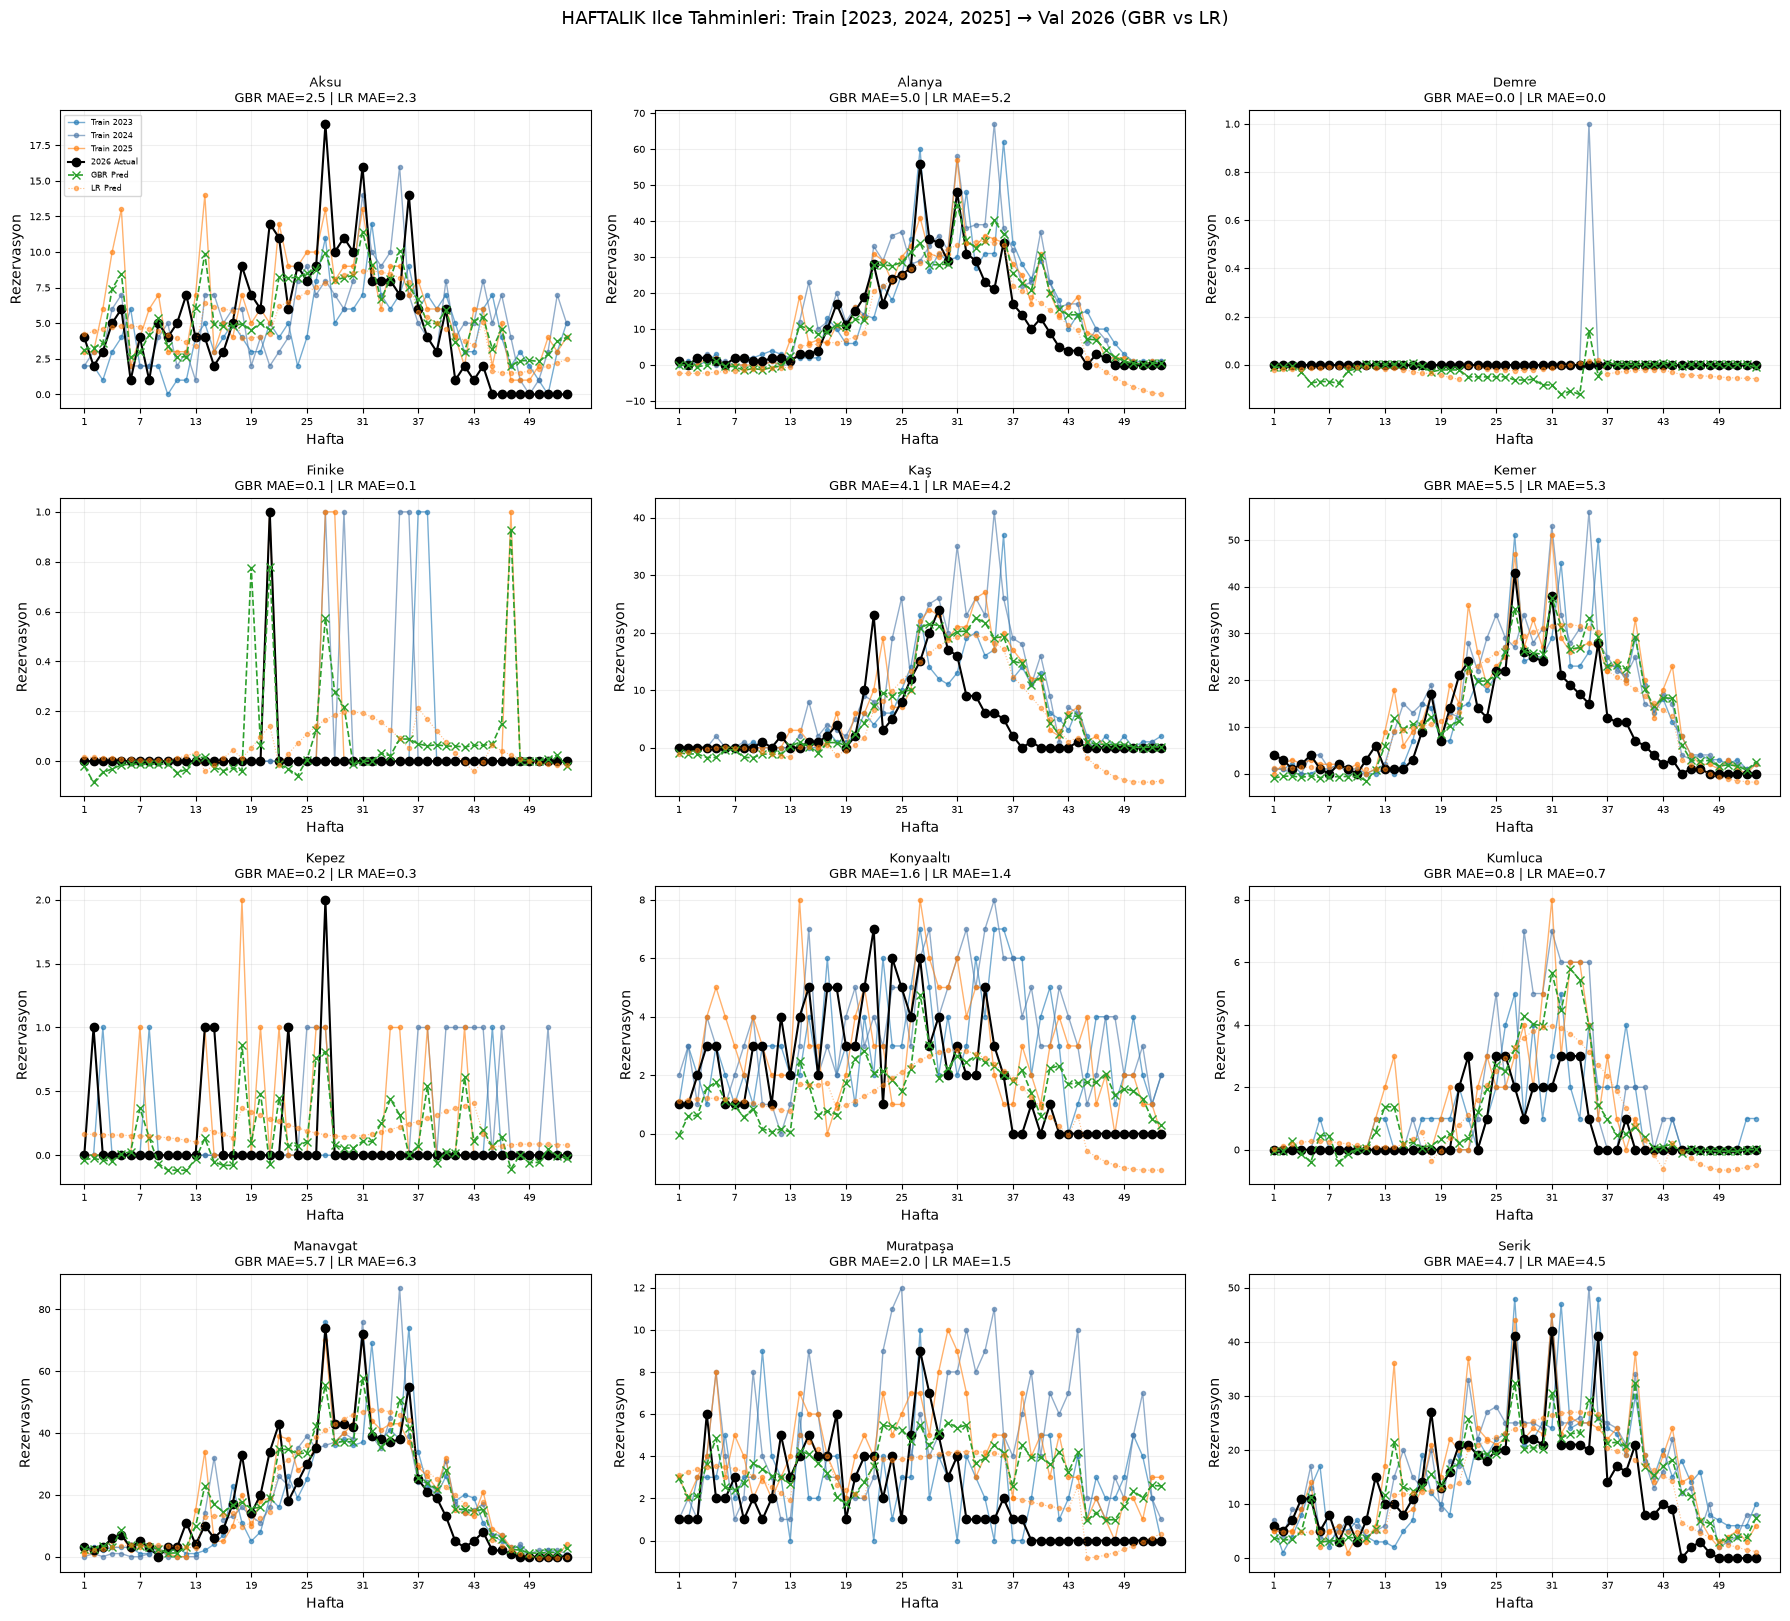


--- EN IYI 3 ILCE (en dusuk Val MAE) ---
  Demre           | ValMAE=  0.0 | 2025=    0 | 2026 Actual=    0 | Degisim=-%
  Finike          | ValMAE=  0.1 | 2025=    4 | 2026 Actual=    1 | Degisim=-75.0%
  Kepez           | ValMAE=  0.2 | 2025=   12 | 2026 Actual=    6 | Degisim=-50.0%

--- EN KOTU 3 ILCE (en yuksek Val MAE) ---
  Alanya          | ValMAE=  5.0 | 2025=  803 | 2026 Actual=  641 | Degisim=-20.2%
  Kemer           | ValMAE=  5.5 | 2025=  778 | 2026 Actual=  509 | Degisim=-34.6%
  Manavgat        | ValMAE=  5.7 | 2025= 1001 | 2026 Actual=  931 | Degisim=-7.0%

✓ Haftalik ilce bazinda tahmin (Train 2023-2025) tamamlandi.


In [8]:
# HAFTALIK Tahmin v3: Tum Ilceler Bazinda (2023-2025 train, 2026 val)
# GradientBoostingRegressor - her ilceye ayri model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

if "df" not in globals() or "mapping_df" not in globals():
    raise RuntimeError("Once veri yukleme ve ilce esleme hucrelerini calistirin.")

TRAIN_YEARS_W2 = [2023, 2024, 2025]
VAL_YEAR_W2 = 2026
target_city = "Antalya"

# --------------------------------------------------------------
# 1. Ilce bazinda haftalik veri hazirligi
# --------------------------------------------------------------
w2_src = df.copy()
w2_src["YearId"] = pd.to_numeric(w2_src["YearId"], errors="coerce")
w2_src["WeekId"] = pd.to_numeric(w2_src["WeekId"], errors="coerce")
w2_src["ReservationFlag"] = pd.to_numeric(w2_src["ReservationFlag"], errors="coerce").fillna(0)

w2_src = w2_src[
    (w2_src["CityName"] == target_city)
    & (w2_src["YearId"].isin(TRAIN_YEARS_W2 + [VAL_YEAR_W2]))
].copy()

w2_src = w2_src.merge(
    mapping_df[["HotelRegionName", "AssignedDistrict"]],
    on="HotelRegionName", how="left"
)
w2_src["AssignedDistrict"] = w2_src["AssignedDistrict"].fillna("Bilinmiyor")

w2_district_list = sorted(w2_src["AssignedDistrict"].unique())

# --------------------------------------------------------------
# 2. Feature engineering (haftalik)
# --------------------------------------------------------------
def build_weekly_features_w2(df_in):
    d = df_in.copy()
    d["TimeIndex"] = (d["YearId"] - 2023) * 53 + d["WeekId"]
    d["Week_sin"] = np.sin(2 * np.pi * d["WeekId"] / 53)
    d["Week_cos"] = np.cos(2 * np.pi * d["WeekId"] / 53)
    d["Week_sin_2"] = np.sin(4 * np.pi * d["WeekId"] / 53)
    d["Week_cos_2"] = np.cos(4 * np.pi * d["WeekId"] / 53)
    d["Trend"] = d["TimeIndex"]
    d["Trend_sq"] = d["TimeIndex"] ** 2
    d["Is_High"] = d["WeekId"].isin(range(22, 37)).astype(int)
    d["Is_Shoulder"] = d["WeekId"].isin(range(18, 22)).astype(int) | d["WeekId"].isin(range(37, 44)).astype(int)
    d["Is_Low"] = d["WeekId"].isin(range(1, 14)).astype(int) | d["WeekId"].isin(range(45, 54)).astype(int)
    return d

w2_feature_cols = [
    "Week_sin", "Week_cos", "Week_sin_2", "Week_cos_2",
    "Trend", "Trend_sq",
    "Is_High", "Is_Shoulder", "Is_Low",
]

w2_results = []

for district in w2_district_list:
    sub = w2_src[w2_src["AssignedDistrict"] == district]
    ts = (
        sub.groupby(["YearId", "WeekId"], observed=True)["ReservationFlag"]
        .sum()
        .rename("TotalReservation")
        .reset_index()
    )
    ts_f = build_weekly_features_w2(ts)

    train = ts_f[ts_f["YearId"].isin(TRAIN_YEARS_W2)].copy()
    val = ts_f[ts_f["YearId"] == VAL_YEAR_W2].copy()

    if train.empty or len(train) < 5:
        w2_results.append({"District": district, "Status": "SKIP (yetersiz veri)"})
        continue

    X_train = train[w2_feature_cols].values
    y_train = train["TotalReservation"].values
    X_val = val[w2_feature_cols].values
    y_val = val["TotalReservation"].values if not val.empty else np.array([])

    # GradientBoosting
    gbr = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        min_samples_leaf=2,
        random_state=42,
    )
    gbr.fit(X_train, y_train)
    val_pred_gbr = gbr.predict(X_val) if len(X_val) > 0 else np.array([])
    val_mae_gbr = float(np.mean(np.abs(y_val - val_pred_gbr))) if len(val_pred_gbr) > 0 else np.nan

    # LinearRegression baseline
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    val_pred_lr = lr.predict(X_val) if len(X_val) > 0 else np.array([])
    val_mae_lr = float(np.mean(np.abs(y_val - val_pred_lr))) if len(val_pred_lr) > 0 else np.nan

    total_2025 = int(y_train[train["YearId"] == 2025].sum()) if 2025 in train["YearId"].values else 0
    total_2026_actual = int(y_val.sum()) if len(y_val) > 0 else 0
    total_2026_pred_gbr = int(val_pred_gbr.sum().round()) if len(val_pred_gbr) > 0 else 0

    w2_results.append({
        "District": district,
        "Status": "OK",
        "ValMAE_GBR": round(val_mae_gbr, 1),
        "ValMAE_LR": round(val_mae_lr, 1),
        "Total_2025": total_2025,
        "Total_2026_Actual": total_2026_actual,
        "Total_2026_Pred_GBR": total_2026_pred_gbr,
        "Delta_Actual": total_2026_actual - total_2025,
        "PctChange_Actual": round((total_2026_actual - total_2025) / total_2025 * 100, 1) if total_2025 > 0 else "-",
        "ValData": val,
        "ValPred_GBR": val_pred_gbr,
        "ValPred_LR": val_pred_lr,
        "y_val": y_val,
        "TrainData": train,
        "y_train": y_train,
    })

# --------------------------------------------------------------
# 3. Ozet tablo
# --------------------------------------------------------------
w2_summary = pd.DataFrame(w2_results)
w2_display_cols = [
    "District", "Status", "ValMAE_GBR", "ValMAE_LR",
    "Total_2025", "Total_2026_Actual", "Total_2026_Pred_GBR",
    "Delta_Actual", "PctChange_Actual",
]

# MAE iyilesmesi
w2_valid = [r for r in w2_results if r["Status"] == "OK"]
w2_gb_vs_lr = []
for r in w2_valid:
    if isinstance(r["ValMAE_GBR"], (int, float)) and isinstance(r["ValMAE_LR"], (int, float)) and r["ValMAE_LR"] > 0:
        w2_gb_vs_lr.append((r["ValMAE_LR"] - r["ValMAE_GBR"]) / r["ValMAE_LR"] * 100)

w2_avg_imp = np.mean(w2_gb_vs_lr) if w2_gb_vs_lr else 0

print("=" * 70)
print(f"HAFTALIK Ilce Bazinda Tahmin: GradientBoostingRegressor")
print(f"Train: {TRAIN_YEARS_W2} ({len(w2_src[w2_src['YearId'].isin(TRAIN_YEARS_W2)])} hafta) | Val: {VAL_YEAR_W2}")
print(f"Ilce sayisi: {len(w2_district_list)}")
print(f"GBR, LR'a gore Val MAE'de ortalama %{w2_avg_imp:.1f} iyilesme sagladi.")
print(f"\nIlce bazinda haftalik tahmin ozeti:")
display(w2_summary[w2_display_cols])

# --------------------------------------------------------------
# 4. Tum ilceler panel grafik (3'lu grid)
# --------------------------------------------------------------
n_w2 = len(w2_valid)
cols_w2 = 3
rows_w2 = int(np.ceil(n_w2 / cols_w2))

fig, axes = plt.subplots(rows_w2, cols_w2, figsize=(cols_w2 * 6, rows_w2 * 4))
axes_flat_w2 = axes.flatten() if n_w2 > 1 else [axes]

for idx, res in enumerate(w2_valid):
    ax = axes_flat_w2[idx]
    dn = res["District"]

    # Train'i yillara gore ayri renklendir
    colors_tr = {2023: "#1f77b4", 2024: "#4C78A8", 2025: "#ff7f0e"}
    for yr in TRAIN_YEARS_W2:
        mask = res["TrainData"]["YearId"] == yr
        if mask.any():
            ax.plot(res["TrainData"].loc[mask, "WeekId"], res["TrainData"].loc[mask, "TotalReservation"].values,
                    marker=".", linewidth=1, label=f"Train {yr}", color=colors_tr[yr], alpha=0.6)

    ax.plot(res["ValData"]["WeekId"], res["y_val"], marker="o", linewidth=1.5,
            label=f"{VAL_YEAR_W2} Actual", color="black")
    ax.plot(res["ValData"]["WeekId"], res["ValPred_GBR"], linestyle="--", marker="x", linewidth=1.2,
            label=f"GBR Pred", color="#2ca02c")
    ax.plot(res["ValData"]["WeekId"], res["ValPred_LR"], linestyle=":", marker=".", linewidth=0.8,
            label=f"LR Pred", color="#ff7f0e", alpha=0.5)

    ax.set_title(f"{dn}\nGBR MAE={res['ValMAE_GBR']} | LR MAE={res['ValMAE_LR']}", fontsize=9)
    ax.set_xlabel("Hafta")
    ax.set_ylabel("Rezervasyon")
    ax.set_xticks(range(1, 54, 6))
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.legend(fontsize=6, loc="upper left")

# Bos subplotlari gizle
for idx in range(len(w2_valid), len(axes_flat_w2)):
    axes_flat_w2[idx].axis("off")

fig.suptitle(f"HAFTALIK Ilce Tahminleri: Train {TRAIN_YEARS_W2} → Val {VAL_YEAR_W2} (GBR vs LR)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# 5. En iyi / en kotu ilce detaylari
# --------------------------------------------------------------
w2_sorted = sorted(w2_valid, key=lambda r: r["ValMAE_GBR"])
best_w2 = w2_sorted[:3]
worst_w2 = w2_sorted[-3:]

print("\n--- EN IYI 3 ILCE (en dusuk Val MAE) ---")
for r in best_w2:
    pct = r["PctChange_Actual"]
    print(f"  {r['District']:15s} | ValMAE={r['ValMAE_GBR']:5.1f} | 2025={r['Total_2025']:5d} | 2026 Actual={r['Total_2026_Actual']:5d} | Degisim={pct}%")

print("\n--- EN KOTU 3 ILCE (en yuksek Val MAE) ---")
for r in worst_w2:
    pct = r["PctChange_Actual"]
    print(f"  {r['District']:15s} | ValMAE={r['ValMAE_GBR']:5.1f} | 2025={r['Total_2025']:5d} | 2026 Actual={r['Total_2026_Actual']:5d} | Degisim={pct}%")

print(f"\n✓ Haftalik ilce bazinda tahmin (Train 2023-2025) tamamlandi.")

2026 Antalya Geneli Haftalik Ozet
Gerçek Toplam:       3528
GBR Tahmin:          4060  (fark: +532)
LR Tahmin:           3641  (fark: +113)
GBR MAE:             29.2
LR MAE:              25.4

Aylik (~4 hafta) Toplam Karsilastirma:


,Actual,GBR_Pred,LR_Pred,GBR_Err,LR_Err
Oca,89,52,59,-37,-30
Şub,83,66,72,-17,-11
Mar,110,2,62,-108,-48
Nis,131,220,173,89,42
May,319,242,203,-77,-116
Haz,477,461,419,-16,-58
Tem,693,610,599,-83,-94
Ağu,696,682,698,-14,2
Eyl,544,692,701,148,157
Eki,267,506,421,239,154


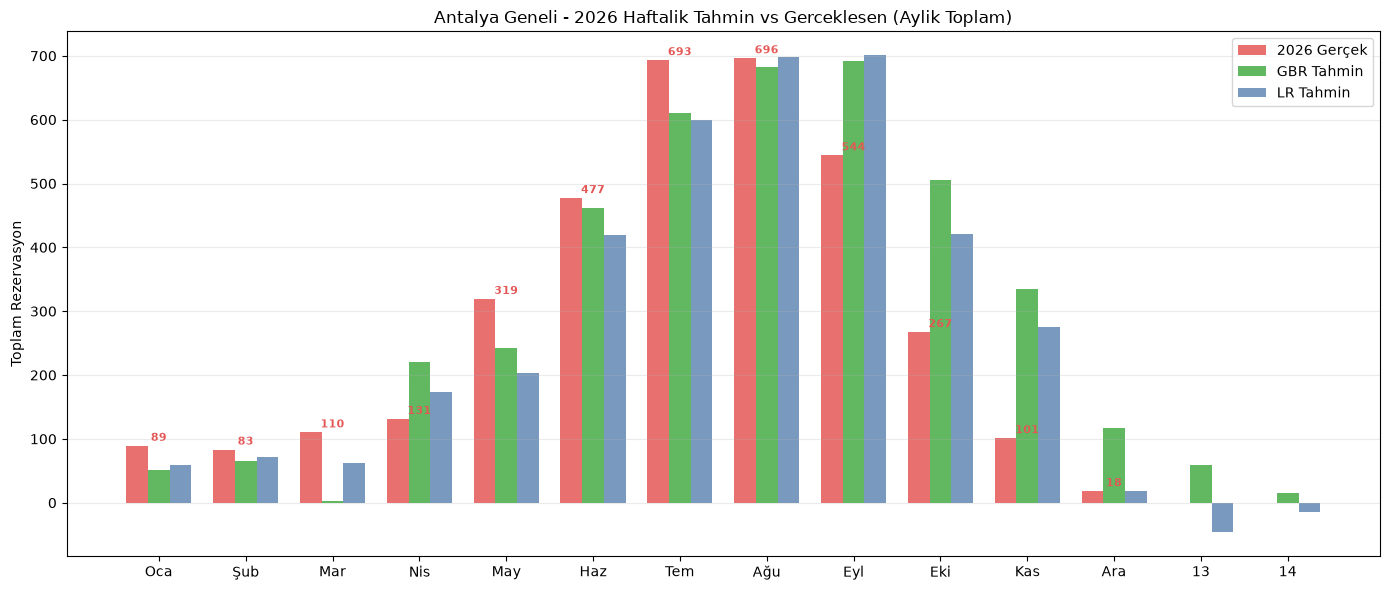

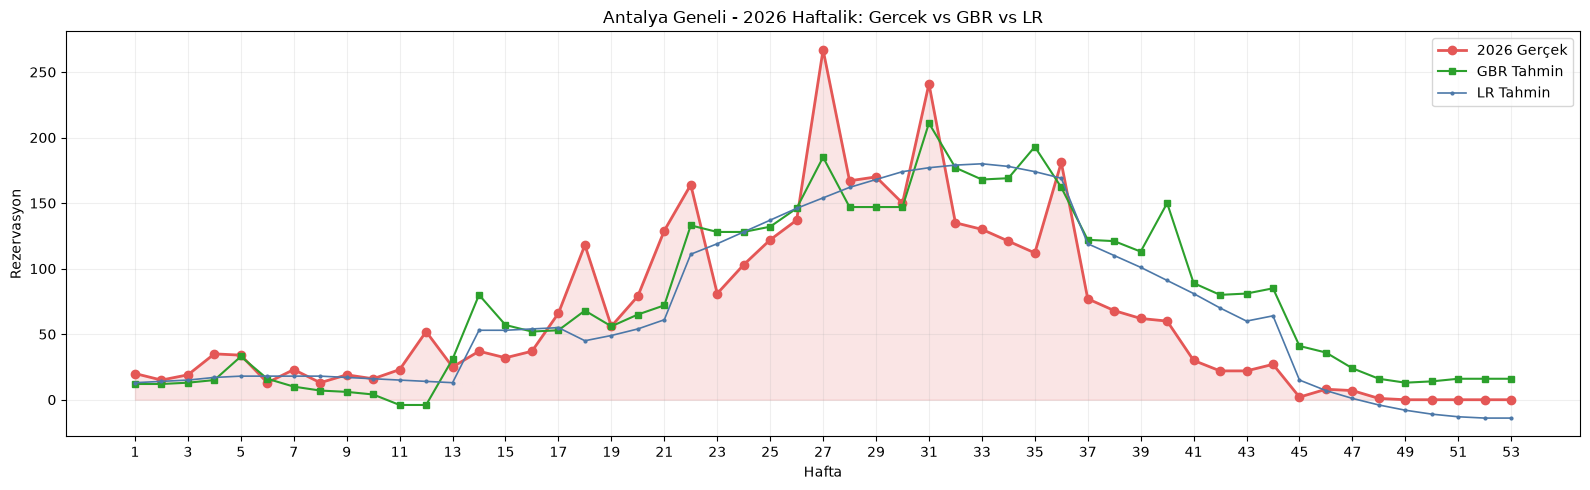

In [9]:
# HAFTALIK Antalya Geneli: 2026 Tahmin vs Gerceklesen Ozet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if "w_val" not in globals() or "w_val_pred" not in globals() or "w_val_pred_lr" not in globals():
    print("Once haftalik Antalya geneli tahmin hucresini calistirin.")
else:
    # Tablo
    w_summary = w_val[["YearId", "WeekId"]].copy()
    w_summary["Actual"] = y_wval.astype(int)
    w_summary["GBR_Pred"] = w_val_pred.round().astype(int)
    w_summary["LR_Pred"] = w_val_pred_lr.round().astype(int)

    # Ay etiketleri
    month_names = {1:"Oca",2:"Şub",3:"Mar",4:"Nis",5:"May",6:"Haz",
                   7:"Tem",8:"Ağu",9:"Eyl",10:"Eki",11:"Kas",12:"Ara"}
    w_summary["Month"] = ((w_summary["WeekId"] - 1) // 4 + 1).map(month_names)
    w_summary["Label"] = w_summary["Month"] + "-W" + w_summary["WeekId"].astype(str)

    total_actual = w_summary["Actual"].sum()
    total_gbr = w_summary["GBR_Pred"].sum()
    total_lr = w_summary["LR_Pred"].sum()

    print(f"2026 Antalya Geneli Haftalik Ozet")
    print(f"{'Gerçek Toplam:':20s} {total_actual}")
    print(f"{'GBR Tahmin:':20s} {total_gbr}  (fark: {total_gbr-total_actual:+d})")
    print(f"{'LR Tahmin:':20s} {total_lr}  (fark: {total_lr-total_actual:+d})")
    print(f"{'GBR MAE:':20s} {w_val_mae:.1f}")
    print(f"{'LR MAE:':20s} {w_val_mae_lr:.1f}")
    print()

    # Aylik toplam pivot
    w_summary["MonthGroup"] = ((w_summary["WeekId"] - 1) // 4) + 1
    monthly = w_summary.groupby("MonthGroup")[["Actual","GBR_Pred","LR_Pred"]].sum().astype(int)
    monthly.index = [month_names.get(i, str(i)) for i in monthly.index]
    monthly["GBR_Err"] = monthly["GBR_Pred"] - monthly["Actual"]
    monthly["LR_Err"] = monthly["LR_Pred"] - monthly["Actual"]
    print("Aylik (~4 hafta) Toplam Karsilastirma:")
    display(monthly)

    # Bar chart: aylik
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(monthly))
    w = 0.25
    ax.bar(x - w, monthly["Actual"], width=w, label="2026 Gerçek", color="#e45756", alpha=0.85)
    ax.bar(x, monthly["GBR_Pred"], width=w, label="GBR Tahmin", color="#2ca02c", alpha=0.75)
    ax.bar(x + w, monthly["LR_Pred"], width=w, label="LR Tahmin", color="#4C78A8", alpha=0.75)

    for i, (act, gbr, lr) in enumerate(zip(monthly["Actual"], monthly["GBR_Pred"], monthly["LR_Pred"])):
        if act > 0:
            ax.text(i, act + 8, f"{act}", ha="center", fontsize=8, color="#e45756", fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(monthly.index)
    ax.set_ylabel("Toplam Rezervasyon")
    ax.set_title(f"Antalya Geneli - 2026 Haftalik Tahmin vs Gerceklesen (Aylik Toplam)")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Haftalik cizgi
    fig2, ax2 = plt.subplots(figsize=(16, 5))
    weeks = w_summary["WeekId"].values
    ax2.fill_between(weeks, w_summary["Actual"], alpha=0.15, color="#e45756")
    ax2.plot(weeks, w_summary["Actual"], marker="o", linewidth=2, label="2026 Gerçek", color="#e45756")
    ax2.plot(weeks, w_summary["GBR_Pred"], marker="s", linewidth=1.5, label="GBR Tahmin", color="#2ca02c", markersize=4)
    ax2.plot(weeks, w_summary["LR_Pred"], marker=".", linewidth=1.2, label="LR Tahmin", color="#4C78A8", markersize=4)
    ax2.set_xlabel("Hafta")
    ax2.set_ylabel("Rezervasyon")
    ax2.set_title("Antalya Geneli - 2026 Haftalik: Gercek vs GBR vs LR")
    ax2.set_xticks(range(1, 54, 2))
    ax2.legend()
    ax2.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# Sales Forecast - Antalya Otel Rezervasyon Tahminleme

Bu repo, Antalya bölgesindeki otel rezervasyon verilerinin analizi ve tahminlenmesi çalışmasını içerir.

## 📊 İçerik

- **Veri Keşfi**: 52 turizm bölgesinin 12 resmi Antalya ilçesine eşlenmesi
- **Trend Analizi**: Bölge, ilçe ve otel bazında yıllık/aylık trendler
- **Kemer Özelinde**: 53 otelin satış-performans ve fiyat-satış korelasyon analizi
- **Tahmin Modelleri**: 
  - Aylık: LinearRegression, GradientBoostingRegressor, ElasticNet Ensemble
  - Haftalık: GradientBoostingRegressor (Antalya geneli + 12 ilçe)
- **Ana Bulgu**: 2026'da Antalya genelinde %-23.6 rezervasyon düşüşü

## 🛠 Kullanım

Notebook'u çalıştırmak için `data/hotel_forecasting.csv` dosyasını `data/` klasörüne koyun.

Gerekli paketler: `pandas`, `numpy`, `matplotlib`, `scikit-learn`